# Feature engineering: izvođenje novih promenljivih

Iz prethodnog notebook-a izlazimo sa očišćenim skupom od 18.260 ispitanika, podeljenim na trening i
test. Taj skup je čist, ali još nije upotrebljiv za model. Trideset šest kolona su i dalje stringovi u
kojima je više odgovora spojeno tačka-zarezom, četrdeset tri su rangiranja čije značenje tek treba
osmisliti, a `Country` ima toliko kategorija da bi ga one-hot enkodiranje razbilo na stotine kolona.

Ovaj notebook iz tih kolona izvodi nove promenljive. Za svaku od njih proveravamo da li stvarno nosi
signal za platu — dodavanje promenljive koja je šum ne pomaže modelu, nego mu daje još jednu priliku da
se prilagodi slučajnosti u trening skupu.

Redosled sekcija:

1. šta smo nasledili iz čišćenja i u kakvom je stanju;
2. čime merimo da li izvedena promenljiva nosi signal;
3. kako izgledaju multi-select kolone iznutra;
4. broj izabranih stavki kao promenljiva;
5. pojedinačne stavke kao indikatori;
6. kolone sa rangiranjem;
7. zemlja, kao „prvih N i ostalo";
8. ordinalne kategorije i promenljive izvedene iz onih koje već imamo;
9. koliko se nove promenljive međusobno preklapaju;
10. čuvanje proširenog skupa.

Jedno pravilo važi kroz ceo notebook, i posledica je odluke iz prethodnog: **sve što se računa iz
podataka računa se isključivo na trening skupu.** Test skup se do same isporuke ne dira.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"

TARGET = "ConvertedCompYearly"
# The logged target, added in section 1.3; it is not a predictor either.
TARGET_LOG = "log_comp"

train = pd.read_csv(PROCESSED_DIR / "train.csv.gz", low_memory=False)
test = pd.read_csv(PROCESSED_DIR / "test.csv.gz", low_memory=False)

print(f"trening: {train.shape[0]:>6,} redova x {train.shape[1]} kolona")
print(f"test:    {test.shape[0]:>6,} redova x {test.shape[1]} kolona")
print(f"ukupno:  {len(train) + len(test):>6,} ispitanika")

trening: 14,608 redova x 129 kolona
test:     3,652 redova x 129 kolona
ukupno:  18,260 ispitanika


## 1. Šta smo nasledili iz čišćenja

### 1.1 Da li je stiglo ono što je poslato

Skup čitamo iz fajla, a ne iz promenljive koja je ostala u memoriji, pa nemamo garanciju da je u njemu
baš ono što smo mislili da čuvamo. Zapis u CSV i čitanje nazad umeju da promene tip kolone ili da unesu
prazna polja tamo gde ih nije bilo.

Zato prvo proveravamo četiri stvari koje je prethodni notebook obećao: da je podela 80:20, da oba skupa
imaju iste kolone, da je ciljna promenljiva svuda popunjena, i da praznih polja ima **samo** u
multi-select kolonama, koje smo namerno ostavili nedirnute.

In [2]:
def is_text(series):
    """True for columns pandas stores as strings, whichever string dtype it uses."""
    return series.dtype.kind in "OU" or str(series.dtype) in ("str", "string")


# Answers to "pick all that apply" are one string with ";" between the chosen
# items; the same test as in the cleaning notebook picks those columns out.
MULTI_SELECT_SHARE = 0.3


def is_multi_select(series):
    """True for a column that holds several answers joined by semicolons."""
    return is_text(series) and series.dropna().astype(str).str.contains(";").mean() > MULTI_SELECT_SHARE


numeric_columns = train.select_dtypes(include="number").columns
missing_per_column = train.isna().sum()
with_missing = list(missing_per_column[missing_per_column > 0].index)

print(f"odnos trening : test           {100 * len(train) / (len(train) + len(test)):.0f} : "
      f"{100 * len(test) / (len(train) + len(test)):.0f}")
print(f"iste kolone u oba skupa        {list(train.columns) == list(test.columns)}")
print(f"ciljna promenljiva popunjena   "
      f"{train[TARGET].notna().all() and test[TARGET].notna().all()}")
print(f"praznih polja u numeričkim     {int(train[numeric_columns].isna().sum().sum())}")
print()
print(f"kolona sa praznim poljima      {len(with_missing)}")
print(f"  od toga multi-select         {sum(is_multi_select(train[c]) for c in with_missing)}")
print(f"praznih polja ukupno           {int(train.isna().sum().sum()):,} "
      f"({100 * train.isna().to_numpy().mean():.1f}% svih ćelija)")

odnos trening : test           80 : 20
iste kolone u oba skupa        True
ciljna promenljiva popunjena   True
praznih polja u numeričkim     0

kolona sa praznim poljima      36
  od toga multi-select         36
praznih polja ukupno           148,085 (7.9% svih ćelija)


**Zapažanje:** Sve četiri provere prolaze. Podela je **80 : 20**, kolone su iste u oba skupa, ciljna
promenljiva je popunjena svuda, a u numeričkim kolonama nema **nijednog** praznog polja. Praznih polja
ima **148.085, odnosno 7,9% svih ćelija**, ali su sva na jednom mestu: kolona sa prazninama ima **36**, i
svih **36** su multi-select.

**Tumačenje:** Skup je u stanju u kom smo ga ostavili, pa možemo da nastavimo. Ono što je ostalo prazno
nije propust nego odluka: dok je multi-select kolona jedan dugačak string, popunjavanje nema smisla. Kada
iz nje izvedemo prave promenljive, prazna vrednost prirodno postaje nula izabranih stavki — i to je jedan
od poslova ovog notebook-a.

### 1.2 Od čega se skup sastoji

Prediktora ima 128 i o njima ne možemo da govorimo kolonu po kolonu. Ali oni nisu raznorodni koliko taj
broj sugeriše — dolaze iz svega nekoliko oblika pitanja, a oblik pitanja određuje i šta se sa kolonom
može uraditi.

Grupe pravimo po tome, a ne po imenu kolone: rangiranja prepoznajemo po četiri poznata pitanja iz
prethodnog notebook-a, multi-select po tačka-zarezu u odgovoru, indikatore po prefiksu koji smo im sami
dali, a ostatak razdvajamo po tipu kolone.

In [3]:
# The four ranking questions. Each is exported as one column per offered item,
# named "<question>_<number>" — the intro text of a question carries the same
# prefix without that suffix, so the prefix alone is not enough to tell them apart.
RANK_PREFIXES = ["TechEndorse", "TechOppose", "JobSatPoints", "SO_Actions"]
RANK_NAME = re.compile("(?:" + "|".join(RANK_PREFIXES) + r")_\d+")

# The flags we added ourselves before imputing, one per block of columns that
# went missing together.
INDICATOR_PREFIX = "NotAnswered_"

predictors = [c for c in train.columns if c not in (TARGET, TARGET_LOG)]

indicators = [c for c in predictors if c.startswith(INDICATOR_PREFIX)]
rankings = [c for c in predictors
            if RANK_NAME.fullmatch(c) and train[c].dtype.kind in "if"]
multi_select = [c for c in predictors if is_multi_select(train[c])]
taken = set(indicators) | set(rankings) | set(multi_select)
numeric_plain = [c for c in predictors if c not in taken and train[c].dtype.kind in "if"]
categorical = [c for c in predictors if c not in taken and c not in numeric_plain]

groups = {
    "rangiranja": rankings,
    "multi-select": multi_select,
    "obične kategorijske": categorical,
    "indikatori": indicators,
    "obične numeričke": numeric_plain,
}

print(f"prediktora ukupno: {len(predictors)}")
print()
for name, columns in groups.items():
    print(f"  {name:<22} {len(columns):>3}   {', '.join(columns[:3])} ...")
print()
print(f"provera da se grupe ne preklapaju i pokrivaju sve: "
      f"{sum(len(c) for c in groups.values()) == len(predictors)}")
print()
print("od čega se tih 43 rangiranja sastoji — po jedna kolona za svaku ponuđenu stavku:")
for prefix in RANK_PREFIXES:
    print(f"  {prefix:<14} {len([c for c in rankings if c.startswith(prefix)]):>2} kolona")
print()
print(f"kolone sa prefiksom rangiranja koje nisu rangiranje: "
      f"{[c for c in predictors if any(c.startswith(p) for p in RANK_PREFIXES) and c not in rankings]}")

prediktora ukupno: 128

  rangiranja              43   TechEndorse_1, TechEndorse_2, TechEndorse_3 ...
  multi-select            36   LearnCode, AILearnHow, LanguageHaveWorkedWith ...
  obične kategorijske     35   Age, EdLevel, Employment ...
  indikatori               9   NotAnswered_WorkExp, NotAnswered_TechEndorse_1, NotAnswered_TechOppose_1 ...
  obične numeričke         5   WorkExp, YearsCode, ToolCountWork ...

provera da se grupe ne preklapaju i pokrivaju sve: True

od čega se tih 43 rangiranja sastoji — po jedna kolona za svaku ponuđenu stavku:
  TechEndorse    10 kolona
  TechOppose     10 kolona
  JobSatPoints   13 kolona
  SO_Actions     10 kolona

kolone sa prefiksom rangiranja koje nisu rangiranje: ['TechEndorseIntro']


**Zapažanje:** Pet grupa pokriva svih 128 prediktora, bez preklapanja: **43 rangiranja, 36 multi-select,
35 običnih kategorijskih, 9 indikatora i 5 običnih numeričkih** kolona.

Tih 43 rangiranja nisu jedno pitanje nego **četiri**, i drugi deo ispisa pokazuje kako se dele:
`TechEndorse` **10**, `TechOppose` **10**, `JobSatPoints` **13** i `SO_Actions` **10** kolona. Svaka
kolona nosi rang koji je ispitanik dodelio jednoj ponuđenoj stavci tog pitanja.

Poslednji red ispisa izdvaja jednu kolonu koja nosi prefiks rangiranja a nije rangiranje —
**`TechEndorseIntro`**. Ona počinje istim prefiksom kao onih deset kolona pitanja `TechEndorse`, ali je
uvodni tekst tog pitanja, a ne rang neke stavke.

**Zašto to uopšte pominjemo.** Grupe smo prvo podelili po prefiksu imena, pa je `TechEndorseIntro` završio
među rangiranjima i njih je ispalo **44 umesto 43**. Da 43 treba da bude tačan broj znali smo iz
prethodnog notebook-a: on je pri izboru kolona prebrojao kolone sa rangiranjem i našao ta četiri pitanja
sa ukupno 43 kolone. Razlika se, dakle, videla tek poređenjem sa ranije prebrojanim, ne sama od sebe.

Popravka je bila da se rangiranje ne prepoznaje po prefiksu nego po **obliku imena `<pitanje>_<broj>` i
po tome što je kolona numerička**. Uvodni tekst nema broj na kraju i nije broj, pa ispada sam od sebe, a
poslednji red ispisa ostaje u kodu da se vidi da nijedna druga kolona nije u sličnom položaju.

**Tumačenje:** Brojevi odmah pokazuju gde je posao. Kolona koje model može da uzme onakve kakve jesu ima
malo — pet numeričkih i devet indikatora, dakle četrnaest od 128. Sve ostalo traži neku odluku pre nego
što uđe u model.

Dve najveće grupe traže i najviše. Kod multi-select kolona odgovor uopšte nije jedna vrednost nego
spisak, pa se iz njega tek mora nešto izvesti. Kod rangiranja vrednost jeste broj, ali broj koji označava
mesto na listi, a ne količinu — rang 1 nije „duplo manji" od ranga 2, pa se takva kolona ne sme koristiti
kao obična numerička bez razmišljanja.

Obične kategorijske kolone su najbliže upotrebljivom obliku, ali je među njima i `Country`, koji ima
previše kategorija da bi se enkodirao naivno. Njime se bavimo u sekciji 7.

### 1.3 Prema čemu merimo

Sve što u ovom notebook-u radimo meri se prema jednoj veličini — plati. U prvom notebook-u smo pokazali
da je u sirovim dolarima ne možemo koristiti, jer je nekolicina ekstremnih iznosa razvlačila celu
raspodelu, i odlučili da je modelujemo logaritmovanu. To isto važi i ovde, kad merimo koliko je neka
promenljiva sa njom povezana.

Posle čišćenja skup više nije isti, pa vredi videti kako ciljna promenljiva sada izgleda — i to na
trening skupu, jer je test od ovog trenutka van igre.

In [4]:
train[TARGET_LOG] = np.log10(train[TARGET])
test[TARGET_LOG] = np.log10(test[TARGET])

print("ciljna promenljiva na trening skupu:")
print(train[TARGET].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(0).to_string())
print()
print(f"koeficijent asimetrije, sirova vrednost: {train[TARGET].skew():>7.2f}")
print(f"koeficijent asimetrije, log vrednost:    {train[TARGET_LOG].skew():>7.2f}")
print()
print(f"odnos aritmetičke sredine i medijane:    {train[TARGET].mean() / train[TARGET].median():>7.2f}")
print(f"odnos maksimuma i medijane:              {train[TARGET].max() / train[TARGET].median():>7.1f}")
print(f"ispitanika ispod 1.000 USD:              {int((train[TARGET] < 1000).sum()):>7} "
      f"({100 * (train[TARGET] < 1000).mean():.1f}%)")
print()

# Why the logarithm is the right scale here: the same relative change is the
# same distance, wherever on the salary scale it happens.
print("udvostručenje plate, mereno u logaritmu:")
for low in [40_000, 80_000, 160_000]:
    print(f"  {low:>7,} -> {2 * low:>7,} USD   razlika u log10 = "
          f"{np.log10(2 * low) - np.log10(low):.3f}")
print(f"  u dolarima ista ta tri koraka iznose {40_000:,}, {80_000:,} i {160_000:,}")

ciljna promenljiva na trening skupu:
count      14608.0
mean       94499.0
std        67862.0
min           27.0
10%        20923.0
25%        48726.0
50%        81210.0
75%       125000.0
90%       180000.0
max      1000000.0

koeficijent asimetrije, sirova vrednost:    1.62
koeficijent asimetrije, log vrednost:      -1.86

odnos aritmetičke sredine i medijane:       1.16
odnos maksimuma i medijane:                 12.3
ispitanika ispod 1.000 USD:                   89 (0.6%)

udvostručenje plate, mereno u logaritmu:
   40,000 ->  80,000 USD   razlika u log10 = 0.301
   80,000 -> 160,000 USD   razlika u log10 = 0.301
  160,000 -> 320,000 USD   razlika u log10 = 0.301
  u dolarima ista ta tri koraka iznose 40,000, 80,000 i 160,000


**Zapažanje:** Medijana je **81.210 dolara**, kvartili **48.726** i **125.000**, a raspon ide od **27 do
1.000.000**. Koeficijent asimetrije sirove vrednosti je **1,62**, a najveća vrednost je **12,3 puta veća
od medijane** — obe vrednosti su neuporedivo manje nego pre čišćenja.

Logaritmovana vrednost ima asimetriju **−1,86**, dakle u apsolutnom iznosu **veću** nego sirova.

**Tumačenje:** Prvi deo je očekivan. Uklanjanje netipičnih vrednosti je sredilo desni rep, pa sirova
raspodela više nije ono što je bila na početku.

Drugi deo je iznenađenje i vredi ga reći naglas: posle čišćenja je sirova raspodela po asimetriji bliža
simetričnoj nego logaritmovana. Uzrok je levi rep koji smo zadržali svesno — **89 ispitanika, 0,6%
trening skupa, ima prijavljen iznos ispod hiljadu dolara**. U logaritmu se ta šačica malih vrednosti
razvlači daleko ulevo i sama pravi asimetriju, dok u dolarima stoji zbijena uz nulu i jedva se primećuje.

Odluku da modelujemo logaritam ipak ne menjamo, ali joj se razlog pomerio. Ne držimo je više zato što je
sirova raspodela neupotrebljiva, nego zbog merne skale: kod plate je udvostručenje iznosa ista vrsta
promene i na dnu i na vrhu skale, pa logaritam relativne razlike pretvara u apsolutne. Da li je taj izbor
bolji i za samu regresiju, ne odlučuje asimetrija ciljne kolone nego rasipanje grešaka modela — a to se
vidi tek na dijagnostičkim graficima, u fazi modelovanja.

Time je sekcija završena. Znamo šta imamo i da je stiglo celo, i imamo veličinu prema kojoj sve merimo:
sve veze u nastavku mere se prema `log_comp`, računaju se **isključivo na trening skupu**, a test ostaje
netaknut do isporuke. Ostaje da se dogovorimo *kako* merimo — čime se odlučuje da li izvedena promenljiva
zaslužuje mesto u modelu — što je posao sledeće sekcije.

## 2. Čime merimo da li promenljiva nosi signal

U narednim sekcijama napravićemo desetine novih promenljivih. Ako svaku budemo ocenjivali onim što se
kod nje slučajno lepo vidi — kod jedne korelacijom, kod druge razlikom medijana, kod treće grafikom —
na kraju nećemo moći da kažemo koja je bolja od koje, a ni sami sebi nećemo umeti da objasnimo zašto je
neka ušla a neka nije. Zato merilo postavljamo sada, pre nego što napravimo ijednu promenljivu.

Merilo mora da radi tri stvari. Prvo, da daje **istu vrstu broja** za neprekidnu promenljivu (broj
jezika koje neko koristi), za binarnu (da li koristi Python) i za kategorijsku (zemlja) — inače se
rezultati ne mogu porediti. Drugo, da uz sebe ima **test značajnosti**, jer to uputstvo i traži. Treće,
da bude čitljivo, dakle da se iz njega vidi ne samo *da li* veza postoji nego i **koliko je velika**.

Pre nego što bilo šta izmerimo, da kažemo šta je tačno **merilo** koje ćemo koristiti, jer se na njega
pozivamo kroz ceo notebook:

> **Šta je:** Regresija logaritmovane plate na tu jednu promenljivu, i pet brojeva koje iz nje čitamo.
> **Kako se računa:** Metodom najmanjih kvadrata; kategorijska kolona ulazi kao dummy promenljive, po
> jedna manje nego što ima kategorija.
> **Na kojim podacima:** Isključivo na trening skupu, dakle na 14.608 ispitanika. Test skup se od ovog
> trenutka ne dodiruje.

Obrazloženje zašto baš tako sledi ispod.

Uzimamo **regresiju logaritmovane plate na tu jednu promenljivu** i gledamo pet brojeva:

- **R²** — deo varijanse plate koji ta promenljiva objašnjava. Ovo je veličina sa predavanja i ima
  smisla za sva tri tipa: kategorijska promenljiva u regresiju ulazi kao dummy promenljive, po jedna
  manje nego što ima kategorija, pa je postupak isti. Kod **brojčane** promenljive treba imati na umu šta
  se tačno meri: ona u regresiju ulazi kao jedna kolona, pa model kroz podatke provlači **pravu liniju**,
  a R² kaže koliko dobro ta prava opisuje vezu. Ako je veza zakrivljena, R² će je potceniti — na to
  nailazimo u sekciji 4.
- **R**, koren iz R². Za prostu regresiju sa jednim neprekidnim prediktorom to je tačno koeficijent
  korelacije, `R² = Cor(X,Y)²`, pa je ovo skala na kojoj imamo osećaj šta je jaka a šta slaba veza. Kod
  promenljive sa više kategorija to više nije obična korelacija dve kolone nego **višestruki koeficijent
  korelacije**, ali se čita isto — koliko je veza jaka, od 0 do 1.
- **Prilagođeni R²** — R² kažnjen brojem kolona koje je promenljiva tražila. Bez njega bi promenljiva sa
  sto kategorija uvek pobeđivala onu sa dve, jer se R² povećava sa svakom dodatom kolonom bez obzira na
  to da li ona nešto znači. Koliko je ta zamka stvarna, izmerićemo u 2.1.
- **p-vrednost F-testa**, na pragu 0,05. F-test, a ne pojedinačni t-testovi, jer nas zanima da li
  promenljiva **kao celina** nešto objašnjava; kod zemlje bi t-testovi dali sto četrdeset p-vrednosti i
  nijedan odgovor na to pitanje.
- **Raspon predviđene plate** — koliko se puta razlikuje plata koju model predviđa na najpovoljnijoj i
  najnepovoljnijoj vrednosti te promenljive.

Poslednji broj traži objašnjenje, jer nije standardna metrika nego naš prevod nazad u dolare. Pošto je
ciljna promenljiva logaritam, razlika dva predviđanja nije razlika u dolarima nego **odnos**: ako se
predviđanja razlikuju za `d` u logaritmu, odnos plata je `10^d`. Kod radnog staža, u ispisu ispod, taj
odnos ispada 9,5 — dakle model za najiskusnijeg predviđa 9,5 puta veću platu nego za najmanje iskusnog.

R² i raspon govore različite stvari i lako se pomešaju. **R² kaže kod koliko ljudi promenljiva objašnjava
razlike, a raspon koliko je razlika velika kod onih koje pogađa.** Promenljiva može imati ogroman raspon
a sitan R², ako se krajnosti tiču šačice ljudi dok je ogromna većina u sredini.

Ovo merenje ima jedno ograničenje. Ovo je merenje **jedne promenljive u izolaciji**, pa ne govori
koliko će ona doprineti kada uz nju u modelu stoji još stotinu drugih. Promenljiva sa slabim samostalnim
R² može biti korisna u društvu, a dve jake mogu nositi istu informaciju pa druga ne doda ništa. Koliko je
ta razlika velika, izmerićemo u 2.4. Zbog toga ovo koristimo kao **prvi filter za odbacivanje**, a ne kao konačan izbor promenljivih — konačan izbor se radi u fazi modelovanja, merilima za izbor modela sa predavanja (Cp,
AIC, BIC, prilagođeni R², greška unakrsne validacije).

In [5]:
import statsmodels.api as sm


def design_matrix(values):
    """One column turned into the columns a regression can take.

    A numeric column enters as itself. A categorical one enters as dummy
    variables — the one-hot encoding from the lectures — with one category left
    out, so the columns are not linearly dependent.
    """
    if values.dtype.kind in "if":
        design = pd.DataFrame({"x": values.astype(float)})
    else:
        design = pd.get_dummies(values.astype(str), drop_first=True, dtype=float)
    return sm.add_constant(design, has_constant="add")


def signal(values, target=None):
    """How much of the target one variable explains on its own."""
    target = train[TARGET_LOG] if target is None else target
    usable = values.notna() & target.notna()
    model = sm.OLS(target[usable].to_numpy(),
                   design_matrix(values[usable]).to_numpy()).fit()
    fitted = model.fittedvalues
    return {
        "n": int(usable.sum()),
        "kolona": int(model.df_model),
        "R": float(np.sqrt(model.rsquared)),
        "R2": model.rsquared,
        "R2_prilag": model.rsquared_adj,
        "p": model.f_pvalue,
        # The target is a base-10 logarithm, so a difference in fitted values is
        # a ratio in dollars.
        "raspon_puta": float(10 ** (fitted.max() - fitted.min())),
    }


def signal_table(columns):
    """The same measure for several columns at once, strongest first."""
    return pd.DataFrame({name: signal(series) for name, series in columns.items()}).T \
             .sort_values("R2_prilag", ascending=False)


def format_p(value):
    """A p-value too small for a float prints as a bound, not as a plain zero."""
    return "< 1e-300" if value == 0 else f"{value:.2g}"


def show(table):
    """Print a measure table, each column formatted the way it reads best."""
    out = pd.DataFrame(index=table.index)
    out["n"] = table["n"].map(lambda v: f"{int(v):,}")
    out["kolona"] = table["kolona"].map(lambda v: f"{int(v)}")
    out["R"] = table["R"].map(lambda v: f"{v:.3f}")
    out["R2"] = table["R2"].map(lambda v: f"{v:.4f}")
    out["R2_prilag"] = table["R2_prilag"].map(lambda v: f"{v:.4f}")
    out["p"] = table["p"].map(format_p)
    out["raspon_puta"] = table["raspon_puta"].map(lambda v: f"{v:.1f}")
    print(out.to_string())


example = signal(train["WorkExp"])
print("primer — koliko radni staž sam za sebe objašnjava:")
print(f"  ispitanika u računu:              {example['n']:,}")
print(f"  kolona koje promenljiva traži:    {example['kolona']}")
print(f"  jačina veze (R):                  {example['R']:.3f}")
print(f"  objašnjeni deo varijanse (R²):    {example['R2']:.4f}")
print(f"  prilagođeni R²:                   {example['R2_prilag']:.4f}")
print(f"  p-vrednost F-testa:               {format_p(example['p'])}")
print(f"  raspon predviđene plate:          {example['raspon_puta']:.1f} puta")

primer — koliko radni staž sam za sebe objašnjava:
  ispitanika u računu:              14,608
  kolona koje promenljiva traži:    1
  jačina veze (R):                  0.358
  objašnjeni deo varijanse (R²):    0.1282
  prilagođeni R²:                   0.1281
  p-vrednost F-testa:               < 1e-300
  raspon predviđene plate:          9.5 puta


**Zapažanje:** Radni staž sam za sebe objašnjava **12,82%** varijanse logaritmovane plate, što na skali
korelacije znači **R = 0,358**. Pošto je neprekidna promenljiva, u model ulazi kao **jedna** kolona, pa se
prilagođeni R² (0,1281) od običnog razlikuje tek na četvrtoj decimali. Veza je **statistički značajna**,
a raspon predviđene plate između najkraćeg i najdužeg staža u uzorku je **9,5 puta**.

**Tumačenje:** Ovako izgleda potpuni zapis o jednoj promenljivoj i tako ćemo ga čitati u nastavku.

Ovih pet brojeva govore pet različitih stvari i nijedan sam nije
dovoljan. Posebno se lako pomeša „statistički značajno" sa „jako": veza staža i plate **jeste** značajna
u statističkom smislu, ali je po jačini umerena — R od 0,358 znači da staž objašnjava osmi deo razlika u
platama, a sedam osmina ostaje na svemu ostalom.

Isto važi i za odnos R² i raspona. Raspon od 9,5 puta zvuči ogromno, ali se tiče krajnosti: poređenje
nekoga bez ijedne godine staža sa nekim ko ima najviše u uzorku. Kod ogromne većine ispitanika, koji su
negde u sredini, razlika je mnogo manja — i baš to R² kaže, a raspon ne.

Poslednja napomena, o zapisu: p-vrednost je ispisana kao `< 1e-300` zato što je F-statistika toliko
velika da izračunata p-vrednost **potkorači** najmanji broj koji se u ovom zapisu može predstaviti, pa
funkcija vrati tačnu nulu. To nije nula nego „manje od najmanjeg što možemo da zapišemo".

### 2.1 Šta dobije čista slučajnost

Sada znamo šta merimo, ali ne i **odakle počinje „nešto"**. R² od 0,01 zvuči malo, ali da li je to malo
ili je to koliko se u ovakvim podacima uopšte može dobiti, iz samog broja se ne vidi.

Granicu zato ne izmišljamo nego je izmerimo. Napravimo četiri nove kolone, popunimo ih slučajnim
brojevima, pa ih pustimo kroz isto merilo kojim merimo i prave promenljive.

Svaka od te četiri kolone ima po jednu vrednost za svakog od 14.608 ispitanika, izvučenu iz generatora
slučajnih brojeva:

| kolona | čime je popunjena | broj različitih vrednosti |
| --- | --- | --- |
| slučajan broj | brojevi iz normalne raspodele | neprekidna, ulazi kao jedna kolona |
| slučajne 2 grupe | ceo broj 0 ili 1 | 2 |
| slučajnih 10 grupa | ceo broj od 0 do 9 | 10 |
| slučajnih 150 grupa | ceo broj od 0 do 149 | 150 |

Poslednje tri tretiramo kao kategorijske promenljive, isto kao `Country` — svaka različita vrednost je
jedna kategorija, pa u regresiju ulaze kao dummy kolone.

Nijedna od njih nema veze sa podacima: broj koji ispitanik dobije ne zavisi ni od njegove zemlje, ni od
staža, ni od plate. Zato je sve što takva kolona „objasni" čista slučajnost, i to je donja granica ispod koje prava promenljiva ne sme da padne.

Pravimo četiri a ne jednu zato što nas zanima i **da li se ta granica pomera sa oblikom promenljive**. Broj grupa
biramo tako da pokrije raspon koji stvarno srećemo u podacima: od dve kategorije, koliko ima `Employment`,
do sto pedeset, koliko je otprilike zemalja u uzorku.

In [6]:
# A fixed seed, so the floor we measure here does not move between runs.
rng = np.random.default_rng(0)
n_rows = len(train)

noise_examples = {
    "slučajan broj": pd.Series(rng.normal(size=n_rows)),
    "slučajne 2 grupe": pd.Series(rng.integers(0, 2, size=n_rows).astype(str)),
    "slučajnih 10 grupa": pd.Series(rng.integers(0, 10, size=n_rows).astype(str)),
    "slučajnih 150 grupa": pd.Series(rng.integers(0, 150, size=n_rows).astype(str)),
}

noise_table = signal_table(noise_examples)
show(noise_table)

                          n kolona      R      R2 R2_prilag     p raspon_puta
slučajnih 10 grupa   14,608      9  0.026  0.0007    0.0001  0.36         1.1
slučajne 2 grupe     14,608      1  0.007  0.0001   -0.0000  0.36         1.0
slučajan broj        14,608      1  0.001  0.0000   -0.0001  0.92         1.0
slučajnih 150 grupa  14,608    149  0.097  0.0094   -0.0008  0.74         1.7


**Zapažanje:** Nijedna od četiri slučajne kolone nije značajna — p-vrednosti su **0,36**, **0,36**,
**0,74** i **0,92**, sve daleko iznad praga od 0,05. Prilagođeni R² im je **0,0001 ili negativan**.

Ali obični R² **nije** kod svih blizu nule. Slučajna podela na **150 grupa** dobija **R² = 0,0094**,
odnosno **R = 0,097**, iako sa platom nema nikakve veze. Podela na 10 grupa dobija R² = 0,0007, a slučajan
broj i podela na dve grupe 0,0000 i 0,0001.

**Tumačenje:** Ovo je razlog zbog kog prilagođeni R² nije formalnost nego neophodnost. Obični R² raste sa
svakom dodatom kolonom, pa promenljiva sa 150 kategorija dobija 149 kolona i sa njima priliku da se
prilagodi slučajnim razlikama među grupama. Sa 14.608 redova i 149 kolona to je dovoljno za skoro procenat
„objašnjene" varijanse ni iz čega. Prilagođeni R² tu cenu odbija i vraća vrednost na nulu, čak i ispod nje
— jedina od naših mera koja slučajnosti pravilno dodeli negativnu vrednost.

Dobili smo dakle dve donje granice, i one nisu iste:

- po **prilagođenom R²**, sve do **0,0001** je u opsegu koji dostiže i čista slučajnost;
- po **običnom R²**, donja granica zavisi od broja kategorija i kod promenljive sa mnogo grupa penje se do
  **0,0094** — pa se obični R² ne sme koristiti za poređenje promenljivih različitog oblika.

To što nijedna slučajna kolona nije prošla test značajnosti jeste uteha, ali slaba: p-vrednost pri ovoj
veličini uzorka lako propušta i sasvim beznačajne veze, što ćemo videti već u sledećoj tabeli.

### 2.2 Šta dobije obeležje koje stvarno nosi signal

Donju granicu znamo. Ostaje gornji kraj: koliko uopšte dobije promenljiva za koju već znamo da je važna.

Uzimamo deset obeležja koja su u anketu ušla kao pitanja i koja nismo mi izveli — zemlju, tip posla,
veličinu firme, obrazovanje, uzrast, način rada, oblik zaposlenja, radni staž, godine programiranja i
zadovoljstvo poslom. Za neka od njih iz prethodnog notebook-a znamo da su povezana sa platom, za neka
ne znamo ništa. To i jeste smisao: hoćemo raspon, od najjačeg do najslabijeg, da bismo znali gde na toj
skali stoje promenljive koje tek napravimo.

In [7]:
# Questions the survey asked, not columns we derived; they set the upper end of
# the scale the new variables will be read against.
REFERENCE = ["Country", "DevType", "OrgSize", "EdLevel", "Age", "RemoteWork",
             "Employment", "WorkExp", "YearsCode", "JobSat"]

reference_table = signal_table({name: train[name] for name in REFERENCE})
show(reference_table)

                 n kolona      R      R2 R2_prilag         p raspon_puta
Country     14,608    141  0.747  0.5587    0.5544  < 1e-300       136.8
Age         14,608      6  0.396  0.1568    0.1564  < 1e-300         4.6
YearsCode   14,608      1  0.385  0.1481    0.1481  < 1e-300         9.3
WorkExp     14,608      1  0.358  0.1282    0.1281  < 1e-300         9.5
OrgSize     14,608      8  0.212  0.0448    0.0442  3.9e-139         2.3
DevType     14,608     31  0.182  0.0333    0.0312     8e-85         4.4
RemoteWork  14,608      5  0.170  0.0289    0.0286   2.2e-90         1.7
EdLevel     14,608      8  0.086  0.0073    0.0068   1.4e-19         1.7
JobSat      14,608      1  0.081  0.0066    0.0066   6.6e-23         1.6
Employment  14,608      1  0.019  0.0004    0.0003     0.021         1.1


**Zapažanje:** Raspon je ogroman. **`Country` ima R = 0,747**, dakle objašnjava **55,87%** varijanse
logaritmovane plate, uz raspon predviđene plate od **136,8 puta** između najbogatije i najsiromašnije
zemlje. Slede uzrast (R = 0,396), godine programiranja (0,385) i radni staž (0,358).

Na drugom kraju su obrazovanje (R = 0,086), zadovoljstvo poslom (0,081) i **`Employment` sa R = 0,019**.

**Tumačenje:** Tri stvari se izdvajaju.

Prva je koliko `Country` nadmašuje sve ostalo — sam objašnjava više nego svih devet ostalih obeležja
zajedno. To potvrđuje ono zbog čega smo u prethodnom notebook-u insistirali da zemlja mora ući u model:
bez nje bi model uglavnom predviđao svetski prosek.

Druga je da se, osim zemlje, nijedno pojedinačno pitanje iz ankete ne približava jakoj vezi. Najbolja su
oko R = 0,4, dakle objašnjavaju sedminu do šestine razlika u platama. To nije znak da su podaci loši nego
posledica prirode problema: plata zavisi od mnogo stvari odjednom, pa nijedno jedno pitanje ne može samo
da je odredi. Šta se dešava kad rade zajedno, gledamo u 2.4.

Treća je `Employment`. Njegova p-vrednost je **0,021**, dakle **jeste** značajan na pragu 0,05 — a
objašnjava četiri desethiljadita dela varijanse i menja predviđenu platu za 1,1 puta. To je isti obrazac
koji smo sreli u prethodnom notebook-u kod razlike u stažu između onih koji jesu i nisu prijavili platu:
pri ovolikom uzorku značajnost se dobija i za veze koje praktično ne postoje. Zato p-vrednost kod nas
nikada neće biti jedini kriterijum.

### Grafik 1 — šta dobija slučajnost, a šta stvarno obeležje

**Motivacija:** Dve tabele daju tačne brojeve, ali stoje odvojeno, a nas zanima odnos između njih —
koliko je zapravo daleko najslabije pravo obeležje od najjače slučajne kolone. Crtamo ih zajedno.

Na grafiku prikazujemo **R**, a ne R², iz dva razloga. To je skala na kojoj se veza obično opisuje kao
jaka ili slaba, pa se grafik čita bez prevođenja. I praktično: R² se ovde kreće od desethiljaditih delova
do preko pola, pa bi na običnoj osi sve osim najjačih bilo priljubljeno uz nulu, dok su vrednosti R
dovoljno razmaknute da se vide sve odjednom.

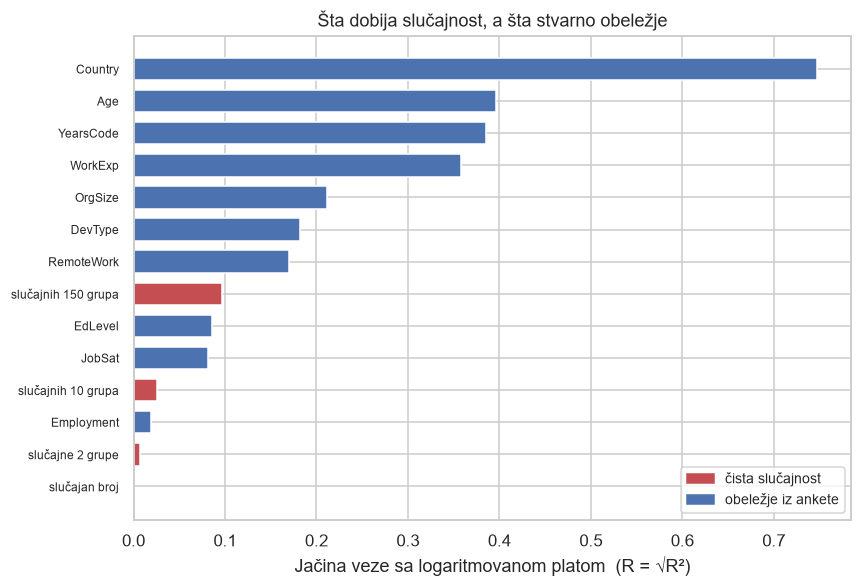

najjača slučajna kolona:    R = 0.097  (slučajnih 150 grupa)
najslabije pravo obeležje:  R = 0.019  (Employment)

prava obeležja koja su slabija od najjače slučajne kolone:
  ['EdLevel', 'JobSat', 'Employment']

najveći prilagođeni R² među slučajnim kolonama: 0.0001
najmanji prilagođeni R² među obeležjima ankete: 0.0003
slučajnih kolona značajnih na pragu 0,05:       0 od 4


In [8]:
comparison = pd.concat([
    noise_table.assign(vrsta="čista slučajnost"),
    reference_table.assign(vrsta="obeležje iz ankete"),
]).sort_values("R")

NOISE_COLOR, REAL_COLOR = "#C44E52", "#4C72B0"
colors = [NOISE_COLOR if v == "čista slučajnost" else REAL_COLOR
          for v in comparison["vrsta"]]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(range(len(comparison)), comparison["R"], color=colors, height=0.7)
ax.set_yticks(range(len(comparison)))
ax.set_yticklabels(comparison.index, fontsize=8)
ax.set_xlabel("Jačina veze sa logaritmovanom platom  (R = √R²)")
ax.set_ylabel("")
ax.set_title("Šta dobija slučajnost, a šta stvarno obeležje")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in (NOISE_COLOR, REAL_COLOR)]
ax.legend(handles, ["čista slučajnost", "obeležje iz ankete"], loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

print(f"najjača slučajna kolona:    R = {noise_table['R'].max():.3f}  "
      f"({noise_table['R'].idxmax()})")
print(f"najslabije pravo obeležje:  R = {reference_table['R'].min():.3f}  "
      f"({reference_table['R'].idxmin()})")
print()
print("prava obeležja koja su slabija od najjače slučajne kolone:")
weaker = reference_table[reference_table["R"] < noise_table["R"].max()]
print(f"  {list(weaker.index)}")
print()
print(f"najveći prilagođeni R² među slučajnim kolonama: {noise_table['R2_prilag'].max():.4f}")
print(f"najmanji prilagođeni R² među obeležjima ankete: {reference_table['R2_prilag'].min():.4f}")
print(f"slučajnih kolona značajnih na pragu 0,05:       "
      f"{int((noise_table['p'] < 0.05).sum())} od {len(noise_table)}")

**Zapažanje:** Crvene trake nisu sve na levom kraju. Slučajna podela na 150 grupa dobija **R = 0,097**, a
ispis ispod grafika imenuje tri prava obeležja koja su **slabija** od nje: `EdLevel` (0,086), `JobSat`
(0,081) i `Employment` (0,019). Tek od `RemoteWork` (0,170) naviše nema više nijedne crvene trake.

Grafik je crtan na skali R. Ako pređemo na **prilagođeni R²** — druga skala, koja nije na grafiku nego u
ispisu ispod njega — poredak se ispravlja: slučajnost stiže najviše do **0,0001**, a najslabije pravo
obeležje je na **0,0003**. Nijedna slučajna kolona nije značajna na pragu 0,05.

**Tumačenje:** Grafik pokazuje ono što se iz dve odvojene tabele nije videlo — da se dva skupa
**preklapaju**, i to na donjoj trećini skale. Da smo promenljive ocenjivali običnim R² ili R i uzimali sve
iznad nekog okruglog broja, primili bismo čist šum a odbacili `EdLevel`, dakle nivo obrazovanja.

Prilagođeni R² to preklapanje uklanja, i zato pravilo gradimo na njemu, a ne na skali sa grafika. Grafik
je tu da pokaže **zašto** je taj korak potreban.

Za nas iz ovoga slede dve granice koje nismo izmislili nego izmerili: **donja granica**, ispod koje se promenljiva ne razlikuje od slučajnosti, i **mesto gde prestaje preklapanje**, iznad kog je promenljiva sigurno u rangu
pravih anketnih obeležja.

### 2.3 Šta merilo ne vidi: oblik veze

Merilo koje smo upravo postavili brojčanu promenljivu stavlja u regresiju kao **jednu kolonu**, pa kroz
podatke provlači **pravu liniju**. To je u redu ako veza jeste prava — ali ako plata raste brzo pa se
zaravnjuje, prava to ne može da isprati i R² ispada nisko iz pogrešnog razloga.

Koliko je to stvarno, merimo na dva načina.

**Spearmanovim koeficijentom.** Pearsonov R, koji smo do sada računali, meri koliko dobro kroz tačke
prolazi prava. Spearmanov ρ radi na **rangovima** — meri samo da li jedna vrednost raste kad druga raste,
bez obzira na oblik. Ako se ta dva razilaze, veza je monotona ali zakrivljena.

**Slobodnim oblikom.** Ovo traži objašnjenje, jer nije očigledno šta znači. Uzmimo `WorkExp`, radni
staž, koji ima pedesetak različitih vrednosti — 0, 1, 2 i tako dalje. U merilu on ulazi kao **jedna
kolona**, pa svaka dodatna godina staža pomera predviđanje za **isti iznos**; to i jeste prava linija.
Slobodan oblik znači da umesto te jedne kolone napravimo **po jednu kolonu za svaku vrednost** — jednu
za „nula godina", jednu za „jedna godina" i tako redom — pa model svakoj godini može da dodeli sopstveni
nivo, nezavisno od ostalih. Time može da isprati bilo kakav oblik: i uspon, i zaravnjenje, i pad.

To je isto dummy enkodiranje koje kategorijske promenljive ionako dobijaju. Cena je što promenljiva sada
traži mnogo više kolona, pa poređenje čitamo sa **prilagođenog** R², koji tu cenu i naplaćuje.

Oba računa radimo za tri obeležja koja u merilo ulaze kao broj: **`WorkExp` (radni staž), `YearsCode`
(godine programiranja) i `JobSat` (zadovoljstvo poslom)**. Kategorijska obeležja — zemlja, tip posla,
uzrast — već su slobodnog oblika, jer svaka kategorija i inače dobija svoju kolonu.

In [9]:
from scipy import stats

# Only the features that enter as a single numeric column; a categorical one is
# already free to take any shape, since every category gets its own column.
NUMERIC_REFERENCE = ["WorkExp", "YearsCode", "JobSat"]


def as_categories(values):
    """The same column with every value treated as its own category."""
    text = values.round().astype("Int64").astype(str)
    return text.where(values.notna())


rows = []
for name in NUMERIC_REFERENCE:
    values = train[name]
    both = values.notna() & train[TARGET_LOG].notna()
    straight = signal(values)
    free = signal(as_categories(values))
    rows.append({
        "kolona": name,
        "Pearson_R": stats.pearsonr(values[both], train.loc[both, TARGET_LOG])[0],
        "Spearman_rho": stats.spearmanr(values[both], train.loc[both, TARGET_LOG])[0],
                "prilag_R2_prava_linija": straight["R2_prilag"],
        "prilag_R2_slobodan_oblik": free["R2_prilag"],
    })

shape = pd.DataFrame(rows)
print(shape.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print()
for _, row in shape.iterrows():
    print(f"  {row['kolona']:<10} Spearman veći od Pearsona za {row['Spearman_rho'] - row['Pearson_R']:+.3f}; "
          f"slobodan oblik dobija {row['prilag_R2_slobodan_oblik'] / row['prilag_R2_prava_linija']:.2f} puta veći prilagođeni R²")

   kolona  Pearson_R  Spearman_rho  prilag_R2_prava_linija  prilag_R2_slobodan_oblik
  WorkExp     0.3580        0.4426                  0.1281                    0.1988
YearsCode     0.3849        0.4449                  0.1481                    0.2323
   JobSat     0.0814        0.1035                  0.0066                    0.0110

  WorkExp    Spearman veći od Pearsona za +0.085; slobodan oblik dobija 1.55 puta veći prilagođeni R²
  YearsCode  Spearman veći od Pearsona za +0.060; slobodan oblik dobija 1.57 puta veći prilagođeni R²
  JobSat     Spearman veći od Pearsona za +0.022; slobodan oblik dobija 1.68 puta veći prilagođeni R²


### Grafik 2 — kako plata zaista raste sa radnim stažom

**Motivacija:** brojevi iznad kažu **da** prava linija nešto promašuje, ali ne i **gde**. Crtamo dve
stvari jednu preko druge: **stvarnu medijanu plate po godinama staža**, i **pravu liniju koju kroz iste
te podatke provlači merilo iz odeljka 2.2** — dakle regresiju logaritmovane plate na jednu jedinu kolonu
`WorkExp`. Tako se vidi na kom delu raspona se razilaze. Uzimamo samo godine iza kojih stoji bar pedeset
ispitanika, da tačka na kraju ose ne bi bila jedan čovek.

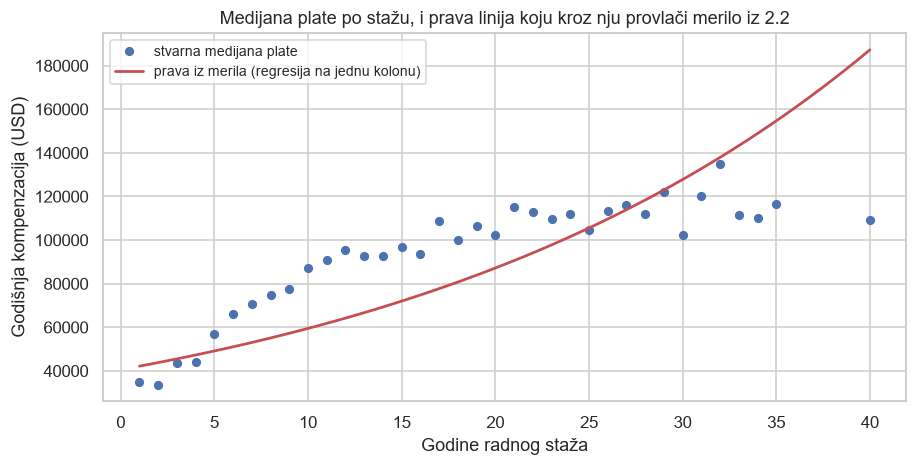

medijana plate pri  1 god. staža:    34,760 USD
pri 10 god.:                       87,011 USD   (rast 150%)
pri 40 god.:                      109,176 USD   (dalji rast  25%)


In [10]:
# Fewer than this many people behind a point and the median is just noise.
MIN_PER_YEAR = 50

by_year = train.groupby(train["WorkExp"].round())[TARGET].agg(["median", "size"])
by_year = by_year[by_year["size"] >= MIN_PER_YEAR]

fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(by_year.index, by_year["median"], marker="o", markersize=5, linewidth=0,
        color="#4C72B0", label="stvarna medijana plate")

# The straight line the measure fits, brought back from logarithm to dollars.
line = sm.OLS(train[TARGET_LOG].to_numpy(),
              sm.add_constant(train[["WorkExp"]].astype(float).to_numpy())).fit()
grid = np.linspace(by_year.index.min(), by_year.index.max(), 60)
ax.plot(grid, 10 ** line.predict(sm.add_constant(grid.reshape(-1, 1))),
        color="#C44E52", linewidth=1.8,
        label="prava iz merila (regresija na jednu kolonu)")

ax.set_xlabel("Godine radnog staža")
ax.set_ylabel("Godišnja kompenzacija (USD)")
ax.set_title("Medijana plate po stažu, i prava linija koju kroz nju provlači merilo iz 2.2")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

ten = by_year.index[by_year.index <= 10][-1]
print(f"medijana plate pri {int(by_year.index[0]):>2} god. staža: {by_year['median'].iloc[0]:>9,.0f} USD")
print(f"pri {int(ten):>2} god.:                    {by_year.loc[ten, 'median']:>9,.0f} USD   "
      f"(rast {100 * (by_year.loc[ten, 'median'] / by_year['median'].iloc[0] - 1):>3.0f}%)")
print(f"pri {int(by_year.index[-1]):>2} god.:                    {by_year['median'].iloc[-1]:>9,.0f} USD   "
      f"(dalji rast {100 * (by_year['median'].iloc[-1] / by_year.loc[ten, 'median'] - 1):>3.0f}%)")

**Zapažanje:** Veza raste, ali ne pravolinijski. Plata brzo raste kroz prvih desetak godina staža, a
posle toga se kriva zaravnjuje — ispis pod grafikom daje rast u prvom delu i znatno manji u ostatku.
Crvena prava preseca tačke umesto da ih prati.

**Tumačenje:** **Spearmanov ρ je kod sva tri obeležja veći od Pearsonovog R**, a slobodan oblik dobija
osetno veći prilagođeni R² od prave linije. Merilo, dakle, **potcenjuje** promenljive sa zakrivljenom
vezom, i to nije sitnica.

Koliko je to važno, zavisi od toga šta se sa merilom radi. Granica koja nešto zaista izbacuje je donja,
a ne gornja — pa pitanje glasi da li bi ijedna promenljiva prešla iz jedne grupe u drugu kad bi joj se
dozvolio slobodan oblik. Na to odgovaramo u odeljku 4.2, gde istu proveru sprovodimo nad **svim**
promenljivama koje napravimo.

Spearmana pri tome **ne uzimamo kao merilo**, i razlog nije samo skala. Merilo iz odeljka 2.2 mora da
da uporediv broj i za brojčanu i za **kategorijsku** promenljivu — a rangovi se na kategoriju ne mogu
primeniti: zemlje se ne mogu poređati od najmanje ka najvećoj. Spearman bi, dakle, mogao da izmeri samo
tri obeležja iz gornje tabele, a zemlju, tip posla i uzrast ne bi mogao uopšte.

Uz to, ρ i prilagođeni R² odgovaraju na različita pitanja. ρ kaže **da li** plata raste kad promenljiva
raste; prilagođeni R² kaže **koliki deo razlika u plati** promenljiva objašnjava, uz kaznu za broj kolona
koje je za to potrošila. Obe naše granice stoje na tom drugom pitanju.

Zato Spearman ostaje **dijagnostika** — potvrđuje da je veza zakrivljena. Ono što se sa merilom zaista
poredi je slobodan oblik, jer je na istoj skali i odgovara na isto pitanje.

### 2.4 Šta se dešava kad obeležja rade zajedno

Iz prethodne tabele lako se izvuče pogrešan zaključak: da je `Country` jedino što vredi, a da su ostala
obeležja skoro bezvredna jer im je R² mali. Pre nego što na tom merilu zasnujemo bilo kakvo pravilo,
moramo da proverimo da li ono uopšte meri ono što nas zanima.

Merenje iz 2.2 je **samostalno** — svaka promenljiva se meri sama, kao da je jedina u modelu. Model,
međutim, koristi sve odjednom, a obeležja se međusobno dopunjuju: zadovoljstvo poslom samo ne govori
mnogo, ali uz zemlju i veličinu firme može da razdvoji slučajeve koje ta dva ne razdvajaju.

Zato pravimo tri modela — samo zemlja, devet ostalih bez zemlje, i svih deset zajedno — pa upoređujemo.
Ako se R² zajedničkog modela ne razlikuje bitno od najboljeg pojedinačnog, onda su ostala obeležja zaista
suvišna. Ako se razlikuje, samostalno merenje potcenjuje njihovu vrednost i sme da služi samo za odbacivanje, ne za rangiranje.

In [11]:
def fit_together(names):
    """One regression on several columns at once, so their joint effect shows."""
    blocks = []
    for name in names:
        values = train[name]
        if values.dtype.kind in "if":
            blocks.append(pd.DataFrame({name: values.astype(float)}))
        else:
            blocks.append(pd.get_dummies(values.astype(str), prefix=name,
                                         drop_first=True, dtype=float))
    design = sm.add_constant(pd.concat(blocks, axis=1), has_constant="add")
    model = sm.OLS(train[TARGET_LOG].to_numpy(), design.to_numpy()).fit()
    return model, design.shape[1] - 1


others = [c for c in REFERENCE if c != "Country"]
for names, label in [(["Country"], "samo Country"),
                     (others, "devet ostalih, bez Country"),
                     (REFERENCE, "svih deset zajedno")]:
    model, columns = fit_together(names)
    print(f"{label:<28} R={np.sqrt(model.rsquared):.3f}   R2={model.rsquared:.4f}   "
          f"prilagođeni={model.rsquared_adj:.4f}   kolona={columns:>3}")

together, _ = fit_together(REFERENCE)
best_alone = reference_table["R2"].max()
print()
print(f"najbolje pojedinačno obeležje samo:  R2 = {best_alone:.4f}")
print(f"svih deset zajedno:                  R2 = {together.rsquared:.4f}")
print(f"dobitak od zajedničkog rada:         {together.rsquared - best_alone:+.4f}")

samo Country                 R=0.747   R2=0.5587   prilagođeni=0.5544   kolona=141
devet ostalih, bez Country   R=0.516   R2=0.2658   prilagođeni=0.2627   kolona= 62


svih deset zajedno           R=0.806   R2=0.6491   prilagođeni=0.6442   kolona=203

najbolje pojedinačno obeležje samo:  R2 = 0.5587
svih deset zajedno:                  R2 = 0.6491
dobitak od zajedničkog rada:         +0.0904


**Zapažanje:** Zajednički model svih deset obeležja ima **R² = 0,6491** (R = 0,806), naspram **0,5587**
koliko dobija sama zemlja — dobitak je **+0,0904**. Onih devet obeležja bez zemlje, od kojih nijedno samo
ne prelazi R² od 0,1568, **zajedno dobijaju 0,2658**, dakle R = 0,516.

**Tumačenje:** Ovo je odgovor na sumnju koju tabela iz 2.2 sama po sebi izaziva. Obeležja koja
pojedinačno izgledaju slabo **nisu bezvredna** — devet njih zajedno objašnjava preko četvrtine varijanse,
a dodata uz zemlju podižu model za skoro deset procentnih poena. Pojedinačno merenje ih, dakle,
sistematski potcenjuje.

Razlog je što se obeležja dopunjuju. Zemlja kaže na kom je tržištu ispitanik, ali ne razlikuje početnika
od seniora u istoj zemlji; staž to razdvaja, ali ne razlikuje Nemačku od Indije. Tek zajedno pokrivaju obe
vrste razlike.

Iz ovoga slede dve stvari za sve što dalje radimo. Prva: samostalno merenje ostaje **filter za odbacivanje**, ne merilo za konačan izbor — njime izbacujemo ono što ne razlikuje ništa, a ne rangiramo ono što prolazi.
Druga: ne treba očekivati da će izvedene promenljive imati velike samostalne R². Ako je i najjače anketno
pitanje posle zemlje na 0,1568, izvedena promenljiva koja dobije 0,03 nije razočaranje nego uobičajen
doprinos.

### 2.5 Pravilo koje primenjujemo dalje

Sve je izmereno, pa pravilo možemo da zapišemo pre nego što napravimo ijednu novu promenljivu.
**Postavljamo ga sada baš zato da kasnije ne bismo prag birali prema tome kako je ispalo** — obe granice
potiču iz merenja koja su gotova, a nijedna izvedena promenljiva još ne postoji, pa ni njihov rezultat
ne može da utiče na to gde prag stoji.

Za svaku izvedenu promenljivu računamo isto što i gore i svrstavamo je u jednu od tri grupe, po granicama
koje smo maločas izmerili. Obe granice čitamo sa **prilagođenog** R², jer smo videli da se obični ne sme
porediti između promenljivih različitog oblika; uz svaku je u zagradi ista granica na skali R, radi
osećaja:

1. **Šum.** Promenljiva koja padne na p-vrednosti (≥ 0,05) ili čiji je prilagođeni R² **0,0001 ili niži**
   (R ≈ 0,01) ne razlikuje se od slučajno napravljene kolone — toliko je, naime, dobila najbolja od naše
   četiri slučajne. Takva se ne pravi, bez obzira na to koliko izgleda smisleno.
2. **Slaba.** Prilagođeni R² iznad te donje granice, ali **ispod 0,0286** (R ≈ 0,17) — koliko dobija `RemoteWork`,
   najslabije od tri obeležja za koja smo u prethodnom notebook-u utvrdili da **moraju** ući u model.
   Takvu promenljivu zadržavamo samo ako je jeftina, dakle ako traži jednu ili dve kolone, i ako ne
   ponavlja informaciju koju već imamo. Uz nju upisujemo da je slaba.
3. **Nosi signal.** Prilagođeni R² **0,0286 ili više**, dakle u rangu obeležja koja su u anketu ušla kao
   pitanja. Takva promenljiva ulazi bez posebnog obrazloženja.

**Šta ovo merilo ne može.** Tri stvari, i vredi ih imati na umu pri svakom broju koji sledi:

1. **Meri samo pravolinijsku vezu.** Brojčana promenljiva ulazi u regresiju kao jedna kolona, pa model
   kroz podatke provlači pravu liniju. Promenljiva čija veza sa platom nije prava — recimo ona koja
      raste pa se zaravnjuje — dobiće nizak R² iako veza postoji. Koliko to iznosi, izmerili smo u odeljku
   2.3; nad svim izvedenim promenljivama isto merimo u odeljku 4.2.
2. **Meri svaku promenljivu odvojeno od ostalih.** Ne vidi da dve promenljive nose istu informaciju, pa
   druga uz prvu ne dodaje ništa; ne vidi ni da promenljiva sa slabim samostalnim rezultatom može biti
      korisna kada uz nju stoje druge. Koliko je ta razlika velika, izmerili smo u odeljku 2.4.
3. **Ovo je prvi filter za odbacivanje, a ne konačan izbor promenljivih.** Promenljiva koja prođe nije
   time zaslužila mesto u modelu, nego samo pravo da se o njoj dalje razmišlja. Šta zaista ostaje,
   odlučuje se u fazi modelovanja, merilima za izbor modela sa predavanja.

Tri napomene uz pravilo, da se ne bi čitalo strože nego što jeste.

Gornja granica nije zakon prirode nego **tačka na skali koju smo izmerili** — mesto iznad kog se, na
Grafiku 1, prava obeležja i slučajnost više ne preklapaju. Ako neka promenljiva padne tik ispod nje, to
nije razlog da se odbaci nego da se o njoj odluči po kriterijumu iz tačke 2.

Brojevi deluju mali i to je u redu. Kao što smo videli u 2.4, ni prava anketna pitanja osim zemlje ne idu
preko 0,1568 samostalno, a zajedno stižu do 0,6491. Prag se zato postavlja prema tome šta se u **ovim**
podacima dobija, a ne prema nekoj opštoj predstavi o tome koliki R² treba da bude.

I dalje važi ono što smo rekli na početku sekcije: ovo je prvi filter, ne konačan izbor. Promenljiva koja prođe
nije time zaslužila mesto u konačnom modelu, nego samo pravo da se o njoj dalje razmišlja. Šta zaista
ostaje, odlučuje se u fazi modelovanja, gde se meri doprinos promenljive **uz sve ostale**, a ne
samostalno.

## 3. Multi-select kolone iznutra

Trideset šest kolona je i dalje u obliku u kom ih model ne može primiti: u svakoj ćeliji stoji jedan
string u kome je više odgovora spojeno tačka-zarezom, na primer `Python;JavaScript;SQL`. Enkodiranje
takve kolone kao obične kategorijske nema smisla — u prethodnom notebook-u smo videli da bi svaka
različita **kombinacija** postala sopstvena kategorija, pa bi enkodiranje tekstualnih kolona dalo
višestruko više kolona nego što skup ima redova.

Iz njih zato treba izvesti nove promenljive. Pre nego što to uradimo, moramo da znamo šta je unutra, a to
ne pretpostavljamo nego čitamo iz podataka: koje kolone dolaze iz istog pitanja, koliko odgovora svako
pitanje nudi, koliko ih ispitanik zapravo bira, šta znači kad je ćelija prazna, i da li su nam sve tri
kolone jednog pitanja uopšte potrebne.

### 3.1 Koje kolone dolaze iz istog pitanja

Anketa jedno pitanje ume da izveze kroz više kolona, pa `LanguageHaveWorkedWith` i `LanguageAdmired` nisu
dva pitanja nego dva izvoda iz jednog. Da bismo videli koje kolone idu zajedno, radimo u dva koraka.

**Prvo grupišemo iz samih podataka.** Kolone koje nude **isti spisak ponuđenih odgovora** verovatno dolaze
iz istog pitanja; taj spisak dobijamo tako što razdvojimo sve odgovore po tačka-zarezu i pogledamo koje se
stavke javljaju. Uz to tražimo i zajednički početak imena, jer anketa ume isti spisak da ponudi na dva
različita pitanja.

**Zatim to proveravamo u `survey_results_schema.csv`.** Tamo za svako pitanje stoji njegova oznaka, tip i
pun tekst. Ako je naše grupisanje ispravno, ime svake grupe mora da odgovara jednom pitanju iz šeme — a
tekst tog pitanja nam usput kaže i **kako je pitanje postavljeno**, što će nam trebati u odeljku 3.3.

In [12]:
import sys

sys.path.insert(0, str(Path.cwd().parent / "src"))
from data_loader import load_raw

# What we still need from the raw download: the schema, which carries the
# question each column came from, its type and its full text, and the raw column
# list, so we can see which columns a question had before the cleaning notebook
# dropped some of them.
raw, schema = load_raw()
question_info = schema.drop_duplicates(subset="qname").set_index("qname")

# The answers a question offers, read out of the data itself.
vocabulary = {column: frozenset(train[column].dropna().astype(str).str.split(";").explode())
              for column in multi_select}

by_vocabulary = {}
for column, items in vocabulary.items():
    by_vocabulary.setdefault(items, []).append(column)


def common_prefix(names):
    """The longest beginning all these column names share, cut at a word boundary.

    Without the trimming the prefix can end in the middle of a word: "Personal
    use" and "Professional use" share the leading "P", which is not a name.
    """
    first, last = min(names), max(names)
    length = 0
    while length < min(len(first), len(last)) and first[length] == last[length]:
        length += 1
    while length > 0 and any(name[length:length + 1].islower() for name in names):
        length -= 1
    return first[:length]


def question_name(columns):
    """The schema entry these columns came from, if the schema knows one.

    A group keeps the longest name from the schema that starts every one of its
    columns; where the schema has no such entry we fall back on the shared prefix.
    """
    candidates = [q for q in question_info.index.astype(str)
                  if all(column.startswith(q) for column in columns)]
    return max(candidates, key=len) if candidates else common_prefix(columns)


questions = {}
for columns in by_vocabulary.values():
    if common_prefix(columns):
        questions[question_name(columns)] = columns
    else:
        for column in columns:
            questions[question_name([column])] = [column]

print(f"multi-select kolona:            {len(multi_select)}")
print(f"različitih spiskova odgovora:   {len(by_vocabulary)}")
print(f"pitanja iz kojih dolaze:        {len(questions)}")
print(f"svaka kolona u tačno jednom pitanju: "
      f"{sum(len(c) for c in questions.values()) == len(multi_select)}")
print()
print(f"{'pitanje':<20} {'kol':>3}  {'stavki':>6}  {'tip':<7} tekst pitanja")
for name, columns in sorted(questions.items(), key=lambda kv: (-len(kv[1]), kv[0])):
    known = name in question_info.index
    kind = question_info.loc[name, "type"] if known else "—"
    text = str(question_info.loc[name, "question"]) if known else "(nema u šemi)"
    text = re.sub(r"<[^>]+>|\s+", " ", text).strip()
    print(f"{name:<20} {len(columns):>3}  {len(vocabulary[columns[0]]):>6}  {kind:<7} {text[:64]}")

print()
print(f"grupa čije ime postoji u šemi: "
      f"{sum(name in question_info.index for name in questions)} od {len(questions)}")
print()
# A technology question is exported as up to these three views of one grid.
TRIPLE_VIEWS = ("HaveWorkedWith", "WantToWorkWith", "Admired")
print("pitanja koja su deo svojih kolona izgubila u prethodnom notebook-u:")
for name, columns in sorted(questions.items()):
    views = [c for c in raw.columns if c.startswith(name) and c[len(name):] in TRIPLE_VIEWS]
    lost = sorted(set(views) - set(columns))
    if lost:
        print(f"  {name:<10} u sirovom fajlu {len(views)} kolone, ovde {len(columns)}   ispalo: {lost}")

shared = [columns for columns in by_vocabulary.values()
          if len(columns) > 1 and not common_prefix(columns)]
print()
print(f"različita pitanja koja dele isti spisak odgovora: {shared}")

multi-select kolona:            36
različitih spiskova odgovora:   16
pitanja iz kojih dolaze:        17
svaka kolona u tačno jednom pitanju: True

pitanje              kol  stavki  tip     tekst pitanja
AIAgentChallenges      3       7  Matrix  To what extent do you agree with the following statements regard
AITool                 3      14  Matrix  Which parts of your development workflow are you currently integ
CommPlatform           3      18  Matrix  Which  community platforms  have you utilized considerably or co
Database               3      30  Matrix  Which  database environments  have you done extensive developmen
DevEnvs                3      27  Matrix  Which  development environments and AI-enabled code editing tool
Language               3      42  Matrix  Which  programming, scripting, and markup languages  have you do
OfficeStackAsync       3      25  Matrix  Which  collaborative work management and/or code documentation t
Platform               3      42  Matrix  Which

**Zapažanje:** Grupisanje izvedeno iz podataka poklapa se sa šemom u potpunosti — **svih 17 imena grupa
postoji u šemi kao pitanje**, i nijedna kolona nije ostala izvan grupe ili u dve.

Iz kolone `tip` vidi se odakle razlika u broju kolona. Pitanja tipa **`MC`** su ona sa uputstvom „Select
all that apply": ispitanik iz jednog spiska čekira šta hoće, i to se izvozi kao **jedna** kolona. Takvih
je pet: `LearnCode`, `AILearnHow`, `AIFrustration`, `AIHuman` i `SO_Dev_Content`.

Pitanja tipa **`Matrix`** su tabela: redovi su ponuđene stavke, a kolone su nešto što se za svaku stavku
bira. Takvo pitanje se izvozi kao **više kolona, po jedna za svaku kolonu tabele**. Kod `Language` te
kolone su „koristio sam", „želim da koristim" i „divim se"; kod `OpSys` su „privatno" i „poslovno"; kod
`AIAgentChallenges` su stepeni slaganja.

Dva pitanja tipa `Matrix` ovde imaju **samo po jednu kolonu**, i poslednji deo ispisa pokazuje zašto:
`AIModels` i `SOTags` su u sirovom fajlu imali po tri kolone, ali su im `WantToWorkWith` i `Admired`
ispali u prethodnom notebook-u, jer su prelazili granicu od 50% nedostajućih vrednosti.

**Tumačenje:** To što spiskove čitamo iz podataka pa proveravamo šemom, a ne obrnuto, isplatilo se na dva
mesta.

Prvo, poslednji red ispisa izdvaja slučaj koji bi nas prevario: **`LearnCode` i `AILearnHow` dele
identičan spisak od 13 stavki**, jer anketa istu ponudu koristi i za pitanje kako je neko naučio da
programira i za pitanje kako je naučio da programira za AI. To su dva različita `MC` pitanja sa jednim
spiskom, pa smo uz poklapanje spiska tražili i zajednički početak imena — bez toga bi se spojila u jedno.

Drugo, sada znamo da tri kolone jednog tehnološkog pitanja **nisu tri nezavisna pitanja** nego tri kolone
iste tabele. To menja način na koji o njima razmišljamo: iz njih se mogu izvesti i poređenja koja nijedna
kolona sama ne nosi, a otvara se i pitanje da li su nam sve tri uopšte potrebne — čime se bavi odeljak 3.4.

### 3.2 Koliko se nudi, a koliko se bira

Sada kada znamo koje kolone dolaze iz kog pitanja, gledamo šta je u njima. Zanimaju nas tri broja po
koloni: koliko stavki pitanje uopšte nudi, koliko ih ispitanik izabere, i koliko je ćelija prazno.

Broj izabranih stavki računamo **samo nad ispitanicima koji su nešto izabrali**. Prazne ćelije za sada
zaobilazimo, jer još ne znamo znače li „nisam odgovorio" ili „nisam izabrao ništa" — to je pitanje kojim
se bavi odeljak 3.3.

In [13]:
question_of = {column: name for name, columns in questions.items() for column in columns}


def chosen_counts(column):
    """How many items each respondent picked, among those who picked any."""
    answered = train[column].dropna().astype(str)
    return answered.str.split(";").str.len()


records = []
for column in multi_select:
    counts = chosen_counts(column)
    records.append({
        "pitanje": question_of[column],
        "kolona": column,
        "nudi": len(vocabulary[column]),
        "nedostaje_%": round(100 * train[column].isna().mean(), 1),
        "izabrano_medijana": counts.median(),
        "izabrano_prosek": round(counts.mean(), 1),
        "izabrano_max": counts.max(),
    })

inventory = pd.DataFrame(records).sort_values(["pitanje", "kolona"])
print(inventory.to_string(index=False))

          pitanje                                   kolona  nudi  nedostaje_%  izabrano_medijana  izabrano_prosek  izabrano_max
AIAgentChallenges                 AIAgentChallengesNeutral     7         36.4                2.0              2.0             7
AIAgentChallenges          AIAgentChallengesSomewhat agree     7         31.5                2.0              2.0             7
AIAgentChallenges          AIAgentChallengesStrongly agree     7         29.8                2.0              2.3             7
    AIFrustration                            AIFrustration     7          6.6                2.0              1.9             6
          AIHuman                                  AIHuman    10         11.7                4.0              4.5            10
       AILearnHow                               AILearnHow    13         31.9                3.0              2.9            13
         AIModels                   AIModelsHaveWorkedWith    17         48.5                3.0        

**Zapažanje:** Tri stvari se vide iz tabele.

**Bira se mnogo manje nego što se nudi.** `Language` nudi 42 jezika, a medijana izabranih je **6**;
`Platform` nudi 42, medijana je **7**. Kod dugih spiskova je taj odnos najmanji — šestina do sedmine
ponuđenog; kod kratkih pitanja je osetno veći, pa `AIHuman` nudi **10** stavki a medijana je **4**.

**Unutar tehnološkog pitanja nedostajanje raste od kolone do kolone.** Kod jezika je `HaveWorkedWith`
prazan kod **6,2%** ispitanika, `WantToWorkWith` kod **19,1%**, a `Admired` kod **29,2%**. Isti redosled
je i kod `Webframe` (26,4% → 42,5% → 48,3%) i kod ostalih.

**Ima kolona u kojima je neko izabrao baš sve što se nudi.** `LanguageHaveWorkedWith` i `PlatformHaveWorkedWith` imaju
maksimum **42**, koliko i nude; `DatabaseHaveWorkedWith` ima 30 od 30, `LearnCode` 13 od 13.

**Tumačenje:** Prvi nalaz je očekivan i dobar — spiskovi su dugi, a ljudi biraju nekoliko stavki, pa
„koliko ih je izabrao" ima izgleda da bude korisna promenljiva.

Drugi nalaz ima jasno objašnjenje: tri kolone su tri uzastopna potpitanja, i što je pitanje kasnije, to ga
više ljudi preskoči. To je isti obrazac zamora koji smo videli u prethodnom notebook-u — nedostajanje
raste kako se ide dublje u anketu.

Treći nalaz treba zapamtiti kao upozorenje. Neko ko je označio svih 42 jezika najverovatnije nije redom
razmišljao o svakom, nego je označio sve. To je isti potpis neozbiljnog odgovora koji smo u prethodnom
notebook-u sreli kod broja alata, gde su se javljale okrugle i očigledno izmišljene vrednosti. Ovde ga ne ispravljamo, jer za
razliku od sto godina staža izbor svih stavki **nije nemoguć**, ali ćemo na njega paziti kada budemo pravili
promenljivu od broja izabranih stavki.

### Grafik 3 — koliko stavki ispitanik bira

**Motivacija:** Iz tabele se vidi prosek i medijana, ali ne i koliko se ispitanici međusobno razlikuju.
To je za nas ključno, jer sledeća sekcija hoće da od „broja izabranih stavki" napravi promenljivu — a ona
ima smisla samo ako se taj broj razlikuje od čoveka do čoveka. Ako svi biraju otprilike isto, promenljiva
ne razlikuje nikoga i nema šta da objasni. Crtamo raspodelu za svaku kolonu, boxplot-om, jer prikazuje
medijanu i rasipanje odjednom.

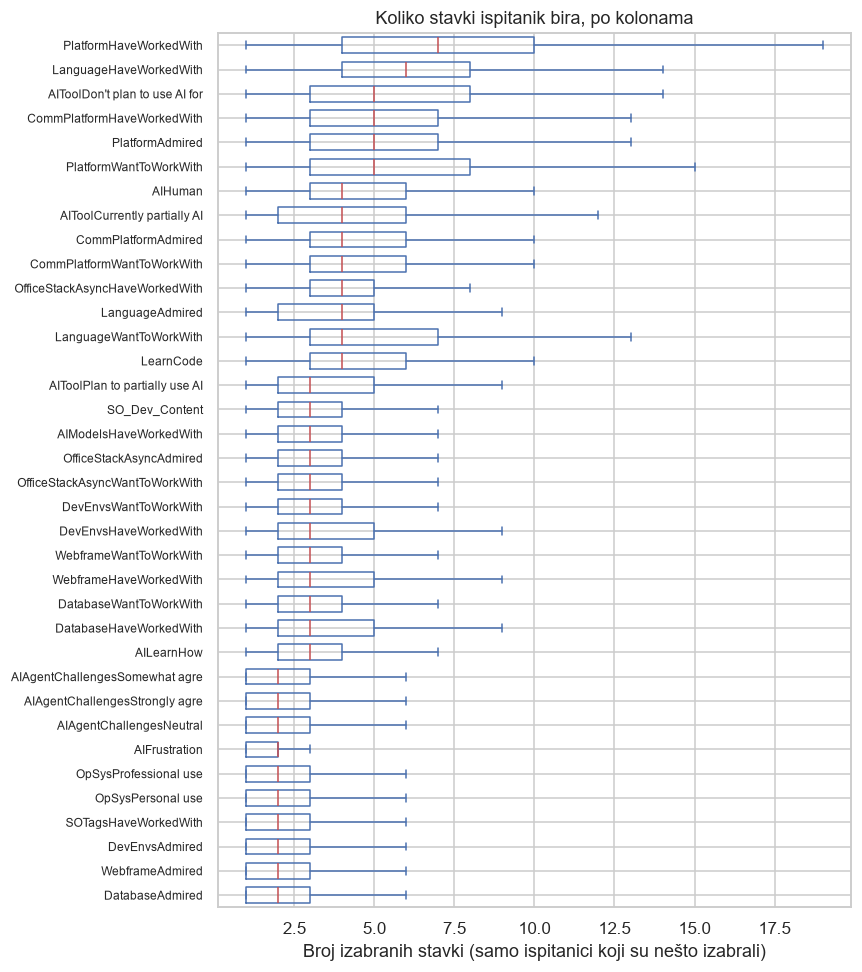

kolona kod kojih je IQR nula (tri četvrtine bira isti broj): 0 od 36

najmanje rasipanja:
         kolona  q1  medijana  q3  IQR
  AIFrustration 1.0       2.0 2.0  1.0
DatabaseAdmired 1.0       2.0 3.0  2.0
WebframeAdmired 1.0       2.0 3.0  2.0
 DevEnvsAdmired 1.0       2.0 3.0  2.0

najviše rasipanja:
                                  kolona  q1  medijana   q3  IQR
                  PlatformHaveWorkedWith 4.0       7.0 10.0  6.0
                  PlatformWantToWorkWith 3.0       5.0  8.0  5.0
AIToolDon't plan to use AI for this task 3.0       5.0  8.0  5.0
                  LanguageWantToWorkWith 3.0       4.0  7.0  4.0


In [14]:
order = sorted(multi_select, key=lambda c: chosen_counts(c).median())
data = [chosen_counts(column).to_numpy() for column in order]

fig, ax = plt.subplots(figsize=(8, 9))
ax.boxplot(data, orientation="horizontal", widths=0.65, showfliers=False,
           medianprops={"color": "#C44E52"},
           boxprops={"color": "#4C72B0"},
           whiskerprops={"color": "#4C72B0"},
           capprops={"color": "#4C72B0"})

ax.set_yticks(range(1, len(order) + 1))
ax.set_yticklabels([c[:30] for c in order], fontsize=8)
ax.set_xlabel("Broj izabranih stavki (samo ispitanici koji su nešto izabrali)")
ax.set_ylabel("")
ax.set_title("Koliko stavki ispitanik bira, po kolonama")
plt.tight_layout()
plt.show()

spread = pd.DataFrame({
    "kolona": order,
    "q1": [np.percentile(d, 25) for d in data],
    "medijana": [np.median(d) for d in data],
    "q3": [np.percentile(d, 75) for d in data],
})
spread["IQR"] = spread["q3"] - spread["q1"]
print(f"kolona kod kojih je IQR nula (tri četvrtine bira isti broj): "
      f"{int((spread['IQR'] == 0).sum())} od {len(spread)}")
print()
print("najmanje rasipanja:")
print(spread.nsmallest(4, "IQR").to_string(index=False))
print()
print("najviše rasipanja:")
print(spread.nlargest(4, "IQR").to_string(index=False))

**Zapažanje:** Nijedna kolona nema IQR jednak nuli — **0 od 36** — dakle nigde tri četvrtine ispitanika ne
bira isti broj stavki. Najmanje rasipanja ima `AIFrustration`, gde kutija ide od 1 do 2 stavke, a najviše
`PlatformHaveWorkedWith`, sa kutijom od 4 do 10 i **IQR od 6**.

Na grafiku se vidi i da su kutije pomerene ulevo, uz nulu, sa dugim repom udesno: većina bira nekoliko
stavki, a manjina mnogo.

**Tumačenje:** Ovo je odgovor na pitanje zbog kog je grafik i nacrtan. Broj izabranih stavki **se razlikuje
između ispitanika u svakoj koloni**, pa promenljiva napravljena od njega ima šta da razlikuje. Da je
negde IQR bio nula, ta kolona bi za takvu promenljivu bila beskorisna i to bismo saznali pre nego što je
napravimo.

Razlika u rasipanju između kolona je usput i sama po sebi informacija: kod `PlatformHaveWorkedWith` ljudi
se razlikuju mnogo više nego kod `AIFrustration`, pa se od prve može očekivati jača promenljiva. Da li je
tako, meriće se u sledećoj sekciji, ne pretpostavljati odavde.

### 3.3 Šta znači prazna ćelija

Ovo je pitanje koje određuje sve što sledi, a odgovor nije isti za sve kolone.

Kod pitanja izvezenog kroz **jednu** kolonu prazno polje znači da ispitanik na pitanje nije odgovorio. Kod
pitanja izvezenog kroz **više** kolona prazna kolona može da znači nešto sasvim drugo: da je ispitanik
odgovorio, ali da u tom delu pitanja nije izabrao nijednu stavku.

Da to ne bismo pretpostavljali, pogledaćemo **kako je pitanje zaista postavljeno** — tekst iz šeme stoji u
ispisu ispod. Zatim, za svako pitanje sa više kolona, brojimo da li su prazne **sve** njegove kolone ili
samo neke. Ako su prazne sve, ispitanik pitanje nije video ili ga je preskočio. Ako su prazne neke a druge
popunjene, pitanje je odgovoreno i praznina znači nulu.

In [15]:
# The wording decides how an empty cell should be read, so we print it in full.
for name in ["AIAgentChallenges", "Language"]:
    text = re.sub(r"<[^>]+>|\s+", " ", str(question_info.loc[name, "question"])).strip()
    print(f"{name} ({question_info.loc[name, 'type']}), kolone {questions[name]}:")
    print(f"  {text}")
    print()

multi_column_questions = {name: columns for name, columns in questions.items() if len(columns) > 1}

records = []
means_zero = pd.Series(False, index=train.index)
for name, columns in multi_column_questions.items():
    empty = train[columns].isna()
    some_empty = empty.any(axis=1) & ~empty.all(axis=1)
    means_zero |= some_empty
    records.append({
        "pitanje": name,
        "kolona": len(columns),
        "prazne_sve": int(empty.all(axis=1).sum()),
        "prazne_neke": int(some_empty.sum()),
        "prazna_nijedna": int((~empty.any(axis=1)).sum()),
    })

emptiness = pd.DataFrame(records).sort_values("prazne_neke", ascending=False)
emptiness["udeo_nula_%"] = (100 * emptiness["prazne_neke"]
                            / (emptiness["prazne_neke"] + emptiness["prazna_nijedna"])).round(1)
print(emptiness.to_string(index=False))
print()
single_column_questions = [name for name, columns in questions.items() if len(columns) == 1]
print(f"pitanja izvezenih kroz jednu kolonu: {len(single_column_questions)}   "
      f"kroz više kolona: {len(multi_column_questions)}")
print(f"ispitanika kod kojih bar jedno pitanje ima prazninu koja znači nulu: "
      f"{int(means_zero.sum()):,} ({100 * means_zero.mean():.1f}%)")

AIAgentChallenges (Matrix), kolone ['AIAgentChallengesNeutral', 'AIAgentChallengesStrongly agree', 'AIAgentChallengesSomewhat agree']:
  To what extent do you agree with the following statements regarding AI agents?

Language (Matrix), kolone ['LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired']:
  Which  programming, scripting, and markup languages  have you done extensive development work in over the past year, and which do you want to work in over the next year? (If you both worked with the language and want to continue to do so, please check both boxes in that row.)

          pitanje  kolona  prazne_sve  prazne_neke  prazna_nijedna  udeo_nula_%
AIAgentChallenges       3        1860         7234            5514         56.7
           AITool       3        1230         7174            6204         53.6
         Database       3        2866         3594            8148         30.6
         Language       3         909         3350           10349         24.5
 Off

**Zapažanje:** Tekst pitanja, ispisan iznad tabele, rešava dilemu.

`Language` je **jedno** pitanje, i njegov tekst izričito kaže: *„...and which do you want to work in over
the next year? (If you both worked with the language and want to continue to do so, please check both
boxes in that row.)"* Dakle jedna tabela, u svakom redu jedan jezik, a u redu dva polja za čekiranje.
`AIAgentChallenges` je takođe jedna tabela, gde se za svaku tvrdnju bira stepen slaganja.

Brojevi zatim pokazuju koliko je praznina te vrste. Kod svih deset pitanja sa više kolona postoji velika
grupa ispitanika kojima su neke kolone prazne a druge popunjene: kod `AIAgentChallenges` **7.234**,
odnosno **56,7%** onih koji su na pitanje uopšte odgovorili, kod `AITool` **53,6%**, a kod `OpSys` svega
**5,9%**. Ukupno **12.059 ispitanika, odnosno 82,6% trening skupa**, ima bar jedno pitanje sa takvom
prazninom.

**Tumačenje:** Pošto je reč o jednoj tabeli, a ne o tri uzastopna pitanja, prazna kolona ne znači da je
ispitanik nešto preskočio — znači da u toj koloni tabele **nije čekirao nijedan red**. To je nula
izabranih stavki, dakle vrednost, a ne nedostajući podatak. Kod `AIAgentChallenges` je zaključak još
čvršći, jer se stepeni slaganja međusobno isključuju: stavka ocenjena sa „Strongly agree" ne može biti i
u koloni „Neutral", pa ko je bilo šta svrstao, pitanje je odgovorio.

Da smo prazninu tretirali kao nedostajanje, izmislili bismo je kod više od polovine ispitanika kod dva
pitanja, i kod 82,6% njih bar negde.

Ostaje jedna ograda koju ne možemo da uklonimo. To što neko nije čekirao nijedno polje u koloni „want" ne
razlikuje onoga ko zaista ne želi nijednu tehnologiju od onoga ko se tim delom tabele nije bavio. Iz
podataka se ta dva slučaja ne razdvajaju, jer bismo morali da znamo šta je ispitanik mislio.

Zato u sledećoj sekciji radimo ovako: praznu kolonu tumačimo kao **nulu izabranih stavki kada je ispitanik
na to pitanje odgovorio bar u jednoj koloni**, a kao **nedostajanje kada su mu prazne sve kolone tog
pitanja**. Uz izvedene promenljive ide i indikator koji pamti da li je pitanje uopšte odgovoreno, po istom
principu po kom smo u prethodnom notebook-u uveli kolone `NotAnswered_*`.

### 3.4 Hipoteza 5 — da li su nam potrebne sve tri kolone

Sedam tehnoloških pitanja izvezeno je kroz tri kolone: `HaveWorkedWith`, `WantToWorkWith` i `Admired`.
Prve dve odgovaraju na ono što tekst pitanja i traži — šta si koristio i šta bi želeo da koristiš. Treća
se u tekstu pitanja **ne pominje nigde**, pa nije jasno odakle dolazi.

Najverovatnije objašnjenje je da je Stack Overflow nije ni pitao nego izračunao, kao presek prve dve:
tehnologija kojoj se ispitanik „divi" bila bi ona koju je koristio i želi da nastavi da koristi. Ako je
tako, ta kolona ne nosi nijedan podatak koji već nemamo, i promenljive izvedene iz nje ponavljale bi
informaciju — što je problem o kome smo učili kao o kolinearnosti.

> **Hipoteza:** Kolona `Admired` nije zaseban odgovor nego je izvedena iz druge dve. Formalno: za svakog
> ispitanika skup stavki u `Admired` jednak je preseku skupova iz `HaveWorkedWith` i `WantToWorkWith`.
>
> **Kriterijum, postavljen unapred:** Hipoteza je potvrđena samo ako jednakost važi kod **svakog**
> ispitanika koji je na pitanje odgovorio, u **svih sedam** tehnoloških pitanja. Reč je o tvrdnji o
> pravilu, a ne o vezi među promenljivama, pa je jedan protivprimer dovoljan da je obori.

In [16]:
def item_sets(column):
    """Each respondent's chosen items, as a set."""
    return train[column].fillna("").astype(str).map(lambda value: set(value.split(";")) - {""})


# The seven questions exported through exactly these three views.
TRIPLE_SUFFIXES = ("HaveWorkedWith", "WantToWorkWith", "Admired")
technology_questions = [name for name, columns in questions.items()
                        if sorted(columns) == sorted(name + s for s in TRIPLE_SUFFIXES)]

records = []
for name in technology_questions:
    have, want, admired = (item_sets(name + suffix) for suffix in TRIPLE_SUFFIXES)
    answered = (have.map(len) + want.map(len) + admired.map(len)) > 0
    equal = pd.Series([a == (h & w) for h, w, a in zip(have, want, admired)], index=train.index)
    records.append({
        "pitanje": name,
        "odgovorilo": int(answered.sum()),
        "Admired == Have∩Want": int((equal & answered).sum()),
        "izuzetaka": int((~equal & answered).sum()),
    })

identity = pd.DataFrame(records).sort_values("odgovorilo", ascending=False)
print(identity.to_string(index=False))
print()
print(f"ukupno izuzetaka u svih sedam pitanja: {int(identity['izuzetaka'].sum())}")
print()

# If the set is fixed by the other two, is its size fixed as well? Among people
# who chose the same number of languages and want the same number, how much does
# the size of the intersection still move?
have, want, admired = (item_sets("Language" + suffix) for suffix in TRIPLE_SUFFIXES)
sizes = pd.DataFrame({"koristi": have.map(len), "zeli": want.map(len), "oba": admired.map(len)})
fixed = sizes[(sizes["koristi"] == 5) & (sizes["zeli"] == 5)]
print(f"ispitanika koji koriste tačno 5 i žele tačno 5 jezika: {len(fixed)}")
print(f"  koliko od njih je u preseku: od {int(fixed['oba'].min())} do {int(fixed['oba'].max())}, "
      f"medijana {fixed['oba'].median():.0f}")

         pitanje  odgovorilo  Admired == Have∩Want  izuzetaka
        Language       13699                 13699          0
OfficeStackAsync       13291                 13291          0
    CommPlatform       13114                 13114          0
         DevEnvs       11862                 11862          0
        Database       11742                 11742          0
        Platform       11450                 11450          0
        Webframe       10747                 10747          0

ukupno izuzetaka u svih sedam pitanja: 0

ispitanika koji koriste tačno 5 i žele tačno 5 jezika: 439
  koliko od njih je u preseku: od 0 do 5, medijana 5


**Zapažanje:** Jednakost važi **kod svakog ispitanika, u svakom od sedam pitanja** — ukupno **nula
izuzetaka**. Kod jezika je proverena na 13.699 ispitanika, kod okruženja za rad na 13.291, i tako redom.

**Verdikt: hipoteza je potvrđena.** Kolona `Admired` nije zaseban odgovor nego presek druge dve.

**Tumačenje:** Iz ovoga slede dve stvari, i vredi ih razdvojiti jer vode na različite strane.

**Skup stavki iz `Admired` ne nosi ništa novo.** Ako za nekog ispitanika znamo koje je tehnologije
koristio i koje želi, znamo i kojima se „divi" — to je presek ta dva skupa. Zato indikator oblika „divi se
Pythonu" ne bi bio nova promenljiva nego proizvod dve koje već imamo. Takva promenljiva ne bi bila samo
suvišna nego štetna, jer bi u model unela kolinearnost o kojoj smo učili — treću kolonu koja je tačno
određena prve dve.

**Broj stavki iz `Admired` ipak nosi nešto novo.** Ovo je važna razlika i lako se previdi. To što je skup
određen ne znači da je i njegova veličina određena veličinama druga dva. Ispis to i pokazuje: među
**439 ispitanika koji koriste tačno pet jezika i žele tačno pet**, u preseku ih ima **od 0 do 5**. Dakle
dva čoveka sa istim brojem korišćenih i istim brojem željenih jezika mogu imati potpuno različit presek —
jedan želi da nastavi sa svim jezicima koje već zna, drugi ni sa jednim.

To je zapravo zanimljiva veličina: koliko je neko **zadovoljan onim čime već radi**. Broj korišćenih i broj
željenih jezika to ne mere.

**Posledica po dalji rad.** U sekciji 5, gde od pojedinačnih stavki pravimo indikatore, kolone `Admired`
se **izostavljaju** — sve što bi dale već daju druge dve. U sekciji 4, gde brojimo izabrane stavke, one
**ostaju**, i iz njih pravimo promenljivu koja meri poklapanje između korišćenog i željenog.

### Šta sekcija ostavlja sledećoj

Sada znamo od čega pravimo promenljive:

- 36 kolona dolazi iz **17 pitanja**, i to je provereno šemom, ne pretpostavljeno. Pet pitanja je tipa
  `MC` i daje po jednu kolonu; dvanaest je tipa `Matrix`, tabela u kojoj su redovi ponuđene stavke a
  kolone ono što se za svaku bira;
- spiskovi su dugi (do 42 stavke) a bira se malo (medijana od dve do sedam), i broj izabranih stavki se
  razlikuje između ispitanika u **svakoj** koloni, jer nigde IQR nije nula;
- prazna ćelija **ne znači svuda isto**: kod pitanja sa više kolona znači nulu izabranih stavki, a
  nedostajanje samo kada su prazne sve kolone tog pitanja;
- kolona `Admired` je **presek** druge dve, bez ijednog izuzetka, pa se iz nje smeju praviti promenljive
  koje mere veličinu preseka, ali ne i indikatori pojedinačnih stavki.

Iz svega toga slede dva pravca za izvođenje promenljivih, i njima se bave naredne dve sekcije: **koliko je
stavki izabrano** (sekcija 4) i **koje su stavke izabrane** (sekcija 5). Nijedna se ne uzima zdravo za
gotovo — obe se mere merilom postavljenim u sekciji 2.

## 4. Broj izabranih stavki kao promenljiva

Prvi način da se iz multi-select kolone izvuče broj je najjednostavniji: prebrojati koliko je stavki
ispitanik izabrao. Iz `Python;JavaScript;SQL` postaje **3**.

Time se gubi *koje* su stavke izabrane — time se bavi sledeća sekcija — ali ostaje nešto što bi moglo da
bude povezano sa platom: koliko je nečiji posao širok. Neko ko radi sa deset tehnologija verovatno radi
drugačiji posao od nekoga ko radi sa dve.

### 4.1 Tri vrste promenljivih i na kom se nivou prave

Pravimo tri vrste promenljivih, i **svaka se pravi na drugom nivou**, pa to odmah razdvajamo:

| prefiks | šta meri | pravi se za | koliko ih ima |
| --- | --- | --- | --- |
| `Count_` | koliko je stavki izabrano | **svaku kolonu** | 36 |
| `NotAnswered_` | da li je pitanje uopšte odgovoreno | **svako pitanje** | 17 |
| `KeptShare_` | koliki deo korišćenog želi da zadrži | **svako tehnološko pitanje** | 7 |

Poslednji red traži objašnjenje, jer se oslanja na oblik anketnih pitanja o tehnologijama. Anketa
svaku tehnologiju pita **tri puta**: sa čim je ispitanik radio u prethodnoj godini
(`...HaveWorkedWith`), sa čim želi da radi (`...WantToWorkWith`), i presek to dvoje, dakle šta je i
koristio i želi ponovo (`...Admired`). **Odnos zadržanog** je količnik: od svega sa čim je radio,
koliki deo želi i ubuduće. Vrednost 1 znači da želi da zadrži sve što koristi, vrednost 0 da ne želi
ništa od toga.

Ukupno **36 + 17 + 7 = 60** novih kolona. Indikatora ima 17 a ne 36 zato što se odgovara na pitanje, ne
na kolonu: ko je preskočio pitanje `Language`, preskočio je sve tri njegove kolone odjednom, pa je jedan
indikator dovoljan. Odnos zadržanog postoji samo tamo gde su sve tri kolone prisutne, a to je kod sedam
tehnoloških pitanja.

Zašto uz brojeve idu i druge dve:

- **indikator neodgovaranja** je potreban zato što po odeljku 3.3 prazna kolona znači nulu samo ako je
  ispitanik pitanje odgovorio bar negde; ako su mu prazne sve kolone tog pitanja, broj ne postoji i mora
  se popuniti, pa se pamti da je popunjen;
- **odnos zadržanog** je jedina promenljiva koju Hipoteza 5 dozvoljava da se izvede iz kolone `Admired`,
  jer se veličina preseka ne može izračunati iz druga dva broja.

Imena su na engleskom, kao i sva ostala u isporučenim podacima.

In [17]:
COUNT_PREFIX = "Count_"
KEPT_PREFIX = "KeptShare_"
ANSWERED_PREFIX = "NotAnswered_"


def multi_select_features(frame):
    """Counts, indicators and ratios derived from the multi-select columns.

    An empty cell counts as zero chosen items when the respondent answered the
    question in some other column, and is left missing only when every column of
    that question is empty — the rule established in 3.3.
    """
    out = pd.DataFrame(index=frame.index)
    for name, columns in questions.items():
        answered = frame[columns].notna().any(axis=1)
        out[ANSWERED_PREFIX + name] = (~answered).astype(int)
        for column in columns:
            chosen = frame[column].fillna("").astype(str).map(
                lambda value: len(set(value.split(";")) - {""}))
            out[COUNT_PREFIX + column] = chosen.where(answered)

    # The share of what a respondent uses that they also want to keep. Undefined
    # for someone who uses nothing, and the count column already says who that is.
    for name in technology_questions:
        used = out[COUNT_PREFIX + name + "HaveWorkedWith"]
        kept = out[COUNT_PREFIX + name + "Admired"]
        out[KEPT_PREFIX + name] = (kept / used).where(used > 0)
    return out


new_features = multi_select_features(train)

columns_before = train.shape[1]
print("koliko je čega napravljeno i na kom nivou:")
for prefix, label, level in [
        (COUNT_PREFIX, "broj izabranih stavki", f"{len(multi_select)} kolona"),
        (ANSWERED_PREFIX, "indikator neodgovaranja", f"{len(questions)} pitanja"),
        (KEPT_PREFIX, "odnos zadržanog", f"{len(technology_questions)} tehnoloških pitanja")]:
    made = sum(c.startswith(prefix) for c in new_features.columns)
    print(f"  {label:<24} {made:>3}   (jedna na svaku jedinicu od: {level})")
print(f"  {'ukupno novih kolona':<24} {new_features.shape[1]:>3}")
print()
print(f"praznih polja pre popunjavanja: {int(new_features.isna().sum().sum()):,}")

# Every fill value is the training median, as in the previous notebook.
fill_values = new_features.median()
new_features = new_features.fillna(fill_values)
train = pd.concat([train, new_features], axis=1)

print(f"praznih polja posle popunjavanja: {int(new_features.isna().sum().sum())}")
print()
print(f"kolona u skupu pre ove sekcije:  {columns_before}")
print(f"kolona posle:                    {train.shape[1]}   "
      f"(+{train.shape[1] - columns_before})")
print()
print("primer, pitanje Language kod prvih šest ispitanika:")
print(train[["Count_LanguageHaveWorkedWith", "Count_LanguageWantToWorkWith",
             "Count_LanguageAdmired", "KeptShare_Language",
             "NotAnswered_Language"]].head(6).round(3).to_string())

koliko je čega napravljeno i na kom nivou:
  broj izabranih stavki     36   (jedna na svaku jedinicu od: 36 kolona)
  indikator neodgovaranja   17   (jedna na svaku jedinicu od: 17 pitanja)
  odnos zadržanog            7   (jedna na svaku jedinicu od: 7 tehnoloških pitanja)
  ukupno novih kolona       60

praznih polja pre popunjavanja: 106,628
praznih polja posle popunjavanja: 0

kolona u skupu pre ove sekcije:  130
kolona posle:                    190   (+60)

primer, pitanje Language kod prvih šest ispitanika:
   Count_LanguageHaveWorkedWith  Count_LanguageWantToWorkWith  Count_LanguageAdmired  KeptShare_Language  NotAnswered_Language
0                           4.0                           4.0                    3.0               0.750                     0
1                           4.0                           2.0                    1.0               0.250                     0
2                           5.0                           1.0                    0.0               0

**Zapažanje:** Napravljeno je **60 novih kolona** — 36 brojačkih, 17 indikatora neodgovaranja i 7 odnosa
zadržanog. Pre popunjavanja u njima je bilo **106.628 praznih polja**, posle nijedno.

Primer za pitanje `Language` pokazuje da pravilo iz 3.3 radi kako treba. Treći ispitanik koristi pet
jezika, želi jedan, a u preseku nema nijedan — `Count_LanguageAdmired` mu je **0**, ne prazno, jer je
pitanje odgovorio. Šesti koristi šest jezika i svih šest želi da zadrži, pa mu je odnos zadržanog **1,0**.

**Tumačenje:** Onih 106.628 praznih polja pre popunjavanja nisu ispitanici koji nisu odgovorili — to su
uglavnom kolone gde je broj nula i takvi su i upisani kao nula. Prazno je ostalo samo tamo gde je celo
pitanje preskočeno, i to je popunjeno medijanom trening skupa, uz indikator koji pamti da je popunjeno,
isto kao u prethodnom notebook-u.

Odnos zadržanog je jedina promenljiva koja je izvedena iz kolone `Admired`, i to je ona koju Hipoteza 5
dozvoljava: veličina preseka se ne može izračunati iz druga dva broja, pa nije ponavljanje.

### 4.2 Koliko te promenljive same nose

Nove promenljive prolaze kroz merilo iz sekcije 2, isto kao i anketna obeležja. Ništa se ne zadržava zato
što je izgledalo smisleno kad smo ga pravili.

Merimo sve tri vrste odjednom, jer se međusobno takmiče za isto mesto: ako `KeptShare_` ne dobija ništa
više od pukog `Count_`, onda ga ni ne treba praviti.

In [18]:
measured = signal_table({column: train[column] for column in new_features.columns})

print("deset najjačih:")
show(measured.head(10))
print()
print("pet najslabijih:")
show(measured.tail(5))
print()

# The three bands set in 2.5, applied without changing anything.
NOISE_LIMIT = 0.0001
# Above this a variable counts as carrying signal, also from 2.5.
SIGNAL_LIMIT = 0.0286
band = pd.cut(measured["R2_prilag"], [-np.inf, NOISE_LIMIT, SIGNAL_LIMIT, np.inf],
              labels=["šum", "slaba", "nosi signal"])
insignificant = measured["p"] >= 0.05
band = band.mask(insignificant, "šum")

print("razvrstano po pravilu iz 2.5 (ništa se još ne izbacuje):")
for name, count in band.value_counts().reindex(["nosi signal", "slaba", "šum"]).items():
    print(f"  {name:<14} {int(count):>3} od {len(measured)}")
print()
for prefix, label in [(COUNT_PREFIX, "Count_"), (KEPT_PREFIX, "KeptShare_"),
                      (ANSWERED_PREFIX, "NotAnswered_")]:
    rows = [c for c in measured.index if c.startswith(prefix)]
    best = measured.loc[rows, "R2_prilag"].idxmax()
    print(f"  najjača među {label:<14} {best:<34} R2_prilag={measured.loc[best, 'R2_prilag']:.4f}")

deset najjačih:
                                                     n kolona      R      R2 R2_prilag        p raspon_puta
Count_WebframeWantToWorkWith                    14,608      1  0.156  0.0244    0.0243  1.7e-80         8.3
Count_AIToolDon't plan to use AI for this task  14,608      1  0.129  0.0167    0.0166  2.8e-55         1.6
NotAnswered_Platform                            14,608      1  0.112  0.0125    0.0125  5.8e-42         1.3
Count_WebframeAdmired                           14,608      1  0.107  0.0115    0.0114  1.1e-38         3.7
NotAnswered_AIAgentChallenges                   14,608      1  0.104  0.0108    0.0108  1.7e-36         1.4
NotAnswered_LearnCode                           14,608      1  0.101  0.0101    0.0101  3.2e-34         1.3
Count_DatabaseWantToWorkWith                    14,608      1  0.097  0.0094    0.0094  5.3e-32         3.4
Count_SO_Dev_Content                            14,608      1  0.096  0.0092    0.0092  2.4e-31         2.1
NotAnswered_

In [19]:
# The question from 2.3, asked of every variable we made: would any of them
# change category if its shape were left free instead of forced to a line?
def free_form_adjusted(column):
    """Adjusted R2 when every value of the column gets its own coefficient."""
    values = train[column]
    if not 2 <= values.nunique() <= 200:
        return np.nan
    return signal(values.round(4).astype(str).where(values.notna()))["R2_prilag"]


def band_of(value):
    """The three groups from 2.5, applied to a single number."""
    if value <= NOISE_LIMIT:
        return "šum"
    return "slaba" if value < SIGNAL_LIMIT else "nosi signal"


comparison = pd.DataFrame({
    "prava": measured["R2_prilag"],
    "slobodno": pd.Series({name: free_form_adjusted(name) for name in measured.index}),
}).dropna()

changed = [name for name, row in comparison.iterrows()
           if band_of(row["prava"]) != band_of(row["slobodno"])]

print(f"provereno kolona: {len(comparison)} od {len(measured)}")
print(f"kolona kojima slobodan oblik menja kategoriju: {len(changed)}")
for name in changed:
    row = comparison.loc[name]
    print(f"  {name[:42]:<44} {row['prava']:.4f} ({band_of(row['prava'])}) -> "
          f"{row['slobodno']:.4f} ({band_of(row['slobodno'])})")
print()
gain = comparison["slobodno"] - comparison["prava"]
print(f"prosečan dobitak slobodnog oblika: {gain.mean():+.4f}")
print(f"najveći dobitak:                   {gain.max():+.4f}  ({gain.idxmax()[:40]})")
print()
# If the candidates are measured with a free shape, the floor has to be measured
# the same way: a random column also gets more room when every value of it is
# allowed its own coefficient.
generator = np.random.default_rng(0)
free_floor = 0.0
for distinct in (10, 20, 40, 80):
    for _ in range(4):
        noise_column = pd.Series(generator.integers(0, distinct, len(train)),
                                 index=train.index).astype(str)
        free_floor = max(free_floor, signal(noise_column)["R2_prilag"])
print(f"dokle slučajna kolona stiže kad se i ona meri slobodnim oblikom: {free_floor:+.4f}")
print(f"  (kao prava linija stizala je do {NOISE_LIMIT:+.4f})")
above = [n for n in changed if comparison.loc[n, "slobodno"] > free_floor]
print(f"  kolona koje i posle toga ostaju iznad te granice: {len(above)} od {len(changed)}")
for name in above:
    print(f"    {name[:42]:<44} {comparison.loc[name, 'slobodno']:.4f}")

provereno kolona: 60 od 60
kolona kojima slobodan oblik menja kategoriju: 8
  Count_WebframeWantToWorkWith                 0.0243 (slaba) -> 0.0309 (nosi signal)
  Count_SOTagsHaveWorkedWith                   0.0001 (šum) -> 0.0020 (slaba)
  Count_PlatformAdmired                        -0.0000 (šum) -> 0.0086 (slaba)
  Count_OpSysProfessional use                  -0.0000 (šum) -> 0.0029 (slaba)
  Count_AILearnHow                             -0.0000 (šum) -> 0.0015 (slaba)
  Count_CommPlatformHaveWorkedWith             -0.0001 (šum) -> 0.0023 (slaba)
  Count_OpSysPersonal use                      -0.0001 (šum) -> 0.0032 (slaba)
  Count_OfficeStackAsyncAdmired                -0.0001 (šum) -> 0.0022 (slaba)

prosečan dobitak slobodnog oblika: +0.0032
najveći dobitak:                   +0.0132  (Count_PlatformWantToWorkWith)



dokle slučajna kolona stiže kad se i ona meri slobodnim oblikom: +0.0012
  (kao prava linija stizala je do +0.0001)
  kolona koje i posle toga ostaju iznad te granice: 8 od 8
    Count_WebframeWantToWorkWith                 0.0309
    Count_SOTagsHaveWorkedWith                   0.0020
    Count_PlatformAdmired                        0.0086
    Count_OpSysProfessional use                  0.0029
    Count_AILearnHow                             0.0015
    Count_CommPlatformHaveWorkedWith             0.0023
    Count_OpSysPersonal use                      0.0032
    Count_OfficeStackAsyncAdmired                0.0022


**Zapažanje:** Ispis odgovara na pitanje iz odeljka 2.3, i odgovor nije onaj koji nam odgovara. Kada se
svih 60 kolona izmeri slobodnim oblikom umesto pravom linijom, **osam menja kategoriju** — sedam iz
„šuma" u „slabe", i jedna iz „slabe" u „nosi signal".

Proverili smo i da li je poređenje pošteno. Donja granica od **0,0001** izmerena je slučajnim kolonama
koje su merene **kao prava linija**; ako kandidatima dozvolimo slobodan oblik, treba ga dozvoliti i
slučajnosti. Tako merena, slučajna kolona stiže do **0,0012**, dakle granica se podiže dvanaest puta —
ali **svih osam kolona ostaje i iznad nje**.

**Tumačenje:** ograničenje merila, koje smo u odeljku 2.3 izmerili na tri anketna obeležja, ovde ima i
posledicu. **Sedam od dvanaest kolona koje po ovom pravilu izbacujemo kao šum ne bi bilo izbačeno da smo
im dozvolili zakrivljen oblik.** Ispis ih imenuje, i **sve do jedne su kolone sa prefiksom `Count_`**,
dakle brojevi izabranih stavki. Pravilo ih odbacuje zato što kroz njih ne prolazi prava linija, a ne
zato što ne nose ništa.

Zašto ipak ostajemo pri postupku — i to ne zato što mislimo da merilo nije promašilo, nego zato što
je izmereno koliko je promašaj vredan:

**Cena je izmerena i sitna.** Izbacivanje svih dvanaest košta **0,00104** prilagođenog R², kako se vidi u
odeljku 4.4. Čak i da su svih sedam pogrešno izbačeni, gubitak je reda jednog hiljaditog dela.

**Konačan izbor ionako ne pravi ovo merilo.** Kao što stoji u 2.5, ovo je prvi filter, a odluka o tome
šta ostaje u modelu donosi se u fazi modelovanja. Tamo Lasso spušta na nulu **svih šesnaest kolona sa
prefiksom `Count_`** koje su do njega stigle — a pošto su svih sedam spornih iz te iste porodice, malo
je verovatno da bi prošle drugačije.

Ograničenje zato ide u zaključak notebook-a kao poznato, a ne kao rešeno.

**Zapažanje:** Rezultat je slabiji nego što se očekivalo. Po pravilu iz 2.5, od 60 novih promenljivih
**nijedna ne prelazi granicu od 0,0286**: 48 su slabe, 12 je šum. Najjača je
`Count_WebframeWantToWorkWith` sa prilagođenim R² od **0,0243** (R = 0,156), tik ispod granice od 0,0286.

Dva detalja iznenađuju.

Prvo, među deset najjačih je **pet indikatora neodgovaranja**, a najjači od njih,
`NotAnswered_Platform` sa **0,0125**, nadmašuje veliku većinu brojačkih promenljivih. Podatak da neko na
pitanje **nije odgovorio** predviđa platu bolje nego podatak koliko je stavki izabrao.

Drugo, odnos zadržanog je ispao slab — najjači je `KeptShare_Platform` sa svega **0,0045**.

**Tumačenje:** Prvi nalaz nije nov nego potvrda. U prethodnom notebook-u smo Hipotezom 3 pokazali da
nedostajanje nije slučajno nego zavisi od posmatranih obeležja; ovde vidimo istu stvar iz drugog ugla —
ko preskače pitanja razlikuje se i po plati. Zato indikatore i držimo.

Drugi nalaz je razočaranje za promenljivu koju smo pravili sa najviše nade. To što neko želi da zadrži
sve tehnologije koje koristi, ili nijednu, o njegovoj plati govori vrlo malo.

Nijedna promenljiva nije stigla do „nosi signal", ali to još ne znači da su beskorisne. Iz odeljka 2.4
znamo da samostalno merenje potcenjuje obeležja koja rade zajedno, a ovde ih ima šezdeset. Zato o njima
ne odlučujemo dok ih ne izmerimo i zajedno, u 4.3.

**Motivacija:** Merilo iz sekcije 2 brojčanu promenljivu stavlja u regresiju kao **jednu kolonu**, pa kroz
podatke provlači **pravu liniju**. R² onda kaže koliko dobro ta prava opisuje vezu — a ne koliko veze
uopšte ima. Ako plata raste do nekog broja tehnologija pa stane, prava to ne može da isprati i R² bi bio
nisko iz pogrešnog razloga.

Zato pre nego što bilo šta odbacimo proveravamo oblik, i to na dva načina.

**Grafikom**, gde uz stvarne medijane crtamo i pravu koju merilo provlači, pa se vidi gde se razilaze.

**Računom**, gde istu promenljivu izmerimo dvaput: jednom kao broj, dakle pravom linijom, i jednom tako što
svaku njenu vrednost proglasimo zasebnom kategorijom. Ovo drugo je isto dummy enkodiranje kao kod
kategorijskih promenljivih — svaki broj izabranih stavki dobija svoju kolonu, pa model može da isprati
**bilo kakav** oblik, i uspon i zaravnjenje i pad. Poređenje radimo na **prilagođenom** R², da slobodni
oblik bude kažnjen za kolone koje troši; ako i tako dobije više, razlika nije posledica brojanja kolona
nego stvarne zakrivljenosti.

### Grafik 4 — da li je veza broja izabranih stavki i plate prava linija

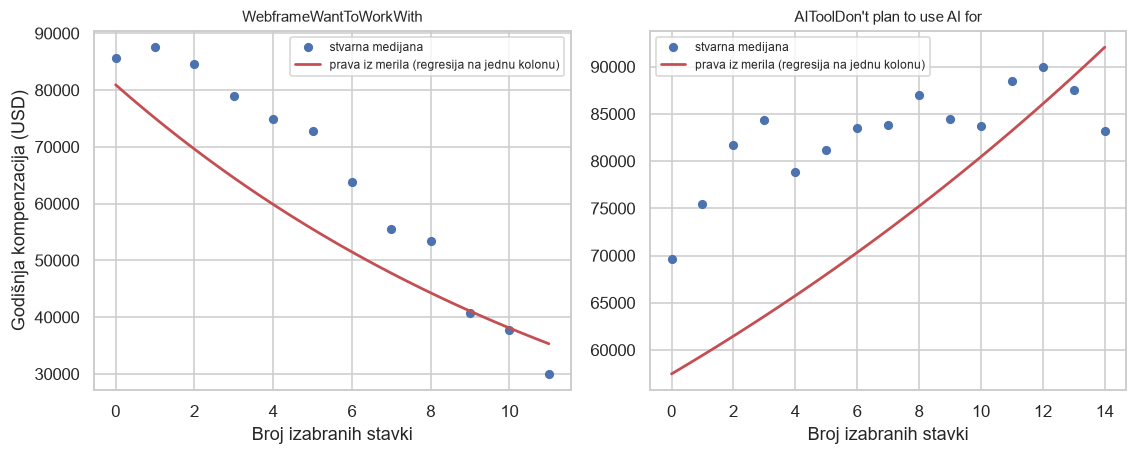

promenljiva                        opseg     prava  slobodno  medijana plate
WebframeWantToWorkWith             0-11     0.0243    0.0309    30,000 ->   87,550 USD
AIToolDon't plan to use AI for     0-14     0.0166    0.0208    69,609 ->   90,000 USD
WebframeAdmired                    0-8      0.0114    0.0184    51,071 ->   84,199 USD
DatabaseWantToWorkWith             0-10     0.0094    0.0104    48,554 ->   86,895 USD


In [20]:
strongest = [c for c in measured.index if c.startswith(COUNT_PREFIX)][:2]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))
for ax, column in zip(axes, strongest):
    grouped = train.groupby(column)[TARGET_LOG].agg(["median", "size"])
    # A point standing on a handful of people would only add noise.
    grouped = grouped[grouped["size"] >= 30]
    ax.plot(grouped.index, 10 ** grouped["median"], marker="o", markersize=5,
            linewidth=0, color="#4C72B0", label="stvarna medijana")

    # The straight line the measure fits, brought back from logarithm to dollars.
    line = sm.OLS(train[TARGET_LOG].to_numpy(),
                  sm.add_constant(train[[column]].astype(float).to_numpy())).fit()
    grid = np.linspace(grouped.index.min(), grouped.index.max(), 60)
    ax.plot(grid, 10 ** (line.params[0] + line.params[1] * grid),
            color="#C44E52", linewidth=1.8,
            label="prava iz merila (regresija na jednu kolonu)")

    ax.set_title(column.replace(COUNT_PREFIX, "")[:30], fontsize=10)
    ax.set_xlabel("Broj izabranih stavki")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Godišnja kompenzacija (USD)")
plt.tight_layout()
plt.show()

print(f"{'promenljiva':<32} {'opseg':>7}  {'prava':>8} {'slobodno':>9}  medijana plate")
for column in [c for c in measured.index if c.startswith(COUNT_PREFIX)][:4]:
    grouped = train.groupby(column)[TARGET].agg(["median", "size"])
    grouped = grouped[grouped["size"] >= 30]
    # Adjusted, so the free version is charged for the columns it uses.
    straight = signal(train[column])["R2_prilag"]
    free = signal(train[column].astype(int).astype(str))["R2_prilag"]
    print(f"{column.replace(COUNT_PREFIX, '')[:31]:<32} "
          f"{int(grouped.index.min()):>3}-{int(grouped.index.max()):<3}  "
          f"{straight:>8.4f} {free:>9.4f}  "
          f"{grouped['median'].min():>8,.0f} -> {grouped['median'].max():>8,.0f} USD")

**Zapažanje:** Kod `WebframeWantToWorkWith` medijana plate ide od **30.000 do 87.550 dolara**, dakle
gotovo trostruko, dok se broj izabranih stavki kreće od 0 do 11. Kod `AITool` je razlika mnogo manja, od
69.609 do 90.000.

Brojevi pored grafika mere i nešto što se sa slike samo naslućuje. Ako broj stavki uđe u regresiju kao
**prava**, `WebframeWantToWorkWith` dobija prilagođeni R² od **0,0243**; ako se svakom broju dozvoli
sopstveni nivo, dakle ako se dopusti bilo kakav oblik, dobija **0,0309**. Kod `WebframeAdmired` je razlika
još veća, 0,0114 naspram 0,0184.

**Tumačenje:** Veza postoji, ali **nije prava linija**. Slobodni oblik dobija osetno više i pošto je
poređenje na prilagođenom R², to nije posledica većeg broja kolona nego stvarne zakrivljenosti.

Za nas to znači dve stvari. Prva: naše merilo ove promenljive **potcenjuje**, jer meri koliko ih dobro
opisuje prava. Vrednosti iz 4.2 su zato donja granica, a ne tačna mera. Druga: u fazi modelovanja ovim
promenljivima treba pristupiti drugačije nego kao običnom broju — polinomskim članom ili grupisanjem u
kategorije, oba postupka sa predavanja. Ovde to ne radimo, jer bi značilo da za svaku od 36 promenljivih
biramo oblik prema tome kako ispadne.

Jedan pojam koji se odavde nadalje stalno koristi, pa da ga definišemo pre prve upotrebe:

> **Prirast** je koliko se **prilagođeni R² poveća** kada se promenljiva doda modelu koji već sadrži
> ostale — dakle razlika dva prilagođena R², jednom sa tom promenljivom i jednom bez nje. Za razliku
> od samostalnog merenja, prirast pokazuje šta promenljiva donosi **pored** onoga što ostale već daju.

### 4.3 Hipoteza 6 — nose li brojevi nešto što zemlja i staž već ne nose

Do sada smo merili šta promenljiva nosi **sama**. To nije dovoljno za odluku, i razlog je konkretan:
programer u Sjedinjenim Državama verovatno koristi više alata **i** zarađuje više od programera u
Pakistanu, ali ne zato što alati donose platu, nego zato što oboje prati zemlju. Ako je tako, brojačke
promenljive bi merile zemlju zaobilaznim putem, a zemlju već imamo.

Zato ih merimo i **pored** onoga što je najjače: zemlje i staža. Poređenje radimo F-testom, jer je manji
model sadržan u većem — isti test koji smo na predavanjima učili za poređenje modela.

**Prvo moramo da znamo šta je ovde „mnogo".** Granicu od 0,0286 iz odeljka 2.5 ovde **ne smemo** koristiti,
iako bi bilo primamljivo. Ona je izmerena kao prilagođeni R² koji `RemoteWork` dobija **sam**, a sada
merimo nešto drugo — koliko se model popravi kada se promenljiva **doda na već postojeći**. To su dve
različite veličine i ne porede se: obeležje može samo za sebe objašnjavati dosta, a pored zemlje ne dodati
skoro ništa, jer je zemlja to već objasnila.

Zato skalu kalibrišemo isto kao u 2.2 — merenjem onoga za šta znamo da vredi. Za svako anketno obeležje
gledamo koliko **dodaje** na istu osnovu, pa tek onda postavljamo kriterijum.

In [21]:
# The two strongest survey features from section 2, used as the model every
# new variable has to improve on.
BASE = ["Country", "WorkExp"]
base_model, _ = fit_together(BASE)
print(f"osnova ({' + '.join(BASE)}): R2={base_model.rsquared:.4f}   "
      f"prilagođeni={base_model.rsquared_adj:.4f}")
print()
print("koliko svako anketno obeležje DODAJE na tu osnovu:")
added = {}
for name in [c for c in REFERENCE if c not in BASE]:
    model, _ = fit_together(BASE + [name])
    added[name] = model.rsquared_adj - base_model.rsquared_adj
    print(f"  {name:<12} {added[name]:+.4f}"
          f"   (samo za sebe: {reference_table.loc[name, 'R2_prilag']:.4f})")

typical_gain = float(np.median(list(added.values())))
print()
print(f"tipičan prirast anketnog obeležja (medijana): {typical_gain:+.4f}")

osnova (Country + WorkExp): R2=0.5850   prilagođeni=0.5809



koliko svako anketno obeležje DODAJE na tu osnovu:
  DevType      +0.0131   (samo za sebe: 0.0312)


  OrgSize      +0.0140   (samo za sebe: 0.0442)
  EdLevel      +0.0048   (samo za sebe: 0.0068)


  Age          +0.0299   (samo za sebe: 0.1564)
  RemoteWork   +0.0097   (samo za sebe: 0.0286)


  Employment   +0.0008   (samo za sebe: 0.0003)
  YearsCode    +0.0018   (samo za sebe: 0.1481)


  JobSat       +0.0025   (samo za sebe: 0.0066)

tipičan prirast anketnog obeležja (medijana): +0.0072


**Zapažanje:** Prirast je **mnogo manji** od samostalne vrednosti, kod svakog obeležja. `RemoteWork` sam
za sebe dobija prilagođeni R² od 0,0286, a **pored zemlje i staža dodaje svega +0,0097**. `OrgSize` sa
0,0442 dodaje +0,0140. Jedino `Age` dodaje više od svoje granice iz 2.5.

**Tumačenje:** Ovo potvrđuje da granica iz 2.5 ovde ne bi bila samo stroga nego **pogrešna** — merila bi
jedno merilom drugog. Razlog je što zemlja objašnjava toliko da veći deo onoga što obeležja nose sama
bude već pokriven. `RemoteWork` sam za sebe hvata i to što se u bogatijim zemljama češće radi na daljinu;
pored zemlje mu od toga ne ostaje ništa.

Tipičan prirast anketnog obeležja na ovu osnovu je **+0,0072**, i to je skala na kojoj se meri i naš
dodatak. Kriterijum zato postavljamo ovako:

> **Hipoteza:** Broj izabranih stavki nosi informaciju o plati koju zemlja i radni staž ne nose.
>
> **Kriterijum:** Hipoteza je potvrđena ako dodavanje brojačkih promenljivih modelu koji već sadrži
> `Country` i `WorkExp` daje **značajno poboljšanje na pragu 0,05** po F-testu, **i** ako je prirast
> prilagođenog R² bar toliki koliki dodaje tipično anketno obeležje na istu osnovu. Značajnost sama nije
> dovoljna, jer pri 14.608 redova i beznačajno poboljšanje ispada značajno.

In [22]:
count_columns = [c for c in new_features.columns if c.startswith(COUNT_PREFIX)]
kept_columns = [c for c in new_features.columns if c.startswith(KEPT_PREFIX)]

for label, names in [("zemlja i staž", BASE),
                     ("+ svi brojevi", BASE + count_columns),
                     ("+ brojevi i odnosi", BASE + count_columns + kept_columns)]:
    model, columns = fit_together(names)
    print(f"{label:<22} R2={model.rsquared:.4f}   prilagođeni={model.rsquared_adj:.4f}   "
          f"kolona={columns:>3}")

with_counts, _ = fit_together(BASE + count_columns)
f_stat, p_value, df_diff = with_counts.compare_f_test(base_model)
gain = with_counts.rsquared_adj - base_model.rsquared_adj

print()
print(f"F-test za dodatih {int(df_diff)} kolona:  F = {f_stat:.2f}   p = {format_p(p_value)}")
print(f"prirast prilagođenog R²:        {gain:+.4f}")
print(f"tipičan prirast anketnog obeležja: {typical_gain:+.4f}")
print()
print(f"značajno na pragu 0,05:         {bool(p_value < 0.05)}")
print(f"prirast bar kao tipično obeležje: {bool(gain >= typical_gain)}")
with_ratios, _ = fit_together(BASE + count_columns + kept_columns)
print(f"odnosi zadržanog dodaju povrh brojeva:            "
      f"{with_ratios.rsquared_adj - with_counts.rsquared_adj:+.4f}")
print()
better = [name for name, value in added.items() if value < gain]
print(f"anketnih obeležja koja dodaju manje od brojeva: {len(better)} od {len(added)}  {sorted(better)}")

zemlja i staž          R2=0.5850   prilagođeni=0.5809   kolona=142


+ svi brojevi          R2=0.6027   prilagođeni=0.5978   kolona=178


+ brojevi i odnosi     R2=0.6043   prilagođeni=0.5992   kolona=185



F-test za dodatih 36 kolona:  F = 17.92   p = 5.7e-110
prirast prilagođenog R²:        +0.0169
tipičan prirast anketnog obeležja: +0.0072

značajno na pragu 0,05:         True
prirast bar kao tipično obeležje: True


odnosi zadržanog dodaju povrh brojeva:            +0.0014

anketnih obeležja koja dodaju manje od brojeva: 7 od 8  ['DevType', 'EdLevel', 'Employment', 'JobSat', 'OrgSize', 'RemoteWork', 'YearsCode']


**Zapažanje:** Dodavanje 36 brojačkih promenljivih na model sa zemljom i stažom podiže prilagođeni R² sa
**0,5809 na 0,5978**, dakle za **+0,0169**. F-test daje **F = 17,92** uz p reda 10⁻¹¹⁰. Tipičan prirast
anketnog obeležja na istu osnovu je **+0,0072**, pa su oba dela kriterijuma ispunjena.

Poslednji red ispisa to stavlja u odnos: brojačke promenljive zajedno dodaju **više nego sedam od osam**
anketnih obeležja — više od veličine firme, tipa posla, načina rada, obrazovanja, zadovoljstva poslom,
oblika zaposlenja i godina programiranja. Jedino uzrast dodaje više.

Odnosi zadržanog, dodati povrh svega, podižu prilagođeni R² sa 0,5978 na **0,5992**, dakle za još 0,0014.

**Verdikt: hipoteza je potvrđena.** Broj izabranih stavki nosi informaciju koju zemlja i staž ne nose.

**Tumačenje:** Rezultat je zanimljiv baš zato što se ne slaže sa onim iz 4.2. Tamo nijedna promenljiva
nije prešla granicu od 0,0286, a ovde ih 36 zajedno dodaje više nego skoro svako anketno pitanje.
Objašnjenje je isto ono iz 2.4 — promenljive se dopunjuju. Broj web-frejmvorka koje neko želi i broj baza
koje koristi ne govore o istoj stvari, pa se ono što svaka od njih nosi ne poništava nego sabira.

Ovo je usput i najuverljiviji primer zašto samostalno merenje služi **za odbacivanje, a ne za rangiranje**. Da smo posle
4.2 zaključili „nijedna ne prelazi granicu, pa nijednu ne uzimamo", izbacili bismo skup promenljivih koji
modelu daje više od šest anketnih pitanja zajedno.

**Odluka:** Svih 36 brojačkih promenljivih i 17 indikatora ulazi dalje. Odnosi zadržanog se zadržavaju
uslovno — dodaju malo (0,0014), ali koštaju svega sedam kolona i mere nešto što nijedna druga promenljiva
ne meri, pa ostaju uz zabelešku da su slabi. Konačnu reč o svima njima ima formalna selekcija u fazi
modelovanja.

### 4.4 Šta od svega zadržavamo

Do sada smo pravili i merili. Sada popisujemo šta ostaje, jer se to iz prethodnih odeljaka ne vidi samo
po sebi.

Podelu poslova držimo doslednom kroz ceo notebook: **ovde izbacujemo samo ono za šta smo izmerili da je
šum**, a konačan izbor promenljivih radi se u modelovanju, formalnom selekcijom sa predavanja. Razlog je
onaj iz 2.4 — samostalno merenje potcenjuje promenljive koje rade zajedno, pa nije merilo za rangiranje,
nego samo za odbacivanje najgoreg.

Ostaju dve odluke, i obe rešavamo merenjem, ne rečima.

**Prva: šta sa promenljivama koje su po pravilu iz 2.5 šum?** Pravilo kaže da se takve ne prave. Ali
pošto smo u 4.3 videli da zajedno rade više nego pojedinačno, ne izbacujemo ih dok ne izmerimo koliko
njihovo izbacivanje zaista košta.

**Druga: da li da ispravimo zakrivljenost koju smo videli u Grafiku 4?** Sa predavanja znamo polinomsku
regresiju — dodavanje kvadrata promenljive kao još jedne kolone. To bismo primenili **na sve brojačke
promenljive odjednom**, po istom pravilu, da ne bismo oblik birali promenljivoj po promenljivoj prema
tome kako ispadne. Da li se isplati, meri se istim kriterijumom kao u 4.3: prirast se poredi sa onim što
tipično anketno obeležje dodaje na istu osnovu.

In [23]:
noise_features = list(band[band == "šum"].index)
kept_new_columns = [c for c in new_features.columns if c not in noise_features]

print(f"po pravilu iz 2.5 kao šum je označeno {len(noise_features)} od {len(new_features.columns)}:")
for prefix in (COUNT_PREFIX, ANSWERED_PREFIX, KEPT_PREFIX):
    print(f"  {prefix:<14} {sum(c.startswith(prefix) for c in noise_features):>2}")
print()

with_all, _ = fit_together(BASE + list(new_features.columns))
with_kept, _ = fit_together(BASE + kept_new_columns)
print(f"model sa svih {len(new_features.columns)} novih:   prilagođeni={with_all.rsquared_adj:.4f}")
print(f"model bez {len(noise_features)} označenih kao šum: prilagođeni={with_kept.rsquared_adj:.4f}")
print(f"cena izbacivanja:                 {with_kept.rsquared_adj - with_all.rsquared_adj:+.5f}")
print()

# The same polynomial term for every count column, so the shape is not chosen
# variable by variable according to how it turns out.
squares = pd.DataFrame({c + "_sq": train[c].astype(float) ** 2 for c in count_columns},
                       index=train.index)
linear_only, _ = fit_together(BASE + count_columns)
design = pd.concat([pd.get_dummies(train["Country"].astype(str), prefix="Country",
                                   drop_first=True, dtype=float),
                    train[["WorkExp"] + count_columns].astype(float), squares], axis=1)
with_squares = sm.OLS(train[TARGET_LOG].to_numpy(),
                      sm.add_constant(design).to_numpy()).fit()
f_stat, p_value, df_diff = with_squares.compare_f_test(linear_only)

print(f"+ kvadratni član za svaku od {len(count_columns)}:  prilagođeni={with_squares.rsquared_adj:.4f}")
print(f"prirast preko linearnih:          {with_squares.rsquared_adj - linear_only.rsquared_adj:+.4f}")
print(f"F-test: F = {f_stat:.2f}   p = {format_p(p_value)}   (dodato {int(df_diff)} kolona)")
print(f"tipičan prirast anketnog obeležja: {typical_gain:+.4f}")
print(f"prirast bar kao tipično obeležje:  "
      f"{bool(with_squares.rsquared_adj - linear_only.rsquared_adj >= typical_gain)}")
print()

train = train.drop(columns=noise_features)
# The name lists follow the drop, so later sections work with what remains.
count_columns = [c for c in count_columns if c not in noise_features]
kept_columns = [c for c in kept_columns if c not in noise_features]
print(f"izbačeno kolona: {len(noise_features)}")
for prefix in (COUNT_PREFIX, ANSWERED_PREFIX, KEPT_PREFIX):
    made = sum(c.startswith(prefix) for c in new_features.columns)
    kept = sum(c.startswith(prefix) for c in kept_new_columns)
    print(f"  {prefix:<14} napravljeno {made:>2}, zadržano {kept:>2}")
print(f"kolona u skupu na kraju sekcije: {train.shape[1]}   "
      f"({train.shape[1] - 2} prediktora, ciljna promenljiva i njen logaritam)")

po pravilu iz 2.5 kao šum je označeno 12 od 60:
  Count_          9
  NotAnswered_    3
  KeptShare_      0



model sa svih 60 novih:   prilagođeni=0.6082
model bez 12 označenih kao šum: prilagođeni=0.6072
cena izbacivanja:                 -0.00104



+ kvadratni član za svaku od 36:  prilagođeni=0.6004
prirast preko linearnih:          +0.0026
F-test: F = 3.62   p = 1.5e-12   (dodato 36 kolona)
tipičan prirast anketnog obeležja: +0.0072
prirast bar kao tipično obeležje:  False

izbačeno kolona: 12
  Count_         napravljeno 36, zadržano 27
  NotAnswered_   napravljeno 17, zadržano 14
  KeptShare_     napravljeno  7, zadržano  7
kolona u skupu na kraju sekcije: 178   (176 prediktora, ciljna promenljiva i njen logaritam)


**Zapažanje:** Po pravilu iz 2.5 kao šum je označeno **12 od 60** novih kolona — devet brojačkih i tri
indikatora, dok nijedan odnos zadržanog nije pao ispod donje granice.

Njihovo izbacivanje košta **0,00104** prilagođenog R², dakle model pada sa 0,6082 na 0,6072.

Kvadratni članovi, dodati za svih 36 brojačkih promenljivih odjednom, podižu prilagođeni R² sa 0,5978 na
**0,6004**, dakle za **+0,0026**. F-test je značajan (p reda 10⁻¹²), ali je prirast **manji od 0,0072**,
koliko tipično dodaje anketno obeležje.

**Tumačenje i odluke.**

**Dvanaest kolona izbacujemo.** Cena je hiljaditi deo prilagođenog R², a dobija se dvanaest kolona manje
u modelu koji ih ionako ima previše. Ovo je jedini korak u sekciji u kome nešto zaista uklanjamo, i
radimo ga po pravilu koje je postavljeno pre nego što smo išta izmerili.

**Kvadratne članove ne uzimamo.** Ovde je vredelo izmeriti umesto pretpostaviti: zakrivljenost koju smo
videli u Grafiku 4 je stvarna i F-test je potvrđuje, ali je ono što se time dobija manje od onoga što
donese jedno prosečno anketno pitanje — a plaća se sa 36 dodatnih kolona. Po istom kriterijumu po kom
smo u 4.3 prihvatili brojeve, ovde ga polinom ne prolazi.

To ne znači da je zakrivljenost nevažna, nego da je jednostavno kvadriranje pogrešan alat za nju. U fazi
modelovanja postoje bolji: Ridge i Lasso, koji cenu dodatnih kolona rešavaju regularizacijom umesto da je
plaćaju u prilagođenom R². Tamo se ovo može ponovo probati, sa merilom koje je za to napravljeno.

Ostaje **48 novih kolona**, pa skup ima 178 ukupno — 176 prediktora, ciljna promenljiva i njen logaritam.

### Šta sekcija ostavlja sledećoj

Skup je narastao sa 130 na **178 kolona**: napravljeno je 60 novih, a 12 izbačeno kao šum.

| prefiks | napravljeno | zadržano |
| --- | --- | --- |
| `Count_` | 36 | 27 |
| `NotAnswered_` | 17 | 14 |
| `KeptShare_` | 7 | 7 |
| **ukupno** | **60** | **48** |

Četiri nalaza se prenose dalje:

- **pojedinačno su slabe, zajedno nisu.** Nijedna ne prelazi granicu iz 2.5 sama, a zajedno dodaju
  +0,0169 na model sa zemljom i stažom — više od sedam od osam anketnih obeležja;
- **veza nije prava linija**, pa naše merilo ove promenljive potcenjuje. Kvadratni član to ne rešava
  dovoljno da bi se isplatio, ali Ridge i Lasso u modelovanju mogu;
- **indikatori neodgovaranja su jači od očekivanog**, jači i od većine brojeva, što potvrđuje nalaz iz
  prethodnog notebook-a da preskakanje pitanja nije slučajno;
- **odnos zadržanog je slab ali čist** — nijedan nije pao u šum, i meri nešto što nijedna druga
  promenljiva ne meri.

Ono što ovde nije obuhvaćeno jeste **koje** su stavke izabrane. Dvoje ljudi sa po tri jezika ovde imaju
istu vrednost, bez obzira na to da li su to Python i SQL ili Cobol i Perl. Time se bavi sledeća sekcija.

## 5. Pojedinačne stavke kao kolone

Prethodna sekcija je merila **koliko** je stavki izabrano. Ovde merimo **koje**. Dvoje ljudi sa po tri
jezika u sekciji 4 imaju istu vrednost, bez obzira na to da li su to Python i SQL ili Cobol i Perl — a ta
razlika bi mogla da bude ono što plata zapravo prati.

Podsetnik odakle krećemo, jer je od toga prošlo dosta: skup ima **178 kolona**, a među njima je **36
multi-select kolona** — onih u kojima je više odgovora spojeno tačka-zarezom. To su iste one kolone iz
kojih je sekcija 4 izvela brojeve; njihov sadržaj je i dalje netaknut string.

Postupak je jednostavan: za svaku ponuđenu stavku pravimo kolonu koja je **1 ako ju je ispitanik izabrao,
inače 0**. To je isto dummy enkodiranje koje smo učili na predavanjima, samo primenjeno na odgovor koji
dozvoljava više izbora odjednom.

### 5.1 Od čega pravimo kolone po stavci

Tri odluke pre nego što počnemo.

**Iz kojih kolona.** Kolone `Admired` izostavljamo, jer je Hipoteza 5 pokazala da su presek druge dve —
kolona „divi se Pythonu" bila bi tačno određena kolonama „koristi Python" i „želi Python", pa bi u model
unela kolinearnost umesto informacije. Od 36 multi-select kolona ostaje **29**.

**Šta sa onima koji nisu odgovorili.** Kolona kaže da li je ispitanik izabrao tu stavku; ko na pitanje
nije odgovorio, nije je izabrao, pa upisujemo 0. Podatak da pitanje nije odgovoreno nije izgubljen — nose
ga indikatori `NotAnswered_` iz sekcije 4.

**Kako se kolone zovu.** Ime je `Chose_<izvorna kolona>__<stavka>`, na engleskom, sa razmakom i
interpunkcijom svedenim na donju crtu. Simbole koji bi se izgubili prevodimo u reč, jer bi inače `C`,
`C#` i `C++` dali isto ime; da se to zaista ne dešava, kod proverava i ispisuje.

Jedna stvar oko brojanja, da ne bi bilo zabune: nova kolona se pravi za **svaki par kolone i stavke**, ne
za svaku stavku. `Python` se javlja i u `LanguageHaveWorkedWith` i u `LanguageWantToWorkWith`, i to su dve
različite činjenice — koristi ga, odnosno želi da ga koristi — pa daje **dve** kolone.

In [24]:
# Symbols that would vanish in a plain clean-up and take a distinction with them:
# without this, C, C# and C++ all become the same column name.
SYMBOLS = {"#": "sharp", "+": "plus", "&": "and"}
ITEM_PREFIX = "Chose_"


def clean_name(text, limit=34):
    """A survey label turned into something usable as a column name."""
    for symbol, word in SYMBOLS.items():
        text = text.replace(symbol, word)
    return re.sub(r"_+", "_", re.sub(r"[^A-Za-z0-9]+", "_", text)).strip("_")[:limit].strip("_")


# Admired columns are the intersection of the other two (hypothesis 5), so an
# indicator built from them would be determined by indicators we already have.
item_sources = [c for c in multi_select if not c.endswith("Admired")]

item_columns = {}
for column in item_sources:
    chosen = train[column].fillna("").astype(str).map(lambda value: set(value.split(";")) - {""})
    for item in sorted(set().union(*chosen)):
        name = f"{ITEM_PREFIX}{clean_name(column, 40)}__{clean_name(item)}"
        item_columns[name] = chosen.map(lambda picked, i=item: float(i in picked))

items = pd.DataFrame(item_columns, index=train.index)

print(f"izvornih kolona: {len(item_sources)}   (od {len(multi_select)}, bez sedam `Admired`)")
print(f"kandidat-kolona po stavci: {items.shape[1]}")
print(f"sva imena jedinstvena: {items.shape[1] == len(set(items.columns))}")
print(f"vrednosti koje se javljaju: {sorted(pd.unique(items.to_numpy().ravel()))}")
print()
print("odakle taj broj — po jedna kolona za svaki par (izvorna kolona, stavka):")
for column in sorted(item_sources, key=lambda c: -len(vocabulary[c]))[:4]:
    print(f"  {column:<34} {len(vocabulary[column]):>3} stavki")
print(f"  ... zbir preko svih {len(item_sources)} kolona: {sum(len(vocabulary[c]) for c in item_sources)}")
print(f"različitih tekstova stavki, bez obzira na kolonu: "
      f"{len(set().union(*(vocabulary[c] for c in item_sources)))}")
print()
print(f"redova po jednoj kandidat-koloni: {len(train) / items.shape[1]:.0f}")
print()
print("primer, jezici jednog ispitanika:")
example = [c for c in items.columns if c.startswith("Chose_LanguageHaveWorkedWith")][:6]
print(items.loc[[4], example].T.to_string(header=["ispitanik 4"]))

izvornih kolona: 29   (od 36, bez sedam `Admired`)
kandidat-kolona po stavci: 609
sva imena jedinstvena: True
vrednosti koje se javljaju: [np.float64(0.0), np.float64(1.0)]

odakle taj broj — po jedna kolona za svaki par (izvorna kolona, stavka):
  LanguageHaveWorkedWith              42 stavki
  LanguageWantToWorkWith              42 stavki
  PlatformHaveWorkedWith              42 stavki
  PlatformWantToWorkWith              42 stavki
  ... zbir preko svih 29 kolona: 609
različitih tekstova stavki, bez obzira na kolonu: 323

redova po jednoj kandidat-koloni: 24

primer, jezici jednog ispitanika:
                                                    ispitanik 4
Chose_LanguageHaveWorkedWith__Ada                           0.0
Chose_LanguageHaveWorkedWith__Assembly                      0.0
Chose_LanguageHaveWorkedWith__Bash_Shell_all_shells         1.0
Chose_LanguageHaveWorkedWith__C                             0.0
Chose_LanguageHaveWorkedWith__Csharp                        0.0
Chose_Languag

**Zapažanje:** Iz 29 izvornih kolona nastalo je **609 kandidat-kolona**, sve sa jedinstvenim imenom i sve
sa samo dve vrednosti, 0 i 1.

Drugi deo ispisa pokazuje odakle taj broj. Najveće doprinose daju `LanguageHaveWorkedWith` i
`LanguageWantToWorkWith`, sa po 42 stavke, pa `PlatformHaveWorkedWith` i `PlatformWantToWorkWith`, takođe
sa po 42. Zbir preko svih 29 kolona je 609 — a **različitih tekstova stavki, bez obzira na kolonu, ima
svega 323**. Razlika je u tome što se ista stavka javlja u više kolona: `Python` daje jednu kolonu za
„koristi" i drugu za „želi".

Primer pokazuje kako to izgleda kod jednog ispitanika: od prikazanih šest jezika ima jedinicu samo kod
`Bash_Shell_all_shells`, a nule svuda drugde.

**Tumačenje:** 609 kolona na 14.608 redova je odnos koji zabrinjava. Poslednji red ispisa ga daje u
brojkama: **na jednu kandidat-kolonu dolazi 24 reda**. Nije nemoguće raditi sa tim, ali je daleko od
udobnog — što je model bliži tome da ima koliko kolona koliko i redova, to lakše nauči slučajne razlike
umesto stvarnih, a to je kraj bias-variance krive na kom varijansa preuzima sve. Uz to ovih 609 dolazi
povrh 178 kolona koje već imamo.

Zato ih ne uzimamo sve. Ostatak sekcije je o tome kako se odlučuje koje ostaju, i taj postupak je važniji
od samog rezultata: svaki prag koji ovde postavimo mora da bude izmeren, jer ih ima previše da bi se o
svakoj koloni odlučivalo pojedinačno.

### 5.2 Prvi pokušaj: prag po zastupljenosti

609 kolona na 14.608 redova je mnogo, pa je prva pomisao da se odbace stavke koje bira malo ljudi.
Zastupljenost stavke je udeo ispitanika koji su je izabrali — `Python` u koloni „koristi" ima
zastupljenost od koliko procenata ispitanika ga je označilo. Kolona koja je jedinica kod dvadesetak ljudi
deluje kao nešto što ne može ništa da nauči.

Takav prag, međutim, ne smemo da izaberemo nego moramo da ga **izvedemo**. Tražimo isto što i u
prethodnom notebook-u kod nedostajućih vrednosti: mesto gde poređani niz sam pravi prekid, pa granicu
postavljamo tu.

In [25]:
item_share = (items.mean() * 100).sort_values()
jumps = item_share.diff()

print("koliki udeo ispitanika je izabrao stavku, i koliko je takvih stavki:")
print(f"  {'udeo ispitanika':>18}   {'kolona':>6}")
bands = [(0, 0.5), (0.5, 1), (1, 2), (2, 5), (5, 10), (10, 101)]
for low, high in bands:
    inside = (item_share >= low) & (item_share < high)
    print(f"  {low:>7.1f} - {min(high, 100):>5.1f}%   {int(inside.sum()):>6}")
print()
print("najveći skokovi u poređanom nizu:")
for name in jumps.nlargest(4).index:
    place = list(item_share.index).index(name)
    print(f"  sa {item_share[name] - jumps[name]:>5.2f}% na {item_share[name]:>5.2f}%   "
          f"(skok {jumps[name]:.2f} pp, na {place}. mestu od {len(item_share)})")
print()
print("koliko bi kolona ostalo kad bismo prag postavili na razne vrednosti:")
for limit in [0.5, 1, 2, 5, 10]:
    print(f"  odbaci stavke ispod {limit:>4}% : ostaje {int((item_share >= limit).sum()):>4} od {len(item_share)}")

koliki udeo ispitanika je izabrao stavku, i koliko je takvih stavki:
     udeo ispitanika   kolona
      0.0 -   0.5%       11
      0.5 -   1.0%       37
      1.0 -   2.0%       52
      2.0 -   5.0%      134
      5.0 -  10.0%      112
     10.0 - 100.0%      263

najveći skokovi u poređanom nizu:
  sa 72.62% na 77.23%   (skok 4.61 pp, na 608. mestu od 609)
  sa 68.46% na 72.62%   (skok 4.16 pp, na 607. mestu od 609)
  sa 55.80% na 59.12%   (skok 3.32 pp, na 598. mestu od 609)
  sa 65.38% na 68.46%   (skok 3.08 pp, na 606. mestu od 609)

koliko bi kolona ostalo kad bismo prag postavili na razne vrednosti:
  odbaci stavke ispod  0.5% : ostaje  598 od 609
  odbaci stavke ispod    1% : ostaje  561 od 609
  odbaci stavke ispod    2% : ostaje  509 od 609
  odbaci stavke ispod    5% : ostaje  375 od 609
  odbaci stavke ispod   10% : ostaje  263 od 609


**Zapažanje:** Raspodela je neravnomerna — **11 stavki bira manje od pola procenta** ispitanika, a 263
njih bira preko deset posto. Ali u poređanom nizu **prekida nema**: najveći skokovi su od tri do četiri i
po procentna poena, i svi su na samom **vrhu** niza, među stavkama koje bira preko 55% ispitanika.

Tamo gde bi prag imao smisla — među retkim stavkama, na dnu niza — skokova nema.

**Tumačenje:** Ovo se razlikuje od onoga što smo videli u prethodnom notebook-u kod nedostajućih
vrednosti, gde je niz imao jasan prelom pa se granica sama nametnula. Ovde niz raste glatko, pa **svaki
prag koji bismo postavili bio bi naš izbor, a ne nalaz iz podataka** — a razlika između praga od 2% i 5%
nije mala: 509 kolona naspram 375.

Pošto podaci granicu ne nude, ne smemo je izmisliti. Ostaje da proverimo da li nam je uopšte potrebna.

### Grafik 5 — poređani niz zastupljenosti

**Motivacija:** Brojevi kažu koliko je stavki u kom opsegu, ali ne i da li niz negde pravi prelom. U
prethodnom notebook-u je isti ovakav niz, kod nedostajućih vrednosti, imao jasan skok od 9,3 procentna
poena i granica se sama nametnula. Crtamo isti prikaz ovde da vidimo da li se to ponavlja.

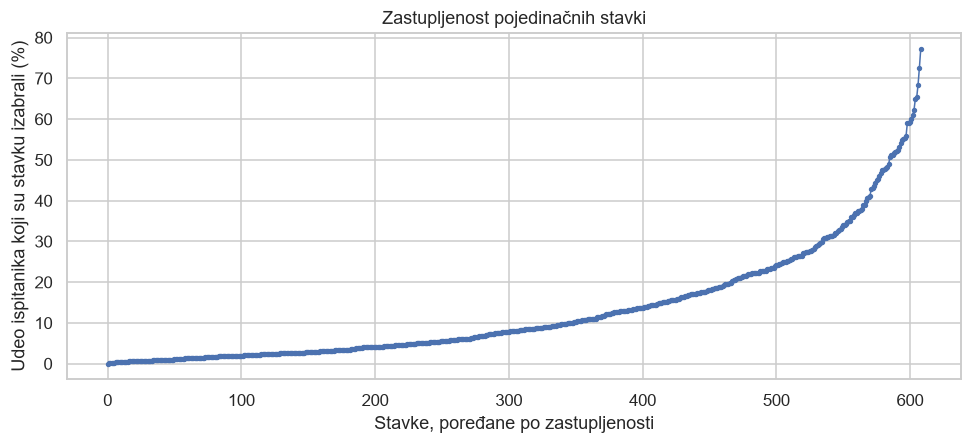

najveći skok u celom nizu: 4.61 procentna poena
i to na 608. mestu od 609, kod stavki koje bira 77% ispitanika


In [26]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(range(len(item_share)), item_share.values, marker="o", markersize=2.5,
        linewidth=1, color="#4C72B0")

ax.set_xlabel("Stavke, poređane po zastupljenosti")
ax.set_ylabel("Udeo ispitanika koji su stavku izabrali (%)")
ax.set_title("Zastupljenost pojedinačnih stavki")
plt.tight_layout()
plt.show()

print(f"najveći skok u celom nizu: {jumps.max():.2f} procentna poena")
print(f"i to na {list(item_share.index).index(jumps.idxmax())}. mestu od {len(item_share)}, "
      f"kod stavki koje bira {item_share[jumps.idxmax()]:.0f}% ispitanika")

**Zapažanje:** Kriva raste glatko, bez preloma. Najveći skok u celom nizu iznosi **4,61 procentna poena**
i nalazi se pri samom vrhu, kod stavki koje bira preko sedamdeset posto ispitanika.

**Tumačenje:** Grafik potvrđuje ono što je tabela nagovestila i zatvara taj put. Kad bismo prag postavili
na mestu najvećeg skoka, izbacili bismo **sve osim najčešćih stavki**, što je suprotno od onoga što smo
hteli. Prekid postoji, ali na pogrešnom kraju skale.

Zaključak je da granica po zastupljenosti u ovim podacima nema uporište. To ne znači da praga ne treba
da bude — znači da ga treba tražiti negde drugde.

### 5.3 Da li je retkost uopšte problem

Kad prekida nema, pravilo ne smemo da izmislimo. Ali vredi se vratiti korak nazad i pitati **zašto** smo
prag po zastupljenosti uopšte hteli.

Strah je bio da retka kolona lakše ispadne značajna slučajno — da se kod dvadeset jedinica lakše nađe
obrazac kog nema, nego kod hiljadu. Da li je to tako, ne treba pretpostavljati nego izmeriti, i to isto
kao u odeljku 2.1.

Postupak: za osam nivoa zastupljenosti, od četvrtine procenta do polovine uzorka, pravimo po **300
slučajnih kolona** sa tim udelom jedinica. Kolone su čista slučajnost i sa platom nemaju veze, pa je sve
što dobiju posledica slučaja. Za svaki nivo gledamo **dokle je najdalja od tih 300 stigla**. Ako slučajne
kolone sa malo jedinica stižu dalje od onih sa mnogo, retkost jeste problem i prag ima smisla.

In [27]:
from scipy import stats


def binary_signal(values):
    """Adjusted R² and F-test p for one binary column, without fitting a model.

    For a single predictor R² is the square of the correlation, which is the
    same number the regression would give but far cheaper over hundreds of
    columns.
    """
    n_rows = len(values)
    correlation = np.corrcoef(values, train[TARGET_LOG].to_numpy())[0, 1]
    r_squared = 0.0 if np.isnan(correlation) else correlation ** 2
    adjusted = 1 - (1 - r_squared) * (n_rows - 1) / (n_rows - 2)
    f_value = r_squared / (1 - r_squared) * (n_rows - 2) if r_squared < 1 else np.inf
    return adjusted, stats.f.sf(f_value, 1, n_rows - 2)


rng = np.random.default_rng(0)
n_rows = len(train)

print(f"{'udeo jedinica':>14} {'jedinica':>9} {'najveći adj R² od 300':>22}")
for share in [0.25, 0.5, 1, 2, 5, 10, 25, 50]:
    best = max(binary_signal((rng.random(n_rows) < share / 100).astype(float))[0]
               for _ in range(300))
    print(f"{share:>13.2f}% {int(round(n_rows * share / 100)):>9,} {best:>22.5f}")

 udeo jedinica  jedinica  najveći adj R² od 300
         0.25%        37                0.00057


         0.50%        73                0.00035
         1.00%       146                0.00056


         2.00%       292                0.00044
         5.00%       730                0.00053


        10.00%     1,461                0.00064
        25.00%     3,652                0.00047


        50.00%     7,304                0.00046


**Zapažanje:** Dokle slučajnost stiže **ne zavisi od zastupljenosti**. Slučajna kolona sa 37 jedinica
dostiže prilagođeni R² od 0,00057, a ona sa 7.304 jedinice 0,00046 — praktično isto. Kroz ceo raspon,
od četvrtine procenta do polovine uzorka, vrednosti se drže oko pet do šest desethiljaditih delova.

**Tumačenje:** Retkost, dakle, **ne daje koloni nezasluženu prednost**. Stavka koju bira dvadeset ljudi
nije ništa sklonija da slučajno ispadne značajna od stavke koju bira polovina uzorka.

To ruši razlog zbog kog smo prag po zastupljenosti uopšte razmatrali. Kolona sa malo jedinica jeste manje
pouzdana u smislu da se procena zasniva na manje ljudi, ali to merilo iz sekcije 2 već hvata: ako od tih
dvadeset ljudi ne izlazi nikakav obrazac, prilagođeni R² ostaje pri dnu i kolona pada.

Prag po zastupljenosti zato **ne uvodimo**. Ali to ne znači da nam prag uopšte ne treba, jer postoji drugi
problem koji do sada nije bio ozbiljan.

### 5.4 Prag koji zaista treba: 609 provera odjednom

Retkost, dakle, nije problem. Ali postoji drugi, koji smo do sada mogli da zanemarimo a sada ne možemo.

Do sada smo merili po nekoliko promenljivih odjednom. Sada ih merimo **609**. Prag značajnosti od 0,05
znači da svaka pojedinačna provera ima pet posto izgleda da prođe i kad veze nema — pa se pri šest stotina
provera i od čiste slučajnosti očekuje tridesetak prolaza. Ako uzmemo sve što prođe test, primili bismo i
njih, a ne bismo imali način da ih razlikujemo od pravih.

Ovo na predavanjima nismo radili, pa objašnjavamo šta radimo umesto toga. Ne menjamo test nego **podižemo
prag**, i to na nivo koji slučajnost pri ovom broju provera ne dostiže.

Postupak je sledeći. Napravimo **609 slučajnih kolona — tačno onoliko koliko imamo stvarnih kandidata — i
svakoj damo isti udeo jedinica kao odgovarajućoj stvarnoj koloni.** Time dobijamo skup koji je po obliku
istovetan našem, samo što u njemu nema nikakve veze sa platom. Propustimo ga kroz isto merilo i zabeležimo
**dokle je najdalja od tih 609 stigla** i koliko ih je prošlo test značajnosti. To ponovimo pet puta, sa
različitim slučajnim brojevima, da vidimo koliko je taj domet stabilan.

Prag je onda **najveći domet koji je slučajnost postigla u bilo kom od pet pokušaja**. Sve ispod toga je
nešto što bismo dobili i da podataka nema.

In [28]:
shares = items.mean().to_numpy()

# One full run of the whole screening on columns that hold nothing but noise,
# repeated so we can see how far chance reaches and how steady that reach is.
reaches, passed_test = [], []
for seed in range(1, 6):
    noise_rng = np.random.default_rng(seed)
    measured_noise = [binary_signal((noise_rng.random(n_rows) < share).astype(float))
                      for share in shares]
    reaches.append(max(a for a, _ in measured_noise))
    passed_test.append(sum(p < 0.05 for _, p in measured_noise))

print(f"{'pokušaj':>8} {'prošlo test p<0,05':>20} {'najveći adj R²':>16}")
for i, (count, reach) in enumerate(zip(passed_test, reaches), start=1):
    print(f"{i:>8} {count:>20} {reach:>16.5f}")
print()
print(f"očekivano po slučaju pri {len(shares)} provera i pragu 0,05: {0.05 * len(shares):.0f}")
print(f"dokle slučajnost stiže, u proseku:  {np.mean(reaches):.5f}")
print(f"najdalje u pet pokušaja:            {max(reaches):.5f}")

# The bar: the furthest chance got in any of the runs.
ITEM_LIMIT = float(max(reaches))
print()
print(f"prag za kolone po stavci: {ITEM_LIMIT:.5f}")

 pokušaj   prošlo test p<0,05   najveći adj R²
       1                   29          0.00086
       2                   29          0.00069
       3                   30          0.00078
       4                   23          0.00094
       5                   35          0.00080

očekivano po slučaju pri 609 provera i pragu 0,05: 30
dokle slučajnost stiže, u proseku:  0.00081
najdalje u pet pokušaja:            0.00094

prag za kolone po stavci: 0.00094


**Zapažanje:** U pet pokušaja je test značajnosti prošlo između **23 i 35 slučajnih kolona**, u proseku
oko trideset — tačno koliko se i očekuje pri 609 provera i pragu od 0,05. Nijedna od njih nije stigla
dalje od prilagođenog R² od **0,00094**, a prosek najdaljeg dometa je 0,00081.

**Tumačenje:** Brojevi potvrđuju ono čega smo se plašili. Da smo uzeli sve što prođe test značajnosti,
primili bismo i tridesetak kolona koje sa platom nemaju nikakve veze — a ne bismo znali koje su.

Rešenje je da prag ne bude na p-vrednosti nego na **domet slučajnosti**: uzimamo samo kolone koje su
otišle dalje nego što je u pet pokušaja stigla ijedna slučajna kolona, dakle preko **0,00094**. Domet je
stabilan — kroz pet pokušaja se kreće između 0,00069 i 0,00094 — pa uzimamo najveći od njih, da budemo na
sigurnoj strani.

Ovo nije postupak sa predavanja, pa vredi reći šta jeste a šta nije. Nije nova vrsta testa — i dalje
tražimo p < 0,05. Jeste dodatni uslov, izmeren na isti način kao donja granica u odeljku 2.1, samo što se ovde
ponavlja onoliko puta koliko imamo kolona. Cena je što ćemo odbaciti i neke stvarne veze koje su slabe;
dobitak je što ono što ostane nije tridesetak nasumičnih kolona.

### 5.5 Hipoteza 7 — govori li *koje* stavke više nego *koliko* ih je

Sada imamo prag i možemo da izmerimo stvarne stavke. Ali glavno pitanje sekcije nije koliko ih prolazi,
nego da li uopšte vrede — jer već imamo brojeve iz sekcije 4, koji o istim tim kolonama govore na drugi
način.

Moguće je da je sve što stavke nose zapravo sadržano u broju izabranih stavki. Ko koristi Rust verovatno
koristi i mnogo drugih tehnologija, pa bi kolona „koristi Rust" mogla da bude samo zaobilazan način da se
kaže „koristi mnogo toga" — a to već imamo, u jednoj koloni umesto u tri stotine.

> **Hipoteza:** Koje su stavke izabrane nosi informaciju o plati koju broj izabranih stavki ne nosi.
>
> **Kriterijum:** Hipoteza je potvrđena ako dodavanje kolona po stavci na model koji već sadrži `Country`,
> `WorkExp` i sve brojeve iz sekcije 4 daje značajno poboljšanje na pragu 0,05 po F-testu, **i** ako je
> prirast prilagođenog R² bar toliki koliki tipično anketno obeležje dodaje na osnovu — istu meru koju smo
> izračunali u 4.3. Značajnost sama nije dovoljna, tim pre što sada dodajemo stotine kolona.

In [29]:
measured_items = pd.DataFrame(
    [binary_signal(items[column].to_numpy()) for column in items.columns],
    index=items.columns, columns=["R2_prilag", "p"])

kept_items = list(measured_items[(measured_items["R2_prilag"] > ITEM_LIMIT)
                                 & (measured_items["p"] < 0.05)].index)
print(f"kandidata:                        {len(measured_items)}")
print(f"prošlo test značajnosti:          {int((measured_items['p'] < 0.05).sum())}")
print(f"prošlo i podignuti prag:          {len(kept_items)}")
print()
print("deset najjačih pojedinačnih stavki:")
top = measured_items.loc[kept_items].nlargest(10, "R2_prilag")
print(pd.DataFrame({"R2_prilag": top["R2_prilag"].map(lambda v: f"{v:.5f}"),
                    "p": top["p"].map(format_p)}).to_string())
print()

base_model, base_columns = fit_together(BASE + count_columns)
country_dummies = pd.get_dummies(train["Country"].astype(str), prefix="Country",
                                 drop_first=True, dtype=float)
design = pd.concat([country_dummies, train[["WorkExp"] + count_columns].astype(float),
                    items[kept_items]], axis=1)
with_items = sm.OLS(train[TARGET_LOG].to_numpy(),
                    sm.add_constant(design).to_numpy()).fit()
f_stat, p_value, df_diff = with_items.compare_f_test(base_model)
gain = with_items.rsquared_adj - base_model.rsquared_adj

print(f"zemlja, staž i brojevi:           prilagođeni={base_model.rsquared_adj:.4f}   "
      f"kolona={base_columns}")
print(f"+ {len(kept_items)} kolona po stavci:          prilagođeni={with_items.rsquared_adj:.4f}   "
      f"kolona={int(with_items.df_model)}")
print()
print(f"prirast:                          {gain:+.4f}")
print(f"tipičan prirast anketnog obeležja: {typical_gain:+.4f}")
print(f"F-test: F = {f_stat:.2f}   p = {format_p(p_value)}   (dodato {int(df_diff)} kolona)")
print(f"oba dela kriterijuma ispunjena:   {bool(p_value < 0.05 and gain >= typical_gain)}")

kandidata:                        609
prošlo test značajnosti:          458
prošlo i podignuti prag:          305

deset najjačih pojedinačnih stavki:
                                                                     R2_prilag         p
Chose_AIToolDon_t_plan_to_use_AI_for_this_task__Project_planning       0.03294  1.3e-108
Chose_PlatformHaveWorkedWith__Terraform                                0.02700   3.8e-89
Chose_AIToolDon_t_plan_to_use_AI_for_this_task__Predictive_analytics   0.02642     3e-87
Chose_OfficeStackAsyncHaveWorkedWith__Confluence                       0.02497   1.5e-82
Chose_AIFrustration__I_ve_become_less_confident_in_my_o                0.02442     1e-80
Chose_LanguageHaveWorkedWith__Bash_Shell_all_shells                    0.02336   2.8e-77
Chose_OpSysProfessional_use__MacOS                                     0.02121   2.7e-70
Chose_LearnCode__School_i_e_University_College_etc                     0.02091   2.7e-69
Chose_PlatformHaveWorkedWith__Homebrew          

zemlja, staž i brojevi:           prilagođeni=0.5966   kolona=169
+ 305 kolona po stavci:          prilagođeni=0.6426   kolona=474

prirast:                          +0.0460
tipičan prirast anketnog obeležja: +0.0072
F-test: F = 7.09   p = 1.9e-252   (dodato 305 kolona)
oba dela kriterijuma ispunjena:   True


**Zapažanje:** Od 609 kandidata test značajnosti prolazi **458**, a podignuti prag **305**. Dakle
polovina kandidata otpada, i to uglavnom na uslovu koji smo uveli baš zbog broja provera.

Dodavanje tih 305 kolona na model koji već ima zemlju, staž i sve brojeve iz sekcije 4 podiže prilagođeni
R² sa **0,5966 na 0,6426**, dakle za **+0,0460**. F-test daje F = 7,09 uz p reda 10⁻²⁵².

**Verdikt: hipoteza je potvrđena**, i to ubedljivije nego ijedna do sada. Prirast je više od šest puta
veći od onoga što tipično donese anketno obeležje, i skoro tri puta veći od onoga što su donele sve
brojačke promenljive zajedno.

**Tumačenje:** **koje** su tehnologije izabrane govori znatno više od toga **koliko** ih je. To ima smisla
kad se pogledaju najjače stavke: `Terraform`, `Confluence`, `MacOS`, `Bash`, `Coding Bootcamp`, `School` —
to nisu tehnologije po sebi nego oznake vrste posla i puta u struku. Ko radi sa Terraformom radi u
infrastrukturi velike firme; ko je u anketi označio bootcamp ušao je u struku drugačije nego onaj ko je
označio fakultet.

Zanimljivo je i da su dve od deset najjačih stavki iz pitanja **šta ispitanik ne planira da radi sa AI**.
Odbijanje da se planiranje projekta prepusti alatu prati platu jednako kao i poznavanje pojedinih
tehnologija — verovatno zato što o poslu govori isto toliko.

Ovo je najveći pojedinačni dobitak u celom notebook-u i najjači argument da se feature engineering isplati:
podaci su sve vreme bili tu, samo spakovani u string koji model ne može da pročita.

### Grafik 6 — koje stavke prate veću, a koje manju platu

**Motivacija:** Znamo da 305 kolona zajedno vredi, ali ne i šta pojedinačno znače. To nije potrebno za
odluku — ona je već doneta — ali jeste za proveru da ono što je preživelo ima smisla. Ako među najjačim
stavkama budu nasumične sitnice, verovatno smo negde pogrešili; ako budu prepoznatljive, postupak je
uhvatio nešto stvarno. Za svaku zadržanu stavku računamo odnos medijane plate onih koji su je izabrali i
onih koji nisu, pa crtamo po deset sa svakog kraja.

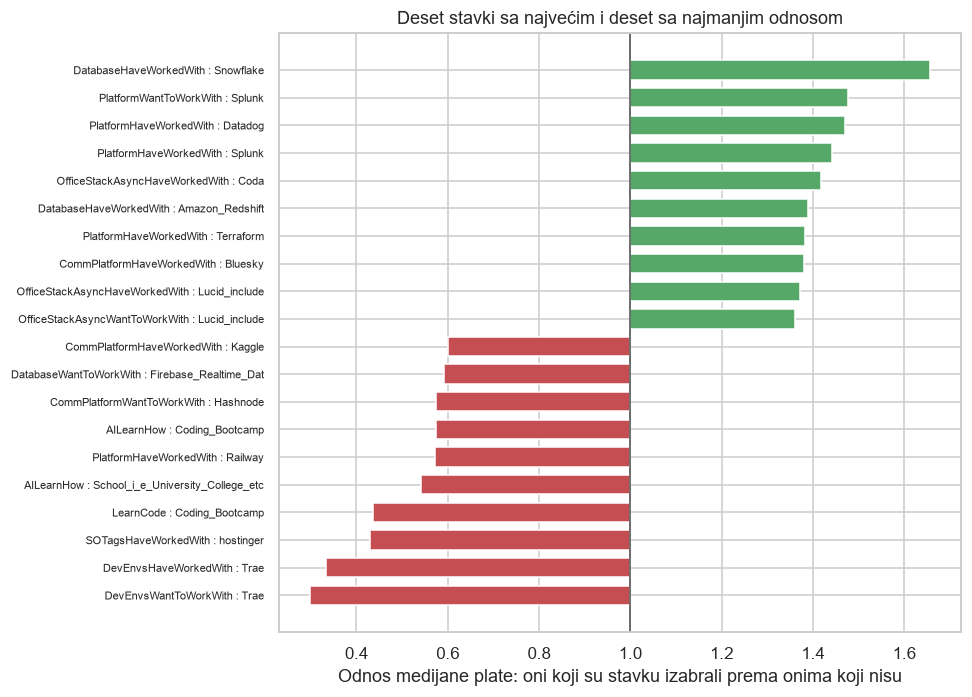

najveći odnos:  1.66 puta   (DatabaseHaveWorkedWith : Snowflake, izabralo 511 ljudi)
najmanji odnos: 0.30 puta   (DevEnvsWantToWorkWith : Trae, izabralo 46 ljudi)
koliko ljudi je izabralo stavke sa krajeva: od 46 do 2,356
stavki kod kojih je odnos ispod 1: 150 od 305


In [30]:
effect = pd.DataFrame({
    "izabrali": [train.loc[items[c] == 1, TARGET].median() for c in kept_items],
    "nisu": [train.loc[items[c] == 0, TARGET].median() for c in kept_items],
}, index=kept_items)
effect["odnos"] = effect["izabrali"] / effect["nisu"]
effect["izabralo_ljudi"] = [int(items[c].sum()) for c in kept_items]

edges = pd.concat([effect.nlargest(10, "odnos"), effect.nsmallest(10, "odnos")])
edges = edges.sort_values("odnos")
labels = [name.replace(ITEM_PREFIX, "").replace("__", " : ")[:46] for name in edges.index]

fig, ax = plt.subplots(figsize=(9, 6.5))
colors = ["#C44E52" if value < 1 else "#55A868" for value in edges["odnos"]]
ax.barh(range(len(edges)), edges["odnos"] - 1, left=1, color=colors, height=0.7)
ax.axvline(1, color="#4C4C4C", linewidth=1)

ax.set_yticks(range(len(edges)))
ax.set_yticklabels(labels, fontsize=7.5)
ax.set_xlabel("Odnos medijane plate: oni koji su stavku izabrali prema onima koji nisu")
ax.set_title("Deset stavki sa najvećim i deset sa najmanjim odnosom")
plt.tight_layout()
plt.show()

print(f"najveći odnos:  {edges['odnos'].max():.2f} puta   ({labels[-1]}, "
      f"izabralo {edges['izabralo_ljudi'].iloc[-1]:,} ljudi)")
print(f"najmanji odnos: {edges['odnos'].min():.2f} puta   ({labels[0]}, "
      f"izabralo {edges['izabralo_ljudi'].iloc[0]:,} ljudi)")
print(f"koliko ljudi je izabralo stavke sa krajeva: od "
      f"{edges['izabralo_ljudi'].min():,} do {edges['izabralo_ljudi'].max():,}")
print(f"stavki kod kojih je odnos ispod 1: {int((effect['odnos'] < 1).sum())} od {len(effect)}")

**Zapažanje:** Odnosi idu od **0,30 do 1,66 puta**. Na gornjem kraju je `Snowflake`, gde oni koji su ga
izabrali imaju 1,66 puta veću medijanu plate; na donjem `Trae`, gde je odnos 0,30. Kod **150 od 305**
zadržanih stavki odnos je ispod jedinice, dakle otprilike pola njih prati **nižu** platu.

**Tumačenje:** Ono što je preživelo ima smisla, i to je bila svrha grafika.

Na strani veće plate su alati velikih firmi i zrelih timova — baze u oblaku, infrastrukturni alati,
sistemi za dokumentaciju. Na strani manje plate su uglavnom novi alati koje tek treba da se dokažu, i
tehnologije koje se uče na početku. To nije spisak tehnologija koje „donose platu" nego oznaka toga u
kakvoj firmi i na kom poslu neko radi — što je i razlog zbog kog ove kolone modelu pomažu.

Odnos od 0,30 pri tome ne znači da neka tehnologija smanjuje platu tri puta.
Znači da je biraju ljudi koji zarađuju manje, a to su najčešće mlađi ispitanici i oni iz zemalja sa nižim
platama — a zemlju i staž model već ima. Zato ovaj grafik i nije osnov za odluku nego provera da nam u
skupu nisu ostale slučajne kolone.

In [31]:
columns_before = train.shape[1]
train = pd.concat([train, items[kept_items]], axis=1)

# The multi-select columns have now given everything they hold: counts in
# section 4, chosen items here. As strings they cannot enter a model, and they
# are what makes the saved file large, so they leave.
text_size_mb = sum(train[c].astype(str).str.len().sum() for c in multi_select) / 1024 ** 2
train = train.drop(columns=multi_select)

print(f"kolona pre sekcije 5:        {columns_before}")
print(f"dodato po stavci:            {len(kept_items)}   (od {items.shape[1]} kandidata)")
print(f"izbačeno multi-select kolona: {len(multi_select)}   "
      f"(iz njih je izvedeno sve što nose)")
print(f"kolona posle:                {train.shape[1]}")
print(f"teksta koji time izlazi iz skupa: oko {text_size_mb:.0f} MB")
print()
print(f"provera da u skupu više nema kolona sa tačka-zarezom: "
      f"{not any(is_multi_select(train[c]) for c in train.columns if is_text(train[c]))}")
print()
print("iz kojih pitanja dolaze zadržane stavke:")
by_source = pd.Series([c.split("__")[0].replace(ITEM_PREFIX, "") for c in kept_items]).value_counts()
print(by_source.head(8).to_string())
print(f"  ... ukupno iz {by_source.size} izvornih kolona od {len(item_sources)}")

kolona pre sekcije 5:        178
dodato po stavci:            305   (od 609 kandidata)
izbačeno multi-select kolona: 36   (iz njih je izvedeno sve što nose)
kolona posle:                447
teksta koji time izlazi iz skupa: oko 26 MB

provera da u skupu više nema kolona sa tačka-zarezom: True

iz kojih pitanja dolaze zadržane stavke:
PlatformHaveWorkedWith                      27
PlatformWantToWorkWith                      21
WebframeWantToWorkWith                      20
DatabaseHaveWorkedWith                      17
OfficeStackAsyncHaveWorkedWith              16
LanguageHaveWorkedWith                      15
CommPlatformHaveWorkedWith                  13
AIToolDon_t_plan_to_use_AI_for_this_task    13
  ... ukupno iz 29 izvornih kolona od 29


### Šta sekcija ostavlja sledećoj

Skup je sa 178 kolona narastao na **447**: dodato je 305 od 609 kandidata, a izbačeno je 36 multi-select
kolona iz kojih je sve izvedeno.

To izbacivanje je važno i vredi ga objasniti. Multi-select kolona je string oblika
`Python;JavaScript;SQL` i model je takvu ne može primiti — u prethodnom notebook-u smo videli da bi
enkodiranje takvih kolona kao običnih kategorija dalo više kolona nego što skup ima redova. Sve što one
nose sada postoji u upotrebljivom obliku: **koliko** je stavki izabrano, iz sekcije 4, i **koje** su
izabrane, iz ove sekcije. Same više nemaju šta da daju, a nose i najveći deo veličine fajla.

Tri stvari se prenose dalje:

- **koje su stavke izabrane vredi mnogo više od toga koliko ih je.** Kolone po stavci dodaju +0,0460 na
  model koji već ima zemlju, staž i sve brojeve — skoro tri puta više nego što su dodali sami brojevi;
- **prag nije mogao da se izvede iz zastupljenosti** jer prekida u nizu nema, ali ni nije trebalo:
  izmerili smo da retkost koloni ne daje nezasluženu prednost. Pravi problem je bio broj provera, i prag
  je postavljen na domet koji slučajnost pri 609 provera ne prelazi;
- **ono što je preživelo je prepoznatljivo** — infrastrukturni i timski alati na jednoj strani, novi i
  početnički na drugoj — pa postupak nije uhvatio šum.

Skup i dalje ima znatno više kolona nego što je udobno za običnu regresiju. To je razlog zbog kog sekcija
9 proverava koliko se nove promenljive međusobno preklapaju, a u modelovanju Ridge i Lasso postoje baš za
ovakav slučaj.

Ostaje još da se obrade **43 kolone sa rangiranjem**, koje su i dalje netaknute — time se bavi sledeća
sekcija.

## 6. Kolone sa rangiranjem

Ostale su **43 numeričke kolone** koje su sve vreme bile tu ali ih nismo dirali. One ne dolaze iz
multi-select pitanja nego iz pitanja tipa „poređaj po važnosti", i vrednost u njima nije količina nego
**mesto na listi**.

Pre nego što s njima bilo šta uradimo, treba da vidimo šta tačno znače i, što je važnije, **koliko od
tih vrednosti je uopšte odgovor ispitanika**. U prethodnom notebook-u su nedostajuće vrednosti u ovim
kolonama popunjene medijanom, pa kod jednog dela ispitanika u koloni ne stoji njihov rang nego naša
procena. Ako to zanemarimo, merili bismo sopstvenu imputaciju.

### 6.1 Šta je u tim kolonama

Za svaku kolonu šema kaže iz kog pitanja dolazi i **koju stavku** ta kolona rangira, pa te oznake
čitamo odatle umesto da ih pogađamo iz imena.

In [32]:
# The four ranking questions and the indicator that says who actually answered
# each of them; the indicators come from the cleaning notebook, where these
# columns were filled with the median.
RANK_QUESTIONS = {
    "TechEndorse": "NotAnswered_TechEndorse_1",
    "TechOppose": "NotAnswered_TechOppose_1",
    "JobSatPoints": "NotAnswered_JobSatPoints_1",
    "SO_Actions": "NotAnswered_SO_Actions_1",
}
item_label = schema.drop_duplicates(subset="qname").set_index("qname")["sub"]

rank_columns = {name: [c for c in train.columns
                       if c.startswith(name) and train[c].dtype.kind in "if"]
                for name in RANK_QUESTIONS}

print(f"kolona sa rangiranjem: {sum(len(c) for c in rank_columns.values())}")
print()
for name, indicator in RANK_QUESTIONS.items():
    columns = rank_columns[name]
    answered = train[indicator] == 0
    values = train.loc[answered, columns]
    # The schema keeps ranking questions one row per column, so the question
    # text and type are read off any one of them.
    entry = question_info.loc[columns[0]]
    text = re.sub(r"<[^>]+>|\s+", " ", str(entry["question"])).strip()
    print(f"{name}  ({entry['type']}, {len(columns)} kolona, {entry['qid']})")
    print(f"  {text[:96]}")
    print(f"  stvarno rangiralo: {int(answered.sum()):>6,} ({100 * answered.mean():.1f}%)   "
          f"imputirano: {int((~answered).sum()):>5,} ({100 * (~answered).mean():.1f}%)")
    print(f"  rangovi idu od {values.min().min():.0f} do {values.max().max():.0f}, "
          f"različitih po ispitaniku: {values.nunique(axis=1).median():.0f}")
    print(f"  primer stavke: {columns[0]} = „{item_label.get(columns[0])}\"")
    print()


# What the fill from the cleaning notebook actually put in these columns, shown
# next to two real answers.
example = rank_columns["TechEndorse"]
skipped = train["NotAnswered_TechEndorse_1"] == 1

print("kako izgleda red od deset kolona pitanja TechEndorse:")
for label, subset in [("rangirao", train.loc[~skipped, example]),
                      ("nije rangirao", train.loc[skipped, example])]:
    for i in range(2):
        print(f"  {label:<14} {[int(v) for v in subset.iloc[i]]}")
print()
print(f"  {'':<14} {'zbir rangova u redu':>28} {'različitih vrednosti':>22}")
for label, mask in [("rangirali", ~skipped), ("nisu rangirali", skipped)]:
    sums = sorted(int(v) for v in train.loc[mask, example].sum(axis=1).unique())
    distinct = sorted(int(v) for v in train.loc[mask, example].nunique(axis=1).unique())
    shown = ", ".join(str(v) for v in sums[:3]) + (" ..." if len(sums) > 3 else "")
    print(f"  {label:<14} {shown:>28} {', '.join(str(v) for v in distinct):>22}")
print(f"  za poređenje, ispravno rangiranje deset stavki: zbir 1+2+...+10 = {sum(range(1, 11))}, "
      f"deset različitih vrednosti")

kolona sa rangiranjem: 43

TechEndorse  (RO, 10 kolona, QID18)
  What attracts you to a technology or causes you to endorse it (most to least important)?
  stvarno rangiralo: 13,867 (94.9%)   imputirano:   741 (5.1%)


  rangovi idu od 1 do 14, različitih po ispitaniku: 10


  primer stavke: TechEndorse_1 = „AI integration or AI Agent capabilities"

TechOppose  (RO, 10 kolona, QID19)
  What would turn you off or cause you to reject it (most to least important)?
  stvarno rangiralo: 13,420 (91.9%)   imputirano: 1,188 (8.1%)
  rangovi idu od 1 do 15, različitih po ispitaniku: 10
  primer stavke: TechOppose_1 = „Lack of AI or AI agents"

JobSatPoints  (RO, 13 kolona, QID27)
  Rank the following attributes of your current professional job in technology according to those 
  stvarno rangiralo: 13,656 (93.5%)   imputirano:   952 (6.5%)


  rangovi idu od 1 do 15, različitih po ispitaniku: 13
  primer stavke: JobSatPoints_1 = „Control over the level of quality in projects"

SO_Actions  (RO, 10 kolona, QID76)
  When visiting Stack Overflow, which following activities are you most interested in? Please rank
  stvarno rangiralo: 11,544 (79.0%)   imputirano: 3,064 (21.0%)
  rangovi idu od 1 do 15, različitih po ispitaniku: 10
  primer stavke: SO_Actions_1 = „Browse content related to Q&A posts I recently viewed"

kako izgleda red od deset kolona pitanja TechEndorse:
  rangirao       [8, 7, 3, 4, 9, 5, 6, 2, 1, 10]
  rangirao       [9, 6, 4, 7, 2, 3, 8, 1, 5, 10]
  nije rangirao  [9, 4, 4, 6, 4, 6, 7, 4, 4, 10]
  nije rangirao  [9, 4, 4, 6, 4, 6, 7, 4, 4, 10]

                          zbir rangova u redu   različitih vrednosti


  rangirali                    55, 56, 58 ...                     10
  nisu rangirali                           58                      5
  za poređenje, ispravno rangiranje deset stavki: zbir 1+2+...+10 = 55, deset različitih vrednosti


**Zapažanje:** Sva četiri pitanja su tipa **`RO`**, dakle rang-pitanja: ispitanik poređa ponuđene stavke
od najvažnije ka najmanje važnoj, a u koloni stoji mesto koje je dodelio toj stavci. Kod onih koji su
stvarno rangirali broj različitih vrednosti u redu poklapa se sa brojem kolona — svaka stavka dobija svoje
mesto i nijedno se ne ponavlja.

Udeo onih koji su stvarno rangirali kreće se od **94,9% kod `TechEndorse` do 79,0% kod `SO_Actions`**.
Ostatak su vrednosti koje smo mi upisali u prethodnom notebook-u — kod `SO_Actions` je to **3.064
ispitanika**.

Poslednji deo ispisa pokazuje **kako to popunjavanje zapravo izgleda**, i to je gore nego što zvuči. U
prethodnom notebook-u je svaka kolona popunjena **svojom** medijanom, nezavisno od ostalih. Pošto
`TechEndorse_1` ima medijanu 9, a `TechEndorse_2` medijanu 4, svaki ispitanik koji je pitanje preskočio
dobio je **isti red**: `[9, 4, 4, 6, 4, 6, 7, 4, 4, 10]`. U njemu se rang 4 javlja četiri puta, ima svega
pet različitih vrednosti umesto deset, a zbir je 58 umesto 55.

**Tumačenje:** To nije rangiranje. Nijedan ispitanik ne bi mogao tako da odgovori, jer se u rang-pitanju
mesto ne može dodeliti dvaput.

Popunjavanje medijanom je za ove kolone, dakle, samo **čuvanje mesta** — način da u tabeli ne ostane
prazno polje, a ne procena nečijeg odgovora. Za rang-pitanje ni ne postoji popunjavanje koje bi bilo
bolje: svaka izmišljena lista je izmišljena. Ono što jeste urađeno kako treba je da uz te kolone stoji
indikator `NotAnswered_`, pa model može da razlikuje te ispitanike od ostalih, a svi oni u ovih 43 kolone
imaju identične vrednosti — dakle ništa što bi model mogao pogrešno da nauči osim jedne konstante, koju
indikator ionako objašnjava.

Iz ovoga slede dve stvari.

Prva je da rang **nije količina** nego mesto, i da manji broj znači veću važnost. Kad takvu kolonu
stavimo u regresiju kao broj, pretpostavljamo da je razlika između prvog i drugog mesta ista kao između
devetog i desetog — što ne mora biti tačno. Zato u odeljku 6.3 poredimo taj pristup sa drugim, koji takvu
pretpostavku ne pravi.

Druga je razlog zbog kog dalje **merimo samo na onima koji su rangirali**. Kod `SO_Actions` bi svaki peti
ispitanik u merenje ušao sa istim izmišljenim redom, pa bi rezultat delom govorio o našem popunjavanju, a
ne o njihovim odgovorima.

### 6.2 Koliko rang nosi, mereno samo na onima koji su rangirali

Merilo iz sekcije 2 primenjujemo kao i do sada, uz jednu izmenu koju nameće imputacija: **računamo samo
na ispitanicima koji su pitanje stvarno rangirali.** Kod ostalih u koloni stoji medijana koju smo mi
upisali, ista za sve njih, pa bi njihovo uključivanje merilo koliko naša imputacija liči na platu — a to
nas ne zanima.

Rang je broj kod kog **manja vrednost znači veću važnost**: 1 je ono što je ispitaniku na prvom mestu. To
znači da negativan koeficijent u regresiji treba čitati obrnuto nego obično — što je stavka više na
listi, to je vrednost manja.

In [33]:
def signal_on_subset(values, mask):
    """The same measure as in section 2, computed on part of the rows only."""
    target = train.loc[mask, TARGET_LOG]
    model = sm.OLS(target.to_numpy(),
                   design_matrix(values[mask]).to_numpy()).fit()
    return {"n": int(mask.sum()), "R": float(np.sqrt(model.rsquared)),
            "R2_prilag": model.rsquared_adj, "p": model.f_pvalue}


measured_ranks = {}
for name, indicator in RANK_QUESTIONS.items():
    answered = train[indicator] == 0
    for column in rank_columns[name]:
        measured_ranks[column] = signal_on_subset(train[column], answered)

measured_ranks = pd.DataFrame(measured_ranks).T.sort_values("R2_prilag", ascending=False)
measured_ranks["stavka"] = [str(item_label.get(c))[:44] for c in measured_ranks.index]

print("osam najjačih pojedinačnih rangova:")
top = measured_ranks.head(8)
print(pd.DataFrame({"n": top["n"].map(lambda v: f"{int(v):,}"),
                    "R": top["R"].map(lambda v: f"{v:.3f}"),
                    "R2_prilag": top["R2_prilag"].map(lambda v: f"{v:.4f}"),
                    "p": top["p"].map(format_p),
                    "stavka": top["stavka"]}).to_string())
print()
band_ranks = pd.cut(measured_ranks["R2_prilag"], [-np.inf, NOISE_LIMIT, SIGNAL_LIMIT, np.inf],
                    labels=["šum", "slaba", "nosi signal"])
band_ranks = band_ranks.mask(measured_ranks["p"] >= 0.05, "šum")
print("razvrstano po pravilu iz 2.5:")
for label, count in band_ranks.value_counts().reindex(["nosi signal", "slaba", "šum"]).items():
    print(f"  {label:<14} {int(count):>3} od {len(measured_ranks)}")

osam najjačih pojedinačnih rangova:
                      n      R R2_prilag        p                                   stavka
TechOppose_1     13,420  0.178    0.0316    5e-96                  Lack of AI or AI agents
JobSatPoints_4   13,656  0.152    0.0230  2.3e-71                           Expert mentors
TechEndorse_1    13,867  0.149    0.0222  8.5e-70  AI integration or AI Agent capabilities
SO_Actions_10    11,544  0.138    0.0189  5.5e-50           Use discussion or chat feature
JobSatPoints_11  13,656  0.120    0.0142    1e-44             Competitive pay and benefits
JobSatPoints_16  13,656  0.105    0.0109  1.5e-34                    You like your manager
JobSatPoints_6   13,656  0.102    0.0104  5.2e-33         Developing specialized expertise
TechEndorse_4    13,867  0.096    0.0091  1.2e-29     Customizable and manageable codebase

razvrstano po pravilu iz 2.5:
  nosi signal      1 od 43
  slaba           35 od 43
  šum              7 od 43


**Zapažanje:** Najjača pojedinačna kolona je **`TechOppose_1`, „Lack of AI or AI agents"**, sa
prilagođenim R² od **0,0316** — jedina koja po pravilu iz 2.5 prelazi granicu od 0,0286. Slede
`JobSatPoints_4` („Expert mentors", 0,0230) i `TechEndorse_1` („AI integration or AI Agent capabilities",
0,0222). Od 43 kolone, **35 je slabo, a 7 je šum**.

**Tumačenje:** Vrh liste je zanimljiv jer se tri od četiri najjače kolone tiču istog — **odnosa prema AI**
i prema mentorstvu.

Kod `TechOppose_1` treba paziti na smer. Kolona sadrži mesto koje je ispitanik dao stavci „nedostatak AI
me odbija od tehnologije"; **manji broj znači da mu je to važnije**. Sam po sebi rang ne kaže na koju
stranu ide plata — to se vidi tek iz koeficijenta, i tu razliku ćemo morati da čitamo pažljivo u fazi
modelovanja.

Kod `JobSatPoints_4` je čitanje neposrednije i pokazuje ga Grafik 7: onima koji su „stručne mentore"
stavili na prvo mesto plata je najniža u celom pitanju. To nije iznenađenje — mentore najviše traže oni
koji su na početku karijere.

Nijedna od 43 kolone nije jaka sama za sebe, što je do sada bilo pravilo a ne izuzetak. Da li zajedno
vrede, i u kom obliku, rešava odeljak 6.3.

### Grafik 7 — šta je ispitaniku najvažnije i koliko zarađuje

**Motivacija:** Rang jedne stavke govori malo sam za sebe, ali ono što je ispitaniku **na prvom mestu**
sažima celu njegovu listu u jedan podatak. Kod pitanja o zadovoljstvu poslom to je posebno čitljivo: neko
ko na prvo mesto stavi platu verovatno gleda na posao drugačije od nekoga kome je prvo mentorstvo. Da li
se to vidi i u zaradi, ne znamo — crtamo medijanu plate po tome šta je kod koga na prvom mestu.

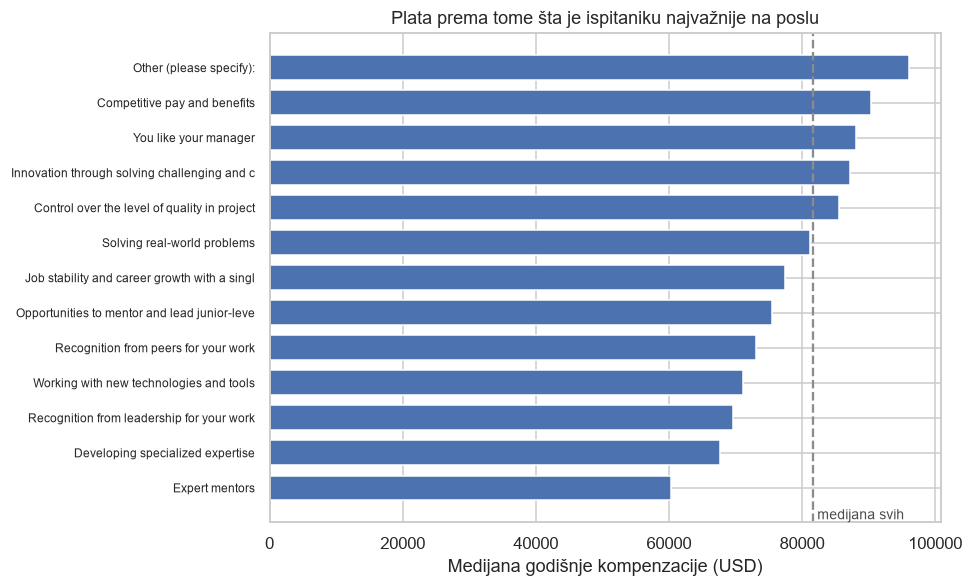

prikazano izbora sa bar 100 ispitanika: 13 od 13
raspon medijana: 60,328 do 96,033 USD (1.59 puta)

                  median  size                                        stavka
JobSatPoints_4   60328.0   389                                Expert mentors
JobSatPoints_6   67655.0   543              Developing specialized expertise
JobSatPoints_14  69609.0   402     Recognition from leadership for your work
JobSatPoints_10  71125.5   784       Working with new technologies and tools
JobSatPoints_13  73089.0   379          Recognition from peers for your work
JobSatPoints_5   75410.0   235  Opportunities to mentor and lead junior-leve
JobSatPoints_8   77399.0  1435  Job stability and career growth with a singl
JobSatPoints_7   81210.0  2277                   Solving real-world problems
JobSatPoints_1   85557.0  1187  Control over the level of quality in project
JobSatPoints_9   87135.5  1388  Innovation through solving challenging and c
JobSatPoints_16  88121.5  1134                       

In [34]:
def top_choice(name):
    """Which of the available items the respondent put highest.

    The lowest rank wins. Taking the smallest rather than looking for rank 1
    matters because a few items of each question are not in our columns, so the
    literal first place is sometimes missing while the order among the rest holds.
    """
    columns = rank_columns[name]
    answered = train[RANK_QUESTIONS[name]] == 0
    return train[columns].idxmin(axis=1).where(answered, "NotAnswered")


choice = top_choice("JobSatPoints")
answered = choice != "NotAnswered"

by_choice = train[answered].groupby(choice[answered])[TARGET].agg(["median", "size"])
by_choice = by_choice[by_choice["size"] >= 100].sort_values("median")
labels = [str(item_label.get(c, c))[:44] for c in by_choice.index]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(range(len(by_choice)), by_choice["median"], color="#4C72B0", height=0.7)
ax.axvline(train.loc[answered, TARGET].median(), color="#8C8C8C", linestyle="--", linewidth=1.5)

ax.set_yticks(range(len(by_choice)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Medijana godišnje kompenzacije (USD)")
ax.set_title("Plata prema tome šta je ispitaniku najvažnije na poslu")
ax.text(train.loc[answered, TARGET].median(), -0.9, " medijana svih",
        color="#4C4C4C", fontsize=9)
plt.tight_layout()
plt.show()

print(f"prikazano izbora sa bar 100 ispitanika: {len(by_choice)} od {choice[answered].nunique()}")
print(f"raspon medijana: {by_choice['median'].min():,.0f} do {by_choice['median'].max():,.0f} USD "
      f"({by_choice['median'].max() / by_choice['median'].min():.2f} puta)")
print()
print(by_choice.assign(stavka=labels).to_string())

**Zapažanje:** Raspon medijana je **od 60.328 do 96.033 dolara**, dakle **1,59 puta**. Najnižu platu imaju
oni kojima su na prvom mestu **stručni mentori** (60.328, njih 389), a najvišu oni koji su izabrali
„Other" (96.033, njih 185). Među odgovorima sa najviše ljudi, **konkurentna plata** je na prvom mestu kod
**3.318 ispitanika**, sa medijanom od 90.422 — među najvišima.

Ispod proseka su, redom, mentori, razvijanje uske ekspertize, priznanje od rukovodstva i rad sa novim
tehnologijama.

**Tumačenje:** Poredak ima jasnu logiku i ona nije o tome da neki prioritet „donosi" platu, nego o tome
**ko ga bira**. Mentore i priznanje traže oni na početku karijere; stabilnost i konkurentnu platu biraju
oni koji su već u poziciji da o tome pregovaraju. Isti obrazac smo videli i kod stavki u sekciji 5.

Raspon od 1,59 puta je pri tome skroman u poređenju sa 136,8 puta koliko daje zemlja. Ovo je promenljiva
koja može da doprinese, ali nije reda veličine onoga što nose zemlja ili iskustvo.

### 6.3 Hipoteza 8 — rang po stavci ili samo ono što je prvo

Iz 43 kolone sa rangiranjem mogu se izvesti dva sasvim različita skupa promenljivih, i treba izabrati.

**Rangovi kakvi jesu.** Svaka od 43 kolone ulazi kao broj. Zadržava se cela lista — i šta je prvo i šta
je poslednje — ali se pretpostavlja da rang deluje kao količina, dakle da je razlika između prvog i drugog
mesta ista kao između devetog i desetog.

**Samo ono što je na prvom mestu.** Iz svakog pitanja se izvodi jedna kategorijska promenljiva sa
onoliko kategorija koliko ima stavki. Gubi se sve osim vrha liste, ali se ne pretpostavlja ništa o tome
kako rangovi deluju — svaka kategorija dobija svoj koeficijent.

Druga mogućnost deluje privlačnije jer je sažetija: četiri promenljive umesto 43. Ali sažimanje uvek
nešto baca, a ovde baca dosta — dvoje ljudi kojima je isto na prvom mestu mogu imati potpuno različit
ostatak liste.

Poređenje radimo nad onim što notebook do sada ima: zemljom, svim promenljivama iz sekcija 4 i 5 i
nasleđenim brojčanim kolonama. Ostale nasleđene kategorijske kolone u toj osnovi nisu, jer se njima
bavi tek sekcija 8.

> **Hipoteza:** Ono što je ispitaniku na prvom mestu nosi bar onoliko informacije o plati koliko i cela
> lista rangova.
>
> **Kriterijum:** Hipoteza je potvrđena ako četiri promenljive „prvo mesto", dodate na model iz sekcije 5,
> daju prirast prilagođenog R² bar toliki koliki daju sve 43 kolone sa rangovima. Poređenje je na
> prilagođenom R², pa je svaka mogućnost kažnjena za kolone koje troši — četiri kategorijske promenljive
> u model unose oko četrdeset dummy kolona, dakle otprilike isto koliko i sami rangovi.

In [35]:
from scipy import linalg

all_rank_columns = [c for columns in rank_columns.values() for c in columns]
top_choices = pd.DataFrame({f"Top_{name}": top_choice(name) for name in RANK_QUESTIONS},
                           index=train.index)

# Everything the notebook has built so far, plus the plain numeric columns it
# inherited — which is what a new variable has to improve on at this point.
# Read off the frame rather than listed by hand: every numeric column that is
# not a ranking and not the target.
current = [c for c in train.columns
           if c not in (TARGET, TARGET_LOG) and train[c].dtype.kind in "if"
           and not RANK_NAME.fullmatch(c)]


def independent_columns(design):
    """The columns that are not an exact combination of the others.

    With this many columns some are bound to be determined by the rest, and a
    regression then has no unique solution. The factorisation below orders the
    columns by how much new direction each one adds, so those that add nothing
    are the ones to leave out.
    """
    matrix = design.to_numpy(dtype=float)
    _, upper, order = linalg.qr(matrix, mode="economic", pivoting=True)
    tolerance = abs(upper[0, 0]) * max(matrix.shape) * np.finfo(float).eps
    rank = int((abs(np.diag(upper)) > tolerance).sum())
    return [design.columns[i] for i in order[:rank]], [design.columns[i] for i in order[rank:]]


def fit_with(extra=None, report=False, label=""):
    parts = [pd.get_dummies(train["Country"].astype(str), prefix="Country",
                            drop_first=True, dtype=float),
             train[current].astype(float)]
    if extra is not None:
        parts.append(extra)
    design = pd.concat(parts, axis=1)
    keep, dropped = independent_columns(design)
    if report:
        print(f"  {label:<30} kolona {design.shape[1]:>3}, zavisnih {len(dropped):>2}"
              f"   {dropped[:3]}")
    design = sm.add_constant(design[keep], has_constant="add")
    return sm.OLS(train[TARGET_LOG].to_numpy(), design.to_numpy()).fit()


rank_block = train[all_rank_columns].astype(float)

# Two categories have to come out of each of these variables, not one. The
# notebook already carries a NotAnswered_ column per question, so a dummy for
# "not answered" would copy it; and once that is gone, the remaining dummies plus
# that indicator plus the intercept still add up to one, so one more has to go.
top_block = pd.get_dummies(top_choices, dtype=float)
redundant = [c for c in top_block.columns if c.endswith("NotAnswered")]
for name in top_choices.columns:
    real = [c for c in top_block.columns
            if c.startswith(name + "_") and c not in redundant]
    redundant.append(real[0])
top_block = top_block.drop(columns=redundant)

print("provera da li neka kolona ponavlja ono što druge već nose:")
base_now = fit_with(report=True, label="zemlja i sve izvedeno")
with_ranks = fit_with(rank_block, report=True, label="+ rangovi")
with_tops = fit_with(top_block, report=True, label="+ prvo mesto")
with_both = fit_with(pd.concat([rank_block, top_block], axis=1),
                     report=True, label="+ oboje")
print()

print(f"{'model':<34} {'prilagođeni':>12} {'prirast':>9} {'kolona':>7}")
for label, model in [("zemlja i sve izvedeno (4 i 5)", base_now),
                     ("+ 43 ranga kao brojevi", with_ranks),
                     ("+ 4 promenljive „prvo mesto\"", with_tops),
                     ("+ oboje", with_both)]:
    gain = model.rsquared_adj - base_now.rsquared_adj
    print(f"{label:<34} {model.rsquared_adj:>12.4f} {gain:>+9.4f} {int(model.df_model):>7}")

print()
print(f"tipičan prirast anketnog obeležja: {typical_gain:+.4f}")
print(f"rangovi dodaju bar koliko i „prvo mesto\": "
      f"{bool(with_ranks.rsquared_adj >= with_tops.rsquared_adj)}")

provera da li neka kolona ponavlja ono što druge već nose:


  zemlja i sve izvedeno          kolona 508, zavisnih  0   []


  + rangovi                      kolona 551, zavisnih  0   []


  + prvo mesto                   kolona 547, zavisnih  0   []


  + oboje                        kolona 590, zavisnih  0   []



model                               prilagođeni   prirast  kolona
zemlja i sve izvedeno (4 i 5)            0.6471   +0.0000     508
+ 43 ranga kao brojevi                   0.6556   +0.0084     551
+ 4 promenljive „prvo mesto"             0.6508   +0.0037     547
+ oboje                                  0.6560   +0.0089     590

tipičan prirast anketnog obeležja: +0.0072
rangovi dodaju bar koliko i „prvo mesto": True


**Zapažanje:** Provera zavisnosti na početku ispisa odmah je nešto našla — promenljive „prvo
mesto", onako kako se prvo naprave, **ponavljaju ono što već imamo**. Za svako od četiri pitanja postoji
kolona `NotAnswered_`, pa bi dummy za kategoriju „nije odgovorio" bio njena tačna kopija; a i kad se ta
kategorija izbaci, preostale dummy kolone jednog pitanja zajedno sa tim indikatorom i slobodnim članom i
dalje daju jedinicu. Zato iz svake promenljive izlaze **dve** kategorije umesto jedne. Posle toga nijedan
model nema zavisnih kolona.

Rezultat poređenja:

- 43 ranga kao brojevi dodaju **+0,0084**;
- četiri promenljive „prvo mesto" dodaju **+0,0037**, uz sličan broj kolona;
- oboje zajedno dodaju **+0,0089**, dakle svega 0,0005 više od samih rangova.

**Verdikt: hipoteza je opovrgnuta.** Ono što je ispitaniku na prvom mestu nosi **manje od pola** onoga što
nosi cela lista.

**Tumačenje:** Sažimanje je ovde koštalo više nego što je donelo. To ima smisla kad se pogleda šta se
gubi: dvoje ljudi kojima je na prvom mestu „konkurentna plata" mogu imati potpuno različit ostatak liste
— jedan mentore na drugom mestu, drugi na poslednjem — a ta razlika po svemu sudeći nešto znači.

Poslednji red je usput i odgovor na pitanje da li vredi zadržati oboje: pošto „prvo mesto" povrh rangova
dodaje samo 0,0005, ono što ono nosi već je sadržano u rangovima. Cela lista, dakle, **sadrži svoj vrh**,
a obrnuto ne važi.

Prirast rangova od +0,0084 je iznad tipičnog prirasta anketnog obeležja (+0,0072), pa 43 kolone ostaju.

### 6.4 Šta zadržavamo

Odluka je time doneta: **rangove zadržavamo kakvi jesu, promenljive „prvo mesto" ne pravimo.** Ostaje još
da se na rangove primeni isto pravilo kao na sve ostalo — da se izbaci ono što je po merenju šum, uz
proveru koliko to košta.

In [36]:
noise_ranks = list(band_ranks[band_ranks == "šum"].index)
kept_ranks = [c for c in all_rank_columns if c not in noise_ranks]

print(f"rangova označenih kao šum: {len(noise_ranks)} od {len(all_rank_columns)}")
for column in noise_ranks:
    print(f"  {column:<18} {str(item_label.get(column))[:52]}")
print()

with_all_ranks = fit_with(train[all_rank_columns].astype(float))
with_kept_ranks = fit_with(train[kept_ranks].astype(float))
print(f"model sa svih {len(all_rank_columns)} rangova:  prilagođeni={with_all_ranks.rsquared_adj:.4f}")
print(f"model bez {len(noise_ranks)} označenih kao šum: prilagođeni={with_kept_ranks.rsquared_adj:.4f}")
print(f"cena izbacivanja:              {with_kept_ranks.rsquared_adj - with_all_ranks.rsquared_adj:+.5f}")
print()

train = train.drop(columns=noise_ranks)
print(f"izbačeno kolona: {len(noise_ranks)}")
print(f"kolona u skupu na kraju sekcije: {train.shape[1]}")

rangova označenih kao šum: 7 od 43
  SO_Actions_7       Upvote/Downvote Q&A posts
  SO_Actions_5       Ask a question
  SO_Actions_4       Directly open a Q&A post via search, documentation o
  SO_Actions_15      Other (write in):
  SO_Actions_9       Comment on Q&A posts
  TechOppose_15      Other (please specify):
  TechEndorse_2      Easy-to-use API



model sa svih 43 rangova:  prilagođeni=0.6556
model bez 7 označenih kao šum: prilagođeni=0.6557
cena izbacivanja:              +0.00009

izbačeno kolona: 7
kolona u skupu na kraju sekcije: 440


### Šta sekcija ostavlja sledećoj

Kolone sa rangiranjem su obrađene, i za razliku od prethodne dve sekcije ovde **nismo dodali nijednu novu
promenljivu** — samo smo utvrdili da su postojeće u dobrom obliku i izbacili one koje su šum.

Tri nalaza:

- **rang kao broj radi bolje od sažimanja na „šta je prvo".** Cela lista sadrži svoj vrh, obrnuto ne
  važi, pa se sažimanjem samo gubi;
- **rangovi zajedno dodaju +0,0084**, iznad tipičnog prirasta anketnog obeležja, iako pojedinačno samo
  jedna kolona prelazi granicu od 0,0286;
- **prilikom pravljenja novih kategorijskih promenljivih treba paziti na indikatore neodgovaranja.**
  Kategorija „nije odgovorio" ponavlja ono što indikator već nosi, i to model čini nerešivim. Ovo je
  prvi put da smo na to naleteli i verovatno neće biti poslednji — sekcija 9 se time bavi sistematski.

Za sledeću sekciju ostaje **`Country`**, koji je sve vreme u modelu kao 141 dummy kolona i sam objašnjava
više od svega ostalog zajedno. Pitanje je da li mu je toliko kolona zaista potrebno.

## 7. Zemlja: prvih N i ostalo

`Country` je od prve sekcije najjače obeležje koje imamo — sam objašnjava 55,87% varijanse, više nego
svih devet ostalih anketnih pitanja zajedno. Ali to dolazi po ceni: u model ulazi kao **141 dummy
kolona**, jedna manje nego što ima zemalja.

Do sada je to bila najveća stavka u modelu. Posle sekcija 4, 5 i 6 nije više, ali je i dalje velika, a
pitanje je da li joj je toliko kolona zaista potrebno. Zemlje se u uzorku razlikuju po veličini
ogromno — od nekoliko hiljada ispitanika do jednog ili dva — pa se lako može desiti da najveći deo onoga
što `Country` nosi dolazi od nekoliko desetina zemalja, a ostatak da su kolone koje se oslanjaju na
šačicu ljudi.

Uobičajen postupak za kategorijsku promenljivu sa previše kategorija je **„prvih N i ostalo"**: zadrže se
zemlje sa najviše ispitanika, a sve ostale se spoje u jednu kategoriju. Pitanje koje treba rešiti je
koliko iznosi N, i njega ćemo izvesti, ne izabrati.

### 7.1 Koliko je zemalja i koliko su nejednake

In [37]:
country_counts = train["Country"].value_counts()

print(f"zemalja u trening skupu: {len(country_counts)}   "
      f"kolona koje bi dale: {len(country_counts) - 1}")
print()
print("pet najvećih:")
for name, count in country_counts.head(5).items():
    print(f"  {name[:44]:<46} {count:>5,} ({100 * count / len(train):>4.1f}%)")
print()
for limit in [500, 100, 30, 10]:
    small = country_counts[country_counts < limit]
    print(f"zemalja sa manje od {limit:>3} ispitanika: {len(small):>3}   "
          f"nose {int(small.sum()):>5,} ispitanika ({100 * small.sum() / len(train):.1f}%)")
print()
print(f"medijana broja ispitanika po zemlji: {country_counts.median():.0f}")
print(f"polovina zemalja nosi ukupno: "
      f"{int(country_counts.tail(len(country_counts) // 2).sum()):,} ispitanika")

zemalja u trening skupu: 142   kolona koje bi dale: 141

pet najvećih:
  United States of America                       3,205 (21.9%)
  Germany                                        1,265 ( 8.7%)
  United Kingdom of Great Britain and Northern     979 ( 6.7%)
  India                                            696 ( 4.8%)
  France                                           645 ( 4.4%)

zemalja sa manje od 500 ispitanika: 136   nose 7,241 ispitanika (49.6%)
zemalja sa manje od 100 ispitanika: 111   nose 1,963 ispitanika (13.4%)
zemalja sa manje od  30 ispitanika:  85   nose   539 ispitanika (3.7%)
zemalja sa manje od  10 ispitanika:  63   nose   192 ispitanika (1.3%)

medijana broja ispitanika po zemlji: 12
polovina zemalja nosi ukupno: 277 ispitanika


**Zapažanje:** Zemalja ima **142**, ali su krajnje nejednake. Sjedinjene Države same nose **21,9%**
ispitanika, a prvih pet zemalja skoro polovinu. Na drugom kraju, **85 zemalja ima manje od trideset
ispitanika** i zajedno nose 539 ljudi, dakle 3,7% skupa.

Najjasnije to govori medijana: **polovina zemalja ima 12 ili manje ispitanika**, a svih 71 tih zemalja
zajedno nosi **277 ljudi** — manje nego jedna Francuska.

**Tumačenje:** Ovo je oblik za koji je „prvih N i ostalo" i smišljeno. Zemlja sa deset ispitanika u model
donosi svoju kolonu, a ta kolona uči prosek deset ljudi — to je procena koja se lako pomeri i za koju je
malo verovatno da će važiti i na test skupu.

Pitanje je samo gde povući granicu, a nju ne postavljamo po osećaju nego merimo.

### 7.2 Koliko zemalja zadržati

N ne biramo nego ga izvodimo, i to istim merilom kojim smo do sada sve merili.

Za svaki N zadržimo N zemalja sa najviše ispitanika, ostatak spojimo u kategoriju **`Other`**, i izmerimo
koliko takva promenljiva objašnjava. Zatim gledamo **koliko se time gubi** u odnosu na to da zadržimo sve
zemlje.

Prag je isti onaj koji koristimo od odeljka 4.3: **gubitak sme da bude manji od onoga što tipično anketno
obeležje dodaje na osnovu**, dakle manji od 0,0072. Ako je gubitak manji od toga, sažimanje košta manje
nego što vredi jedno prosečno pitanje iz ankete — a dobija se osetno manje kolona.

Uzimamo **najmanji N koji taj uslov ispunjava**, jer nema smisla nositi više kolona nego što treba.

In [38]:
def country_groups(n, series=None):
    """The n largest countries kept as they are, everything else as one group."""
    series = train["Country"] if series is None else series
    largest = country_counts.head(n).index
    return series.where(series.isin(largest), "Other")


def country_strength(n):
    """Adjusted R² of the grouped country variable on its own."""
    design = sm.add_constant(pd.get_dummies(country_groups(n), drop_first=True, dtype=float))
    return sm.OLS(train[TARGET_LOG].to_numpy(), design.to_numpy()).fit().rsquared_adj


full_strength = country_strength(len(country_counts))
curve = pd.Series({n: country_strength(n) for n in range(5, len(country_counts) + 1, 5)})
curve.loc[len(country_counts)] = full_strength

print(f"sve zemlje ({len(country_counts)}): prilagođeni R² = {full_strength:.4f}")
print(f"dozvoljeni gubitak (tipičan prirast anketnog obeležja): {typical_gain:.4f}")
print()
print(f"{'N':>5} {'kolona':>7} {'prilagođeni R²':>16} {'gubitak':>9}")
for n, value in curve.items():
    marker = "  ispod praga" if full_strength - value < typical_gain else ""
    print(f"{n:>5} {n - 1 if n == len(country_counts) else n:>7} {value:>16.4f} "
          f"{full_strength - value:>9.4f}{marker}")

COUNTRY_KEEP = next(n for n in range(1, len(country_counts) + 1)
                    if full_strength - country_strength(n) < typical_gain)
print()
print(f"najmanji N sa gubitkom ispod praga: {COUNTRY_KEEP}")
print(f"gubitak pri tom N: {full_strength - country_strength(COUNTRY_KEEP):.4f}")

sve zemlje (142): prilagođeni R² = 0.5544
dozvoljeni gubitak (tipičan prirast anketnog obeležja): 0.0072

    N  kolona   prilagođeni R²   gubitak
    5       5           0.2813    0.2731
   10      10           0.3546    0.1998
   15      15           0.3743    0.1801
   20      20           0.4127    0.1417
   25      25           0.4319    0.1225
   30      30           0.4492    0.1052
   35      35           0.4797    0.0747
   40      40           0.4874    0.0670
   45      45           0.5000    0.0544
   50      50           0.5182    0.0362
   55      55           0.5371    0.0173
   60      60           0.5402    0.0142
   65      65           0.5499    0.0045  ispod praga
   70      70           0.5509    0.0035  ispod praga
   75      75           0.5514    0.0030  ispod praga
   80      80           0.5521    0.0023  ispod praga
   85      85           0.5522    0.0022  ispod praga
   90      90           0.5533    0.0011  ispod praga
   95      95           0.5533    0.0


najmanji N sa gubitkom ispod praga: 61
gubitak pri tom N: 0.0052


**Zapažanje:** Kriva raste dugo. Sa pet zemalja `Country` objašnjava svega 0,2813, sa trideset 0,4492, a
tek negde oko šezdesete približi se punoj vrednosti od 0,5544. **Najmanji N sa gubitkom ispod praga je
61**, i tu gubitak iznosi **0,0052**.

Posle toga se dobitak gasi: od 61 do svih 142 zemlje prilagođeni R² poraste za manje od 0,006, iako se
model uveća za osamdeset kolona.

**Tumačenje:** Rezultat je manje povoljan nego što bi se očekivalo. Nije bilo tako da nekoliko velikih
zemalja nosi sve — zemlja stvarno nosi informaciju duboko u listu, sve do onih sa nekoliko desetina
ispitanika. To ima smisla: `Country` ovde ne označava naciju nego **tržište rada i kupovnu moć**, a to su
veličine koje se razlikuju od države do države i ne svode se na nekoliko grupa.

Zato N ispada relativno visok. Ali osamdeset kolona manje i dalje je osetna ušteda u modelu koji ih ima
preko četiri stotine, a plaća se gubitkom manjim od onoga što donese jedno prosečno anketno pitanje.

### Grafik 8 — koliko se dobija svakom sledećom zemljom

**Motivacija:** Tabela daje vrednosti u nekoliko tačaka, ali se iz nje ne vidi **oblik** — da li se dobitak
troši postepeno ili naglo stane. To je ono što odlučuje da li „prvih N i ostalo" uopšte ima smisla: ako
kriva raste do samog kraja, svaka zemlja nosi nešto svoje i sažimanje je gubitak; ako se poravna, ono što
je iza te tačke su kolone koje se drže na šačici ljudi.

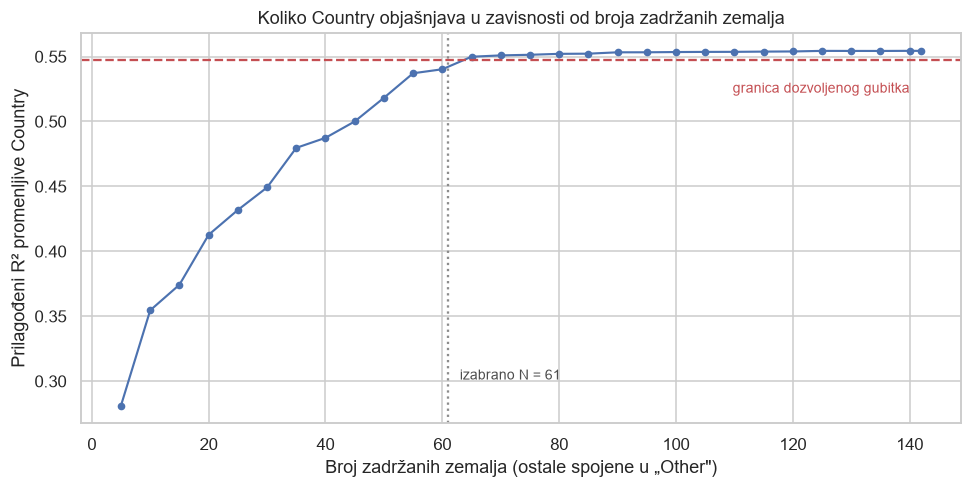

zadržano zemalja: 61   spojeno u „Other": 81
ispitanika u „Other": 440 (3.0%)
najmanja zadržana zemlja ima 21 ispitanika

medijana plate u „Other":    44,096 USD
medijana celog skupa:        81,210 USD
kolona umesto 141: 61   (ušteda 80)


In [39]:
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(curve.index, curve.values, marker="o", markersize=4, linewidth=1.4, color="#4C72B0")
ax.axhline(full_strength - typical_gain, color="#C44E52", linestyle="--", linewidth=1.5)
ax.axvline(COUNTRY_KEEP, color="#8C8C8C", linestyle=":", linewidth=1.5)

ax.set_xlabel("Broj zadržanih zemalja (ostale spojene u „Other\")")
ax.set_ylabel("Prilagođeni R² promenljive Country")
ax.set_title("Koliko Country objašnjava u zavisnosti od broja zadržanih zemalja")
ax.text(COUNTRY_KEEP + 2, curve.min() + 0.02, f"izabrano N = {COUNTRY_KEEP}",
        color="#4C4C4C", fontsize=9)
ax.text(len(country_counts) - 2, full_strength - typical_gain - 0.025,
        "granica dozvoljenog gubitka", color="#C44E52", fontsize=9, ha="right")
plt.tight_layout()
plt.show()

grouped = country_groups(COUNTRY_KEEP)
in_other = grouped == "Other"
print(f"zadržano zemalja: {COUNTRY_KEEP}   spojeno u „Other\": "
      f"{len(country_counts) - COUNTRY_KEEP}")
print(f"ispitanika u „Other\": {int(in_other.sum()):,} ({100 * in_other.mean():.1f}%)")
print(f"najmanja zadržana zemlja ima {country_counts.iloc[COUNTRY_KEEP - 1]} ispitanika")
print()
print(f"medijana plate u „Other\": {train.loc[in_other, TARGET].median():>9,.0f} USD")
print(f"medijana celog skupa:     {train[TARGET].median():>9,.0f} USD")
print(f"kolona umesto {len(country_counts) - 1}: {COUNTRY_KEEP}   "
      f"(ušteda {len(country_counts) - 1 - COUNTRY_KEEP})")

**Zapažanje:** Grafik pokazuje krivu koja raste skoro pravolinijski do oko pedesete zemlje, pa se naglo
poravna. Izabrani N stoji tačno na mestu gde kriva preseca granicu dozvoljenog gubitka.

Sažimanje ostavlja **61 zemlju**, a u `Other` spaja **81 zemlju sa 440 ispitanika (3,0%)**. Najmanja
zadržana zemlja ima 21 ispitanika. Umesto 141 kolone dobijamo 61, dakle **osamdeset manje**.

Medijana plate u grupi `Other` je **44.096 dolara**, naspram 81.210 u celom skupu.

**Tumačenje:** Poslednji broj je važan. Grupa `Other` **nije nasumičan ostatak** —
to su pretežno manja tržišta sa nižim platama, pa je njena medijana skoro upola manja od opšte. Spajanjem
tih zemalja model gubi mogućnost da ih međusobno razlikuje, ali ne gubi ono glavno: da su to tržišta sa
nižim platama, jer to sada nosi sama kategorija `Other`.

Da su te zemlje bile izmešane po visini plate, spajanje bi bilo mnogo štetnije — sve razlike među njima
bi se poništile u jednom proseku. Ovako se gubi finoća, ali ne i smer.

### 7.3 Hipoteza 9 — da li sažimanje košta i u punom modelu

Sve dosad merili smo `Country` **samu za sebe**. To je dobra osnova za izbor N, ali nije odgovor na
pitanje koje nas zapravo zanima: koliko se gubi u modelu u kom su i sve ostale promenljive.

Razlog da to bude drugačije je konkretan. Male zemlje koje spajamo u `Other` nisu nasumičan skup — to su
uglavnom tržišta sa nižim platama, što se vidi i po medijani te grupe. Ali model sada ima i broj
tehnologija, i pojedinačne stavke, i rangove, a dosta toga i samo prati razvijenost tržišta. Moguće je,
dakle, da ono što se gubi spajanjem zemalja druge promenljive već pokrivaju — pa da gubitak u punom
modelu bude manji nego kad se `Country` meri sama.

> **Hipoteza:** `Country` se može svesti na prvih N i „Other" bez gubitka koji bi bio veći od onoga što
> tipično anketno obeležje donosi.
>
> **Kriterijum:** Hipoteza je potvrđena ako u **punom modelu** — sa svim promenljivama koje smo do sada
> napravili — zamena pune promenljive `Country` sažetom smanji prilagođeni R² za manje od 0,0072, koliko
> tipično anketno obeležje dodaje na osnovu.

In [40]:
def fit_with_country(country_column):
    """The full model as it stands, with the country variable given from outside."""
    design = pd.concat([pd.get_dummies(country_column.astype(str), prefix="Country",
                                       drop_first=True, dtype=float),
                        train[current].astype(float),
                        train[kept_ranks].astype(float)], axis=1)
    keep, dropped = independent_columns(design)
    design = sm.add_constant(design[keep], has_constant="add")
    model = sm.OLS(train[TARGET_LOG].to_numpy(), design.to_numpy()).fit()
    return model, len(keep), len(dropped)


full_country, columns_full, _ = fit_with_country(train["Country"])
short_country, columns_short, _ = fit_with_country(country_groups(COUNTRY_KEEP))
loss = full_country.rsquared_adj - short_country.rsquared_adj

print(f"{'model':<34} {'prilagođeni':>12} {'kolona':>8}")
print(f"{'sve zemlje':<34} {full_country.rsquared_adj:>12.4f} {columns_full:>8}")
print(f"{'prvih ' + str(COUNTRY_KEEP) + ' i „Other”':<34} {short_country.rsquared_adj:>12.4f} "
      f"{columns_short:>8}")
print()
print(f"gubitak u punom modelu:        {loss:.4f}")
print(f"gubitak kad se Country meri sama: "
      f"{full_strength - country_strength(COUNTRY_KEEP):.4f}")
print(f"dozvoljeni gubitak:            {typical_gain:.4f}")
print(f"kriterijum ispunjen:           {bool(loss < typical_gain)}")
print(f"kolona manje:                  {columns_full - columns_short}")

model                               prilagođeni   kolona
sve zemlje                               0.6557      544
prvih 61 i „Other”                       0.6524      464

gubitak u punom modelu:        0.0032
gubitak kad se Country meri sama: 0.0052
dozvoljeni gubitak:            0.0072
kriterijum ispunjen:           True
kolona manje:                  80


**Zapažanje:** U punom modelu zamena pune promenljive `Country` sažetom spušta prilagođeni R² sa
**0,6557 na 0,6524**, dakle za **0,0032**, uz **osamdeset kolona manje**.

Zanimljivo je da je gubitak u punom modelu **manji** od onoga koji smo izmerili kad se `Country` meri sama
(0,0052).

**Verdikt: hipoteza je potvrđena.** Gubitak je ispod praga i po jednom i po drugom merenju.

**Tumačenje:** To što je gubitak u punom modelu manji nije slučajnost nego ono što smo i očekivali kad
smo hipotezu postavljali. Ono što se spajanjem malih zemalja gubi delom **već nose druge promenljive**:
ispitanici iz manjih tržišta se razlikuju i po tome koje tehnologije koriste, koliko ih koriste i kako
odgovaraju na pitanja — a sve to je u modelu od sekcija 4, 5 i 6. Model, dakle, do dela te informacije
dolazi zaobilaznim putem i kad mu se sama zemlja oduzme.

To je i podsetnik zašto se odluke o promenljivama ne smeju donositi na osnovu samostalnog merenja. Da smo
gledali samo `Country` za sebe, gubitak bi izgledao veći nego što u praksi jeste.

### 7.4 Šta zadržavamo

Promenljivu `Country` zamenjujemo sažetom verzijom: 61 zemlja ostaje pod svojim imenom, ostalih 81 postaje
`Other`. Punu verziju ne zadržavamo uz nju — nosila bi istu informaciju u 141 koloni umesto u 61, i uz to
bi sa sažetom bila u savršenoj vezi, što je upravo ono što smo u sekciji 6 videli da model čini nerešivim.

Treba pomenuti i **šta nismo radili**, jer su obe mogućnosti bile na stolu.

**Nismo grupisali zemlje po visini plate.** Takvo grupisanje deluje smislenije od „prvih N po broju ispitanika" —
jer bi spajalo zemlje sličnog nivoa zarade umesto sličnog broja ispitanika. Da li bi i dalo bolji
rezultat, ne znamo — nismo merili, i nećemo, jer se takva grupa pravi
**gledajući ciljnu promenljivu**, pa bi promenljiva delom sadržala odgovor koji tražimo. To je isti
problem zbog kog smo u prvom notebook-u izbacili `CompTotal`, samo blaži: model bi na test skupu izgledao
bolje nego što jeste.

**Nismo grupisali po regionu ili kontinentu.** To bi bilo smisleno i ne bi koristilo ciljnu promenljivu,
ali podatak o tome koja zemlja pripada kom regionu u anketi ne postoji — trebalo bi ga uzeti spolja, a
spoljne izvore u ovom radu ne koristimo.

In [41]:
before = train["Country"].nunique()
train["Country"] = country_groups(COUNTRY_KEEP)

print(f"kategorija u Country pre: {before}   posle: {train['Country'].nunique()}")
print(f"kolona koje Country daje pri enkodiranju: {train['Country'].nunique() - 1}")
print(f"kolona u skupu: {train.shape[1]}   (broj kolona se ne menja, menja se sadržaj jedne)")
print()
print("pet najvećih kategorija posle sažimanja:")
for name, count in train["Country"].value_counts().head(5).items():
    print(f"  {name[:44]:<46} {count:>5,}")
print()
print(f"provera da „Other” postoji i nosi očekivan broj ljudi: "
      f"{int((train['Country'] == 'Other').sum()):,}")

kategorija u Country pre: 142   posle: 62
kolona koje Country daje pri enkodiranju: 61
kolona u skupu: 440   (broj kolona se ne menja, menja se sadržaj jedne)

pet najvećih kategorija posle sažimanja:
  United States of America                       3,205
  Germany                                        1,265
  United Kingdom of Great Britain and Northern     979
  India                                            696
  France                                           645

provera da „Other” postoji i nosi očekivan broj ljudi: 440


### Šta sekcija ostavlja sledećoj

`Country` je sažet sa 142 kategorije na 62 — 61 zemlju i `Other` — što je **osamdeset kolona manje** u
modelu, uz gubitak od 0,0032 prilagođenog R², manji od onoga što donese prosečno anketno pitanje.

Tri stvari se prenose dalje:

- **zemlja nosi informaciju duboko u listu.** Nije bilo tako da nekoliko velikih tržišta objašnjava sve —
  kriva raste sve do šezdesete zemlje. To je i razlog zbog kog N nije ispao mali;
- **grupa `Other` nije nasumičan ostatak** nego pretežno manja tržišta sa nižim platama, sa medijanom
  skoro upola manjom od opšte. Zato spajanje gubi finoću ali ne i smer;
- **gubitak je u punom modelu manji nego kad se `Country` meri sama**, jer ono što se spajanjem gubi
  delom već nose promenljive iz sekcija 4, 5 i 6.

Ostalo je još da se pogledaju **obične kategorijske i numeričke kolone** koje smo nasledili iz čišćenja a
nismo ih dirali — obrazovanje, veličina firme, uzrast i slične. Neke od njih imaju prirodan poredak, koji
se enkodiranjem u dummy kolone gubi. Time se bavi sledeća sekcija.

## 8. Kolone koje smo nasledili a nismo dirali

Sekcije 4 do 7 bavile su se onim što je iz čišćenja izašlo u neupotrebljivom obliku — multi-select
stringovima, rangovima i zemljom. Ostale su **obične kategorijske i numeričke kolone**, koje su sve vreme
bile upotrebljive kakve jesu i zato ih nismo dirali.

To ne znači da su gotove. Tri stvari treba proveriti.

**Da li je nešto promaklo.** U sekciji 3 smo multi-select kolone prepoznavali po tome što bar 30% odgovora
sadrži tačka-zarez. Prag je bio naša odluka, a odluke treba proveriti — ako je neka kolona sa više
odgovora imala manje od toga, ostala je među običnim kategorijama i time nije obrađena.

**Kolone sa mnogo kategorija.** Isti problem koji smo kod zemlje rešavali u sekciji 7 mogu imati i druge
kolone: kategorijska promenljiva sa stotinu vrednosti daje devedeset devet kolona.

**Kolone sa prirodnim poretkom.** Uzrast i veličina firme nisu obične kategorije — one imaju redosled.
Dummy enkodiranje taj redosled baca, jer svakoj kategoriji daje svoju kolonu i svoj koeficijent, kao da
između njih nema veze. Ako poredak nešto znači, jedna brojčana kolona bi mogla da uradi isti posao.

### 8.1 Šta je tačno ostalo

In [42]:
plain_categorical = [c for c in train.columns
                     if c not in (TARGET, TARGET_LOG) and is_text(train[c])]
# What is left once the columns this notebook made and the rankings are taken
# out; read off the frame, so the list cannot go stale.
plain_numeric_left = [c for c in train.columns
                      if c not in (TARGET, TARGET_LOG) and train[c].dtype.kind in "if"
                      and not c.startswith((COUNT_PREFIX, KEPT_PREFIX, ANSWERED_PREFIX,
                                            ITEM_PREFIX))
                      and not RANK_NAME.fullmatch(c)]

print(f"običnih kategorijskih kolona: {len(plain_categorical)}")
print(f"običnih numeričkih kolona:    {len(plain_numeric_left)}   {plain_numeric_left}")
print()
sizes = pd.Series({c: train[c].nunique() for c in plain_categorical}).sort_values(ascending=False)
print("kategorijske sa najviše kategorija:")
for name, count in sizes.head(6).items():
    print(f"  {name:<18} {count:>4} kategorija -> {count - 1:>3} kolona pri enkodiranju")
print(f"  ostalih {len(sizes) - 6} kolona ima od {sizes.iloc[-1]} do {sizes.iloc[6]} kategorija")
print(f"  ukupno kolona koje bi dale sve zajedno: {int(sizes.sum() - len(sizes))}")
print()

# The rule from section 3 again, on the columns it did not pick up then.
semicolon_share = pd.Series({c: train[c].astype(str).str.contains(";").mean()
                             for c in plain_categorical}).sort_values(ascending=False)
print("udeo odgovora sa tačka-zarezom kod običnih kategorijskih kolona:")
for name, share in semicolon_share.head(4).items():
    marker = "  <- više odgovora, a prag iz sekcije 3 je nije uhvatio" if 0 < share < MULTI_SELECT_SHARE else ""
    print(f"  {name:<18} {share:>6.3f}{marker}")

običnih kategorijskih kolona: 35
običnih numeričkih kolona:    5   ['WorkExp', 'YearsCode', 'ToolCountWork', 'ToolCountPersonal', 'JobSat']

kategorijske sa najviše kategorija:
  Currency             98 kategorija ->  97 kolona pri enkodiranju
  EmploymentAddl       97 kategorija ->  96 kolona pri enkodiranju
  Country              62 kategorija ->  61 kolona pri enkodiranju
  DevType              32 kategorija ->  31 kolona pri enkodiranju
  Industry             16 kategorija ->  15 kolona pri enkodiranju
  EdLevel               9 kategorija ->   8 kolona pri enkodiranju
  ostalih 29 kolona ima od 2 do 9 kategorija
  ukupno kolona koje bi dale sve zajedno: 435

udeo odgovora sa tačka-zarezom kod običnih kategorijskih kolona:
  EmploymentAddl      0.118  <- više odgovora, a prag iz sekcije 3 je nije uhvatio
  EdLevel             0.000
  Age                 0.000
  Employment          0.000


**Zapažanje:** Ostalo je **35 kategorijskih** i **5 numeričkih** kolona. Kad bi se sve kategorijske
enkodirale, dale bi **435 kolona** — više nego sve što smo do sada napravili.

Najveći deo toga nose dve: **`Currency` sa 98 kategorija i `EmploymentAddl` sa 97**. Za poređenje,
`Country` posle sažimanja iz sekcije 7 ima 62.

Provera tačka-zareza je našla jednu kolonu koju prag iz sekcije 3 nije uhvatio — **`EmploymentAddl`**, gde
ga ima u **11,8%** odgovora.

**Tumačenje:** Tri stvari treba rešiti, i sve tri su iste vrste posla koji smo već radili.
`EmploymentAddl` je multi-select koji nam je promakao. `Currency` je kolona sa mnogo kategorija, kao što
je bila `Country`. A među preostalima su `Age` i `OrgSize`, koje imaju poredak koji dummy enkodiranje
baca.

### 8.2 Kolona koja je promakla: `EmploymentAddl`

Provera je našla jednu. `EmploymentAddl` je pitanje **„čime se još bavite pored posla"**, sa mogućnošću da
se izabere više odgovora — briga o ukućanima, volontiranje, dodatni honorarni posao, školovanje. U šemi
je označeno kao `MC`, dakle isto kao `LearnCode` i ostala multi-select pitanja iz sekcije 3.

Kod nas je ipak ostalo među običnim kategorijama, i razlog je prag: tačka-zarez ima u svega **11,8%**
odgovora, jer većina ljudi izabere jednu stavku ili nijednu. Prag od 30% iz sekcije 3 to nije uhvatio.

To je greška u našem postupku, ne u podacima, i ovde je ispravljamo. Kolona se obrađuje isto kao u
sekciji 5 — po jedna kolona za svaku ponuđenu stavku, uz isti prag koji smo tamo izmerili.

Treba objasniti i zašto prag iz sekcije 3 ipak nije bio loše postavljen. Da smo ga spustili dovoljno
nisko da uhvati ovu kolonu, uhvatio bi i obične kategorije u kojima se tačka-zarez javlja slučajno. Bolje
je bilo postaviti ga strogo pa naknadno proveriti šta je ispalo — što je upravo ovo.

In [43]:
missed = [c for c in plain_categorical if 0 < semicolon_share[c] < MULTI_SELECT_SHARE]
print(f"kolone sa više odgovora koje prag iz sekcije 3 nije uhvatio: {missed}")

extra_items = {}
for column in missed:
    chosen = train[column].fillna("").astype(str).map(lambda value: set(value.split(";")) - {""})
    for item in sorted(set().union(*chosen)):
        name = f"{ITEM_PREFIX}{clean_name(column, 40)}__{clean_name(item)}"
        extra_items[name] = chosen.map(lambda picked, i=item: float(i in picked))

extra_items = pd.DataFrame(extra_items, index=train.index)
measured_extra = pd.DataFrame(
    [binary_signal(extra_items[c].to_numpy()) for c in extra_items.columns],
    index=extra_items.columns, columns=["R2_prilag", "p"])
kept_extra = list(measured_extra[(measured_extra["R2_prilag"] > ITEM_LIMIT)
                                 & (measured_extra["p"] < 0.05)].index)

print(f"stavki u toj koloni: {extra_items.shape[1]}   prolazi prag iz sekcije 5: {len(kept_extra)}")
print()
print(pd.DataFrame({
    "R2_prilag": measured_extra["R2_prilag"].map(lambda v: f"{v:.5f}"),
    "p": measured_extra["p"].map(format_p),
    "izabralo": [int(extra_items[c].sum()) for c in measured_extra.index],
    "ostaje": ["da" if c in kept_extra else "ne" for c in measured_extra.index],
}).sort_values("R2_prilag", ascending=False).to_string())



def fit_current(extra=None):
    """The model as it stands after section 7, optionally with new columns added."""
    parts = [pd.get_dummies(train["Country"].astype(str), prefix="Country",
                            drop_first=True, dtype=float),
             train[current].astype(float),
             train[kept_ranks].astype(float)]
    if extra is not None:
        parts.append(extra)
    design = pd.concat(parts, axis=1)
    keep, _ = independent_columns(design)
    return sm.OLS(train[TARGET_LOG].to_numpy(),
                  sm.add_constant(design[keep], has_constant="add").to_numpy()).fit()


# The choice is not between nine columns and nothing: without this step the
# question would enter the model as one category with 97 values, which is 96
# columns. So both ways are measured against the model without it.
without = fit_current()
as_category = fit_current(pd.get_dummies(train["EmploymentAddl"].astype(str),
                                         prefix="EmploymentAddl", drop_first=True, dtype=float))
as_items = fit_current(extra_items[kept_extra])

print()
print(f"{'model':<38} {'prilagođeni':>12} {'kolona':>8} {'prirast':>9}")
for label, model in [("bez EmploymentAddl", without),
                     ("+ kao kategorija sa 97 vrednosti", as_category),
                     ("+ kao " + str(len(kept_extra)) + " binarnih kolona", as_items)]:
    print(f"{label:<38} {model.rsquared_adj:>12.4f} {int(model.df_model):>8} "
          f"{model.rsquared_adj - without.rsquared_adj:>+9.4f}")
print()
print(f"binarne kolone daju {100 * (as_items.rsquared_adj - without.rsquared_adj) / (as_category.rsquared_adj - without.rsquared_adj):.0f}% "
      f"onoga što daje puna kategorija, uz "
      f"{int(as_category.df_model) - int(as_items.df_model)} kolona manje")

kolone sa više odgovora koje prag iz sekcije 3 nije uhvatio: ['EmploymentAddl']
stavki u toj koloni: 10   prolazi prag iz sekcije 5: 9

                                                         R2_prilag         p  izabralo ostaje
Chose_EmploymentAddl__Engaged_in_paid_work_20_29_hours_p   0.03659  1.2e-120      1808     da
Chose_EmploymentAddl__Caring_for_dependents_children_eld   0.02165     1e-71      3210     da
Chose_EmploymentAddl__Attending_school_full_time           0.01773   5.5e-59       229     da
Chose_EmploymentAddl__Attending_school_part_time           0.01054   9.4e-36       629     da
Chose_EmploymentAddl__Engaged_in_paid_work_10_19_hours_p   0.00559   8.7e-20       410     da
Chose_EmploymentAddl__Engaged_in_paid_work_less_than_10    0.00271   1.9e-10       902     da
Chose_EmploymentAddl__Volunteering_regularly               0.00256   5.8e-10      1747     da
Chose_EmploymentAddl__Not_answered                         0.00149   1.8e-06       786     da
Chose_EmploymentAd


model                                   prilagođeni   kolona   prirast
bez EmploymentAddl                           0.6524      464   +0.0000
+ kao kategorija sa 97 vrednosti             0.6578      560   +0.0054
+ kao 9 binarnih kolona                      0.6546      473   +0.0021

binarne kolone daju 39% onoga što daje puna kategorija, uz 87 kolona manje


**Zapažanje:** Pitanje nudi **10 stavki**, i od njih **9 prolazi prag** postavljen u sekciji 5. Najjača je
„paid work (20-29 hours per week)" sa prilagođenim R² od **0,03659**, što je jače od svake pojedinačne
stavke koju smo našli u sekciji 5. Slede briga o ukućanima (0,02165) i školovanje sa punim radnim vremenom
(0,01773). Jedina koja pada je „prelazak u penziju", koju je izabralo 198 ljudi.

Drugi deo ispisa poredi dva načina da ta kolona uđe u model:

- **kao kategorija sa 97 vrednosti**, dakle 96 dummy kolona: prirast **+0,0054**;
- **kao 9 binarnih kolona**, po jedna za stavku: prirast **+0,0021**, uz **87 kolona manje**.

Binarne kolone, dakle, daju **39%** onoga što daje puna kategorija.

**Tumačenje:** Kolona koja nam je promakla ispala je jedna od korisnijih u notebook-u, i to ima smisla. Ko
pored programerskog posla radi još dvadeset sati nedeljno, ili istovremeno studira, ili se brine o
ukućanima — to su okolnosti koje se vide na plati, a nijedno drugo pitanje ih ne pokriva.

Zanimljivije je zašto puna kategorija dobija više. Njenih 97 vrednosti nisu stavke nego **kombinacije
stavki** — „briga o ukućanima i volontiranje" je zasebna vrednost, različita od svake od te dve pojedinačno.
Binarne kolone takve kombinacije ne mogu da predstave, jer svaka gleda svoju stavku odvojeno.

**Odluka: uzimamo devet binarnih kolona, a punu kategoriju izbacujemo.** Puna kategorija donosi +0,0054,
što je ispod praga od 0,0072 koji smo postavili za blok promenljivih, a košta 96 kolona. Devet binarnih
kolona donosi manje, ali svaka od njih pojedinačno prolazi pravilo iz 2.5 i košta jednu kolonu. Ono što se
gubi su kombinacije stavki; ako se u modelovanju pokaže da su bitne, tamo za to postoje interakcije.

Među zadržanima ostaje i `Not_answered` kao stavka. To nije greška: kolona je u
prethodnom notebook-u dobila kategoriju za neodgovaranje, pa je ona ovde postala jedna od stavki i nosi
isti podatak koji nose indikatori `NotAnswered_`.

In [44]:
# Section 8.2 applied: the nine item columns come in and the category with 97
# values that they replace goes out. The counts are taken first, so the state
# before the whole section can be shown again in 8.6.
columns_before_section8 = train.shape[1]
categorical_before_section8 = sum(1 for c in train.columns
                                  if c not in (TARGET, TARGET_LOG) and is_text(train[c]))
encoded_before_section8 = sum(train[c].nunique() - 1 for c in train.columns
                              if c not in (TARGET, TARGET_LOG) and is_text(train[c]))

train = pd.concat([train, extra_items[kept_extra]], axis=1)
train = train.drop(columns=missed)

print(f"dodato kolona po stavci: +{len(kept_extra)}   {kept_extra[:2]} ...")
print(f"izbačeno kategorijskih:  -{len(missed)}   {missed}")
print(f"kolona u tabeli: {columns_before_section8} -> {train.shape[1]}")
print(f"kolona koje bi enkodiranje dalo: {encoded_before_section8} -> "
      f"{sum(train[c].nunique() - 1 for c in train.columns if c not in (TARGET, TARGET_LOG) and is_text(train[c]))}")

dodato kolona po stavci: +9   ['Chose_EmploymentAddl__Attending_school_full_time', 'Chose_EmploymentAddl__Attending_school_part_time'] ...
izbačeno kategorijskih:  -1   ['EmploymentAddl']
kolona u tabeli: 440 -> 448
kolona koje bi enkodiranje dalo: 435 -> 339


### 8.3 `Currency` — devedeset sedam kolona koje možda ponavljaju zemlju

Posle sažimanja zemlje, najveća kategorijska kolona u skupu je **`Currency`**, sa 98 kategorija. Ona je i
prvi kandidat za sumnju: valuta kojom neko biva plaćen uglavnom sledi iz zemlje u kojoj radi, pa bi mogla
da bude skupo ponavljanje nečega što već imamo.

Ali ne mora. Ispitanik koji živi u Srbiji a plaćen je u dolarima nije isto što i onaj plaćen u dinarima —
a `Country` tu razliku ne vidi. Da li je to česta pojava i da li nešto znači, proveravamo pre nego što
odlučimo.

In [45]:
currencies_per_country = train.groupby("Country")["Currency"].nunique()
countries_per_currency = train.groupby("Currency")["Country"].nunique()

print(f"zemalja sa više od jedne valute: {int((currencies_per_country > 1).sum())} "
      f"od {len(currencies_per_country)}")
print(f"valuta koje se javljaju u više zemalja: {int((countries_per_currency > 1).sum())} "
      f"od {len(countries_per_currency)}")
print()


def strength_of(columns):
    """Adjusted R² of a small model built only from these categorical columns."""
    design = pd.concat([pd.get_dummies(train[c].astype(str), prefix=c, drop_first=True,
                                       dtype=float) for c in columns], axis=1)
    keep, _ = independent_columns(design)
    model = sm.OLS(train[TARGET_LOG].to_numpy(),
                   sm.add_constant(design[keep], has_constant="add").to_numpy()).fit()
    return model.rsquared_adj, len(keep)


for label, columns in [("samo Country", ["Country"]), ("samo Currency", ["Currency"]),
                       ("Country i Currency", ["Country", "Currency"])]:
    value, size = strength_of(columns)
    print(f"{label:<22} prilagođeni R²={value:.4f}   kolona={size:>3}")

alone, _ = strength_of(["Country"])
together, _ = strength_of(["Country", "Currency"])
print()
print(f"Currency dodaje preko zemlje:      {together - alone:+.4f}")
print(f"tipičan prirast anketnog obeležja: {typical_gain:+.4f}")
print(f"vredi zadržati: {bool(together - alone >= typical_gain)}")

zemalja sa više od jedne valute: 54 od 62
valuta koje se javljaju u više zemalja: 16 od 98

samo Country           prilagođeni R²=0.5491   kolona= 61


samo Currency          prilagođeni R²=0.4892   kolona= 97


Country i Currency     prilagođeni R²=0.5764   kolona=156



Currency dodaje preko zemlje:      +0.0272
tipičan prirast anketnog obeležja: +0.0072
vredi zadržati: True


**Zapažanje:** Valuta **nije** određena zemljom. **54 od 62 zemlje** javljaju se sa više od jedne valute, a
16 valuta se javlja u više zemalja.

Sama za sebe `Currency` objašnjava **0,4892**, dakle skoro koliko i zemlja. Ali važnije je koliko dodaje
**preko** zemlje: **+0,0272**, što je skoro četiri puta više od onoga što tipično anketno obeležje donese.

**Tumačenje:** Valuta, dakle, nije skupo ponavljanje zemlje nego zaseban podatak. Objašnjenje je
najverovatnije ono koje smo naslutili: ispitanik koji radi u zemlji sa nižim platama a plaćen je u dolarima
ili evrima nije u istoj poziciji kao njegov sused plaćen u domaćoj valuti. `Country` tu razliku ne vidi,
`Currency` je vidi.

Zbog toga je **ne sažimamo i ne izbacujemo**, uprkos tome što nosi 97 kolona. Ovo je jedno od retkih mesta
u notebook-u gde je odgovor „ostavi kako jeste" — i do njega smo došli merenjem, a ne pretpostavkom da
valuta sigurno ponavlja zemlju.

### 8.4 Hipoteza 10 — ordinalno kodiranje umesto dummy kolona

Dve kolone imaju poredak koji se **čita iz samih oznaka kategorija**: `Age` („18-24 years old", „25-34
years old"…) i `OrgSize` („20 to 99 employees", „100 to 499 employees"…). Poredak zato ne izmišljamo nego
ga izvodimo — svakoj kategoriji uzimamo **donju granicu opsega iz njene oznake**, pa po tome poređamo.
Dve oznake nemaju broj i njih navodimo izričito: „Just me" je firma od jednog čoveka, a „Less than 20"
počinje od dva.

Kad se poredak zna, kategorija može u model da uđe na dva načina. Kao **dummy kolone**, po jedna za svaku
kategoriju osim jedne — tako je sada, i tako svaka kategorija dobija svoj koeficijent, nezavisno od
ostalih. Ili **ordinalno**, kao jedna brojčana kolona sa mestom u poretku — što troši jednu kolonu umesto
sedam ili osam, ali pretpostavlja da je razmak između susednih kategorija svuda isti.

> **Hipoteza:** Kod kolona sa prirodnim poretkom ordinalno kodiranje ne gubi u odnosu na dummy kolone.
>
> **Kriterijum:** Hipoteza je potvrđena za onu kolonu kod koje je gubitak prilagođenog R² pri prelasku na
> ordinalno kodiranje manji od 0,0072, koliko tipično anketno obeležje donosi. Kolona kod koje je gubitak
> veći ostaje u dummy obliku.

In [46]:
# The category the cleaning notebook wrote where a categorical value was missing.
NOT_ANSWERED = "Not answered"


def band_start(label):
    """The lower end of the range a category label describes."""
    if label.startswith("Just me"):
        return 1
    if label.startswith("Less than"):
        return 2
    match = re.search(r"\d[\d,]*", label)
    return int(match.group().replace(",", "")) if match else -1


# The two columns whose order can be read off the category labels themselves.
ORDERED = ["Age", "OrgSize"]
ordinal_versions = {}
# The order itself is kept, so the same one can be applied to the test set.
ordinal_maps = {}

for column in ORDERED:
    real = [v for v in train[column].dropna().unique() if v != NOT_ANSWERED]
    order = sorted(real, key=band_start)
    place = {value: position for position, value in enumerate(order, start=1)}
    ordinal_maps[column] = place
    values = train[column].map(place)
    # Whoever did not answer gets the middle place; the NotAnswered category in
    # the dummy version carried that, and here the median stands in for it.
    ordinal_versions[column] = values.fillna(values.median())

    print(f"{column} — izvedeni poredak i medijana plate:")
    for value in order:
        print(f"  {place[value]:>2}. {value[:44]:<46} "
              f"{train.loc[train[column] == value, TARGET].median():>9,.0f} USD")
    dummy_strength, dummy_columns = strength_of([column])
    single = sm.OLS(train[TARGET_LOG].to_numpy(),
                    sm.add_constant(pd.DataFrame({column: ordinal_versions[column].astype(float)}),
                                    has_constant="add").to_numpy()).fit()
    loss = dummy_strength - single.rsquared_adj
    print(f"  dummy: {dummy_strength:.4f} ({dummy_columns} kolona)   "
          f"ordinalno: {single.rsquared_adj:.4f} (1 kolona)   gubitak: {loss:.4f}"
          f"   {'ispod praga' if loss < typical_gain else 'IZNAD praga'}")
    print()

Age — izvedeni poredak i medijana plate:
   1. 18-24 years old                                   32,060 USD
   2. 25-34 years old                                   68,267 USD
   3. 35-44 years old                                   94,846 USD
   4. 45-54 years old                                  104,487 USD
   5. 55-64 years old                                  113,085 USD
   6. 65 years or older                                120,000 USD
  dummy: 0.1564 (6 kolona)   ordinalno: 0.1192 (1 kolona)   gubitak: 0.0372   IZNAD praga

OrgSize — izvedeni poredak i medijana plate:
   1. Just me - I am a freelancer, sole proprietor      60,000 USD
   2. Less than 20 employees                            62,015 USD
   3. 20 to 99 employees                                73,089 USD
   4. 100 to 499 employees                              83,531 USD
   5. 500 to 999 employees                              83,857 USD
   6. 1,000 to 4,999 employees                          90,000 USD
   7. 5,000 to 9,99

**Zapažanje:** Rezultat je kod dve kolone različit.

Kod **`Age`** ordinalno kodiranje gubi **0,0372** — pet puta više od praga. Dummy kolone dobijaju 0,1564, a
jedna brojčana svega 0,1192.

Kod **`OrgSize`** gubitak je **0,0043**, ispod praga. Osam kolona zamenjuje se jednom uz gubitak manji od
onoga što donese prosečno anketno pitanje.

**Verdikt: hipoteza je potvrđena za `OrgSize`, a opovrgnuta za `Age`.**

**Tumačenje:** Razlog se vidi iz medijana ispisanih uz poredak. Kod uzrasta plata skoči sa 32.060 na
68.267 dolara između prve i druge kategorije, pa se dalje penje sve sporije — do 120.000 kod najstarijih.
Prvi korak je, dakle, ogroman, a poslednji mali. Ordinalno kodiranje takvu vezu ne može da isprati, jer po
konstrukciji svakom koraku daje istu težinu.

Kod veličine firme koraci su ujednačeniji, pa jedna brojčana kolona radi skoro isti posao kao osam.

Ovo je usput dobar primer da „ima poredak" nije dovoljan uslov za ordinalno kodiranje. Poredak mora biti i
**ravnomeran** — a to se ne pretpostavlja nego proverava, što Grafik 9 i pokazuje.

### Grafik 9 — zašto kod jedne kolone ordinalno radi a kod druge ne

**Motivacija:** Rezultat je kod dve kolone ispao različito, a razlog se iz brojeva ne vidi. Ordinalno
kodiranje pretpostavlja da svaki korak u poretku vredi isto — da je razlika između prve i druge kategorije
ista kao između pete i šeste. Crtamo medijanu plate po kategorijama, u izvedenom poretku, da vidimo da li
ta pretpostavka stoji.

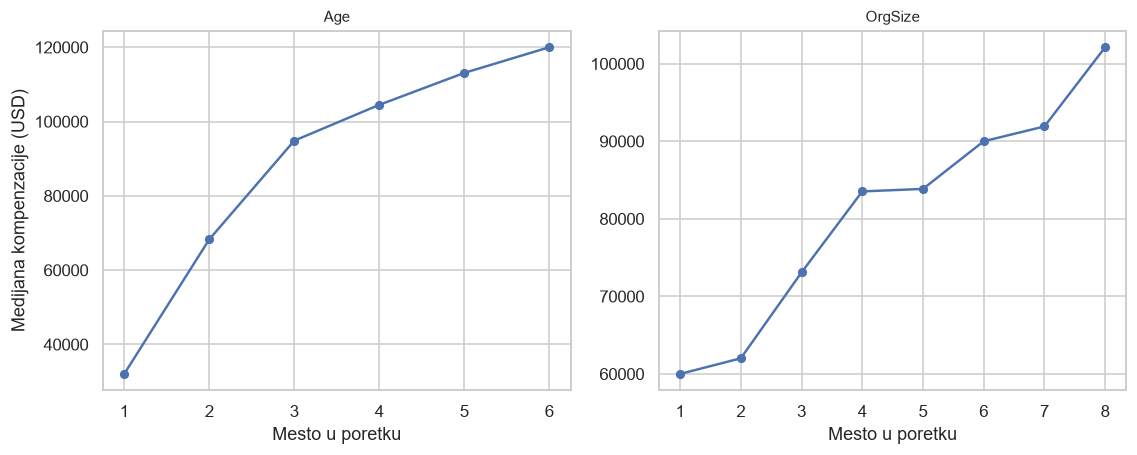

Age: korak od kategorije do kategorije, u dolarima
  +36,207, +26,579, +9,641, +8,598, +6,915
  najveći korak +36,207, najmanji +6,915, odnos 5.2 puta

OrgSize: korak od kategorije do kategorije, u dolarima
  +2,015, +11,074, +10,442, +326, +6,143, +1,909, +10,215
  najveći korak +11,074, najmanji +326, odnos 34.0 puta



In [47]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))
for ax, column in zip(axes, ORDERED):
    real = [v for v in train[column].dropna().unique() if v != NOT_ANSWERED]
    order = sorted(real, key=band_start)
    medians = [train.loc[train[column] == value, TARGET].median() for value in order]
    ax.plot(range(1, len(order) + 1), medians, marker="o", markersize=5,
            linewidth=1.6, color="#4C72B0")
    ax.set_title(column, fontsize=10)
    ax.set_xlabel("Mesto u poretku")
    ax.set_xticks(range(1, len(order) + 1))
axes[0].set_ylabel("Medijana kompenzacije (USD)")
plt.tight_layout()
plt.show()

for column in ORDERED:
    real = [v for v in train[column].dropna().unique() if v != NOT_ANSWERED]
    order = sorted(real, key=band_start)
    medians = np.array([train.loc[train[column] == value, TARGET].median() for value in order])
    steps = np.diff(medians)
    print(f"{column}: korak od kategorije do kategorije, u dolarima")
    print(f"  {', '.join(f'{s:+,.0f}' for s in steps)}")
    print(f"  najveći korak {steps.max():+,.0f}, najmanji {steps.min():+,.0f}, "
          f"odnos {abs(steps.max() / steps.min()):.1f} puta")
    print()

**Zapažanje:** Dve krive izgledaju bitno drugačije. Kod uzrasta je prvi korak **+36.207 dolara**, a
poslednji **+6.915** — razlika od **5,2 puta**; kriva strmo raste pa se poravna. Kod veličine firme koraci
idu od +326 do +11.074, dakle razlika je čak veća po odnosu (34 puta), ali su skokovi raspoređeni po celoj
krivoj umesto da budu skoncentrisani na jednom kraju.

**Tumačenje:** Ovo objašnjava zašto brojevi ispadaju kako ispadaju. Ordinalno kodiranje povlači **pravu
liniju kroz mesta u poretku**. Kod veličine firme ta prava prolazi blizu svih tačaka, jer se plata penje
prilično ravnomerno od najmanje ka najvećoj firmi. Kod uzrasta prava ne može da isprati skok od tridesetak
hiljada dolara na početku i zaravnjenje na kraju — pa gubi taman toliko koliko smo izmerili.

Odnos najvećeg i najmanjeg koraka pri tome **nije** merilo — kod `OrgSize` je čak
veći. Bitno je gde su ti koraci: kod uzrasta je razlika sistematska, od velikih ka malim, a kod veličine
firme su nepravilno raspoređeni pa se u proseku ponište.

In [48]:
# Section 8.4 applied: the dummy columns become one ordered number. The order
# is the one worked out above, and it is kept so the test set can be given the
# same one. The width before the change is taken first, to show what it saves.
dummy_width_before = train["OrgSize"].nunique() - 1
train["OrgSize"] = ordinal_versions["OrgSize"].astype(float)

print(f"OrgSize je sada {train['OrgSize'].dtype}, vrednosti od "
      f"{train['OrgSize'].min():.0f} do {train['OrgSize'].max():.0f}")
print(f"kolona koje daje pri enkodiranju: {dummy_width_before} -> 1")
print(f"kolona u tabeli: {train.shape[1]}   "
      f"(broj se ne menja, menja se sadržaj jedne)")

OrgSize je sada float64, vrednosti od 1 do 8
kolona koje daje pri enkodiranju: 8 -> 1
kolona u tabeli: 448   (broj se ne menja, menja se sadržaj jedne)


### 8.5 Promenljive izvedene iz onoga što već imamo

Sve dosad smo promenljive izvlačili iz kolona koje su bile u neupotrebljivom obliku. Ovde probamo nešto
drugo: **promenljivu koja se računa iz kolona koje već imamo i koje su već u modelu.**

Nijedna od njih nije nov podatak iz ankete. Obe se dobijaju oduzimanjem dve postojeće kolone:

| nova promenljiva | računa se kao | šta bi trebalo da meri |
| --- | --- | --- |
| `YearsBeforeWork` | `YearsCode − WorkExp` | koliko je godina programirao pre prvog posla |
| `ToolGapWorkPersonal` | `ToolCountWork − ToolCountPersonal` | koliko mu je radni alat širi od privatnog |

Sve četiri kolone sa desne strane — `YearsCode`, `WorkExp`, `ToolCountWork` i `ToolCountPersonal` —
nasleđene su iz čišćenja i **već su u modelu**. Za nekoga ko programira petnaest godina a radi pet,
`YearsBeforeWork` je 10; to bi mogle biti godine školovanja ili samostalnog učenja pre ulaska u struku.

Obe merimo kao i sve ostalo. Ali uz merenje ide i provera koju smo uveli u sekciji 6 — da li je nova
kolona **tačna kombinacija** onih koje već imamo. Kod razlike dve postojeće kolone to pitanje je ozbiljno.

In [49]:
derived = pd.DataFrame({
    "YearsBeforeWork": train["YearsCode"] - train["WorkExp"],
    "ToolGapWorkPersonal": train["ToolCountWork"] - train["ToolCountPersonal"],
}, index=train.index).astype(float)

measured_derived = signal_table({name: derived[name] for name in derived.columns})
show(measured_derived)
print()

# Both are differences of columns the model already has, so the check from
# section 6 has something to say about them.
check = pd.concat([train[["YearsCode", "WorkExp", "ToolCountWork",
                          "ToolCountPersonal"]].astype(float), derived], axis=1)
keep, dropped = independent_columns(check)
print(f"uz četiri postojeće kolone iz kojih su izvedene, zavisnih: {len(dropped)}   {dropped}")

                          n kolona      R      R2 R2_prilag        p raspon_puta
ToolGapWorkPersonal  14,608      1  0.146  0.0212    0.0211  4.5e-70        13.1
YearsBeforeWork      14,608      1  0.136  0.0186    0.0185  1.9e-61         7.3

uz četiri postojeće kolone iz kojih su izvedene, zavisnih: 2   ['ToolGapWorkPersonal', 'WorkExp']


**Zapažanje:** Obe promenljive same za sebe nisu slabe — `ToolGapWorkPersonal` ima prilagođeni R² od
**0,0211**, `YearsBeforeWork` **0,0185**, obe značajne i obe iznad donje granice iz 2.1.

Ali provera zavisnosti kaže drugo. Kad se te dve stave uz četiri kolone iz kojih su izvedene, od šest
kolona **dve su suvišne**. Koje dve — nije jednoznačno, i ispis to i pokazuje: izbačeni su
`ToolGapWorkPersonal` i `WorkExp`, iako je moglo i obrnuto. Svejedno je da li se ukloni razlika ili jedna
od kolona iz kojih je nastala, jer nose istu informaciju.

**Tumačenje:** To je bilo neizbežno, i razlog je jednostavan. `YearsBeforeWork` je po definiciji
`YearsCode − WorkExp`, a obe te kolone već su u modelu. Linearna regresija sabira i oduzima svoje kolone
sa težinama koje sama bira — pa razliku dve kolone, ako su obe već tu, **model može da napravi sam**.
Dodavanjem te razlike ne dajemo mu nijedan podatak koji nije imao, samo isti podatak treći put.

Zato je prilagođeni R² od 0,0211 obmanjujuć: on kaže koliko ta razlika objašnjava **sama za sebe**, a ne
koliko dodaje modelu. To je najoštriji primer razlike između te dve stvari na koji smo naišli — promenljiva
koja samostalno izgleda pristojno, a u modelu ne vredi ništa, i to ne malo nego tačno ništa.

**Odluka: nijednu ne pravimo.** Iz istog razloga ne pravimo ni druge razlike ili zbirove postojećih
kolona. Kombinacija koja **jeste** nova je ona koju linearni model ne može sam da sastavi — odnos dve
kolone ili njihov proizvod, dakle interakcija, o kojoj smo učili na predavanjima. To je, međutim, odluka
o obliku modela a ne o podacima, pa joj je mesto u fazi modelovanja, gde se bira i sam model.

### 8.6 Šta zadržavamo

Sekcija je donela pet odluka i sve su izmerene:

- **`EmploymentAddl`** prestaje da bude kategorijska kolona sa 97 vrednosti i postaje **devet binarnih
  kolona**; puna kategorija bi dala +0,0054 umesto +0,0021, ali za 87 kolona više;
- **`Currency` ostaje netaknuta**, iako nosi 97 kolona, jer preko zemlje dodaje +0,0272;
- **`OrgSize` prelazi na ordinalno kodiranje**, jedna kolona umesto osam;
- **`Age` ostaje u dummy obliku**, jer bi ordinalno kodiranje izgubilo 0,0372;
- **izvedene razlike se ne prave**, jer ih linearni model može sam da sastavi.

In [50]:
# Both changes are already applied, each in its own subsection; what is left
# is to put the state before and after the section side by side.
categorical_now = sum(1 for c in train.columns
                      if c not in (TARGET, TARGET_LOG) and is_text(train[c]))
encoded_now = sum(train[c].nunique() - 1 for c in train.columns
                  if c not in (TARGET, TARGET_LOG) and is_text(train[c]))

print(f"{'':<34} {'pre sekcije':>12} {'posle':>7}")
print(f"{'kolona u tabeli':<34} {columns_before_section8:>12} {train.shape[1]:>7}")
print(f"{'kategorijskih kolona':<34} {categorical_before_section8:>12} {categorical_now:>7}")
print(f"{'kolona koje bi enkodiranje dalo':<34} {encoded_before_section8:>12} {encoded_now:>7}")
print()
print(f"dodato po stavci iz EmploymentAddl: +{len(kept_extra)}")
print(f"izbačeno kategorijskih kolona:      -{len(missed)}")
print(f"OrgSize: osam dummy kolona zamenjeno jednom brojčanom, "
      f"vrednosti od {train['OrgSize'].min():.0f} do {train['OrgSize'].max():.0f}")

                                    pre sekcije   posle
kolona u tabeli                             440     448
kategorijskih kolona                         35      33
kolona koje bi enkodiranje dalo             435     331

dodato po stavci iz EmploymentAddl: +9
izbačeno kategorijskih kolona:      -1
OrgSize: osam dummy kolona zamenjeno jednom brojčanom, vrednosti od 1 do 8


### Šta sekcija ostavlja sledećoj

Skup je posle svih izmena **manji nego što je bio u kolonama koje idu u model**, iako je broj kolona u
tabeli porastao. Razlog je što se kategorijska kolona sa 97 vrednosti pretvorila u devet binarnih, a
kolona sa osam kategorija u jednu brojčanu — a to se vidi tek kad se prebroji koliko kolona sve zajedno
daje pri enkodiranju.

Četiri nalaza se prenose dalje:

- **prag iz sekcije 3 je propustio jednu multi-select kolonu**, i ta kolona je ispala jedna od korisnijih
  u notebook-u. Postupak koji smo tada koristili nije bio pogrešan, ali jeste bio nepotpun bez naknadne
  provere;
- **valuta nije ponavljanje zemlje** — dodaje četiri puta više od tipičnog anketnog obeležja, jer razlikuje
  onoga ko je u istoj zemlji plaćen u stranoj valuti;
- **poredak nije dovoljan uslov za ordinalno kodiranje.** Mora biti i ravnomeran, što je kod veličine
  firme slučaj a kod uzrasta nije;
- **razlika dve kolone koje već imamo nije nova promenljiva.** Linearni model je pravi sam, pa je dodavanje
  samo ponavljanje — bez obzira na to kako izgleda kad se meri samostalno.

Ostaje još da se ceo skup pogleda kao celina: koliko se promenljive međusobno preklapaju i da li je nešto
od onoga što smo napravili suvišno pored ostalog. Time se bavi sekcija 9.

## 9. Ceo skup kao celina

Osam sekcija je pravilo promenljive, svaku merilo posebno i svaku branilo svojim kriterijumom. Ostaju dva
pitanja koja se ne mogu postaviti dok se ne završi sve ostalo.

**Koliko je svaka sekcija zapravo donela?** Do sada smo svaki put merili prirast prema stanju u tom
trenutku, ali to nikad nije bilo sabrano.

**Da li se promenljive međusobno preklapaju?** Napravili smo ih preko tri stotine, i to iz istih izvornih
kolona. Da neka od njih ponavlja drugu, to bi bila kolinearnost o kojoj smo učili, i merimo je VIF-om.

### 9.1 Koliko kolona model zapravo ima

Pre svega treba razjasniti jednu razliku koja se do sada podrazumevala, a od ove sekcije postaje bitna:
**broj kolona u tabeli nije broj kolona u modelu.**

U tabeli `train` svaka promenljiva zauzima jedno mesto, pa i `Country`, iako u sebi ima 62 različite
vrednosti. Ali regresija ne ume da radi sa tekstom — kategorijska promenljiva u nju ulazi kao **dummy
kolone, po jedna za svaku kategoriju osim jedne**, kao što smo učili na predavanjima. Tako jedna kolona
tabele postaje 61 kolona modela.

Kod brojčanih promenljivih razlike nema: jedna kolona tabele je jedna kolona modela. Zato se dva broja
razilaze samo onoliko koliko imamo kategorijskih promenljivih sa mnogo vrednosti — a imamo `Currency` sa
98, `Country` sa 62, `DevType` sa 32.

Ispis ispod prvo prikazuje to razilaženje, pa tek onda meri koliko je koja sekcija donela.

In [51]:
def dummies_for(columns):
    """Categorical columns turned into dummy variables, numeric ones left alone."""
    parts = []
    for column in columns:
        if is_text(train[column]):
            parts.append(pd.get_dummies(train[column].astype(str), prefix=column,
                                        drop_first=True, dtype=float))
        else:
            parts.append(train[[column]].astype(float))
    return pd.concat(parts, axis=1) if parts else pd.DataFrame(index=train.index)


# Indicators made in section 4, one per multi-select question, as opposed to the
# ones inherited from the cleaning notebook.
questions_indicators = [ANSWERED_PREFIX + name for name in questions
                        if ANSWERED_PREFIX + name in train.columns]

# The same reading as in 8.1, except OrgSize is a number by now.
inherited_numeric = [c for c in train.columns
                     if c not in (TARGET, TARGET_LOG) and train[c].dtype.kind in "if"
                     and not c.startswith((COUNT_PREFIX, KEPT_PREFIX, ANSWERED_PREFIX,
                                           ITEM_PREFIX))
                     and not RANK_NAME.fullmatch(c)]
inherited_indicators = [c for c in train.columns
                        if c.startswith(ANSWERED_PREFIX) and c not in questions_indicators]
inherited_categorical = [c for c in train.columns
                         if is_text(train[c]) and c not in (TARGET, TARGET_LOG)
                         and c != "Country"]

blocks = {
    "zemlja i staž": dummies_for(["Country", "WorkExp"]),
    "ostale nasleđene kolone": dummies_for([c for c in inherited_categorical]
                                           + [c for c in inherited_numeric if c != "WorkExp"]
                                           + inherited_indicators),
    "brojevi izabranih stavki (4)": train[[c for c in train.columns
                                           if c.startswith((COUNT_PREFIX, KEPT_PREFIX))]
                                          + questions_indicators].astype(float),
    "pojedinačne stavke (5 i 8)": train[[c for c in train.columns
                                         if c.startswith(ITEM_PREFIX)]].astype(float),
    "rangiranja (6)": train[kept_ranks].astype(float),
}

def build_up(order):
    """Adjusted R² after each block is added, in the order given."""
    running, result, previous = [], [], None
    for label in order:
        running.append(blocks[label])
        design = pd.concat(running, axis=1)
        keep, _ = independent_columns(design)
        model = sm.OLS(train[TARGET_LOG].to_numpy(),
                       sm.add_constant(design[keep], has_constant="add").to_numpy()).fit()
        result.append((label, blocks[label].shape[1], model.rsquared_adj,
                       None if previous is None else model.rsquared_adj - previous))
        previous = model.rsquared_adj
    return result


predictors_now = [c for c in train.columns if c not in (TARGET, TARGET_LOG)]
text_now = [c for c in predictors_now if is_text(train[c])]
print("kolona u tabeli naspram kolona u modelu:")
print(f"  prediktora u tabeli:            {len(predictors_now)}")
print(f"    od toga brojčanih:            {len(predictors_now) - len(text_now)}   "
      f"(svaka daje jednu kolonu modela)")
print(f"    od toga kategorijskih:        {len(text_now)}   "
      f"(svaka daje onoliko kolona koliko ima kategorija, manje jednu)")
print()
print("  najveće kategorijske i koliko kolona daju:")
for column in sorted(text_now, key=lambda c: -train[c].nunique())[:4]:
    print(f"    {column:<16} {train[column].nunique():>3} kategorija -> {train[column].nunique() - 1:>3} kolona")
expansion = sum(train[c].nunique() - 1 for c in text_now)
print(f"    ostale {len(text_now) - 4} kategorijske zajedno -> "
      f"{expansion - sum(train[c].nunique() - 1 for c in sorted(text_now, key=lambda c: -train[c].nunique())[:4])} kolona")
print(f"  ukupno kolona u modelu:         "
      f"{len(predictors_now) - len(text_now) + expansion}")
print()

running, previous = [], None
for label, block in blocks.items():
    running.append(block)
    design = pd.concat(running, axis=1)
    keep, _ = independent_columns(design)
    model = sm.OLS(train[TARGET_LOG].to_numpy(),
                   sm.add_constant(design[keep], has_constant="add").to_numpy()).fit()
    gain = "" if previous is None else f"{model.rsquared_adj - previous:>+9.4f}"
    print(f"{label:<30} {block.shape[1]:>5} kolona   prilagođeni={model.rsquared_adj:.4f} {gain}")
    previous = model.rsquared_adj

full_design = pd.concat(running, axis=1)
print()
print(f"ukupno kolona u modelu: {full_design.shape[1]}")
print(f"redova po koloni:       {len(train) / full_design.shape[1]:.0f}")
print()

# What each block gets depends on what is already in the model, so the same
# blocks are added once more in the opposite order.
made_here = ["brojevi izabranih stavki (4)", "pojedinačne stavke (5 i 8)", "rangiranja (6)"]
inherited_blocks = ["zemlja i staž", "ostale nasleđene kolone"]
reverse = build_up(["zemlja i staž"] + made_here + ["ostale nasleđene kolone"])

print("isti blokovi, obrnutim redom:")
for label, size, value, gain in reverse:
    shown = "" if gain is None else f"{gain:>+9.4f}"
    print(f"  {label:<30} {size:>5} kolona   prilagođeni={value:.4f} {shown}")

forward = build_up(list(blocks))
made_forward = sum(g for l, _, _, g in forward if l in made_here and g is not None)
made_reverse = sum(g for l, _, _, g in reverse if l in made_here and g is not None)
print()
print(f"ono što smo napravili u ovom notebook-u dobija {made_forward:+.4f} kad se dodaje poslednje,")
print(f"a {made_reverse:+.4f} kad se dodaje pre ostalih nasleđenih kolona")

kolona u tabeli naspram kolona u modelu:
  prediktora u tabeli:            446
    od toga brojčanih:            413   (svaka daje jednu kolonu modela)
    od toga kategorijskih:        33   (svaka daje onoliko kolona koliko ima kategorija, manje jednu)

  najveće kategorijske i koliko kolona daju:
    Currency          98 kategorija ->  97 kolona
    Country           62 kategorija ->  61 kolona
    DevType           32 kategorija ->  31 kolona
    Industry          16 kategorija ->  15 kolona


    ostale 29 kategorijske zajedno -> 127 kolona
  ukupno kolona u modelu:         744



zemlja i staž                     62 kolona   prilagođeni=0.5763 


ostale nasleđene kolone          284 kolona   prilagođeni=0.6812   +0.1049


brojevi izabranih stavki (4)      48 kolona   prilagođeni=0.6860   +0.0048


pojedinačne stavke (5 i 8)       314 kolona   prilagođeni=0.7028   +0.0168


rangiranja (6)                    36 kolona   prilagođeni=0.7079   +0.0051

ukupno kolona u modelu: 744
redova po koloni:       20



isti blokovi, obrnutim redom:
  zemlja i staž                     62 kolona   prilagođeni=0.5763 
  brojevi izabranih stavki (4)      48 kolona   prilagođeni=0.6032   +0.0269
  pojedinačne stavke (5 i 8)       314 kolona   prilagođeni=0.6431   +0.0399
  rangiranja (6)                    36 kolona   prilagođeni=0.6513   +0.0082
  ostale nasleđene kolone          284 kolona   prilagođeni=0.7079   +0.0566



ono što smo napravili u ovom notebook-u dobija +0.0267 kad se dodaje poslednje,
a +0.0750 kad se dodaje pre ostalih nasleđenih kolona


**Zapažanje:** U tabeli je **446 prediktora**, ali u modelu **744 kolone**. Razlika dolazi od 33
kategorijske promenljive: `Currency` sama daje 97 kolona, `Country` 61, `DevType` 31, `Industry` 15, a
ostalih 29 zajedno 127. Brojčanih promenljivih je 413 i svaka daje po jednu kolonu.

Na 14.608 redova to znači **20 redova po jednoj koloni modela** — dakle svaki koeficijent koji model
procenjuje oslanja se u proseku na dvadesetak ispitanika.

Konačan model ima **prilagođeni R² od 0,7079**, a evo kako se do njega dolazi kad se blokovi dodaju redom
kojim su nastajali:

| blok | kolona | prilagođeni R² | prirast |
| --- | --- | --- | --- |
| zemlja i staž | 62 | 0,5763 | — |
| ostale nasleđene kolone | 284 | 0,6812 | +0,1049 |
| brojevi izabranih stavki (4) | 48 | 0,6860 | +0,0048 |
| pojedinačne stavke (5 i 8) | 314 | 0,7028 | +0,0168 |
| rangiranja (6) | 36 | 0,7079 | +0,0051 |

**Tumačenje:** Dvadeset redova po koloni je malo. Taj odnos je broj redova podeljen brojem kolona modela, i kaže koliko ispitanika u proseku stoji iza jednog koeficijenta koji se procenjuje — što je manji, na tim se manje ljudi svaki koeficijent oslanja. To je isti odnos koji nas je zabrinjavao u sekciji 5 i
razlog zbog kog u modelovanju Ridge i Lasso nisu opcioni — kad model ima toliko kolona, obična regresija
lako nauči slučajne razlike umesto stvarnih.

Sam rezultat je ipak dobar. Sedamdeset odsto varijanse logaritmovane plate, i to iz jedne ankete, je
znatno više od 0,5544 koliko daje sama zemlja i mnogo više nego što bi se očekivalo posle sekcije 2, gde
nijedno pojedinačno obeležje nije prelazilo 0,16.

**Zapažanje uz obrnut redosled:** Isti blokovi, dodati obrnutim redom, daju sasvim druge priraste. Ono što
smo napravili u ovom notebook-u dobija **+0,0267 kad se dodaje poslednje**, a **+0,0750 kad se dodaje pre
nasleđenih kolona**. Nasleđene kolone istovremeno padaju sa +0,1049 na +0,0566. Krajnji rezultat je u oba
slučaja **isti — 0,7079**.

**Tumačenje:** Ovo na prvi pogled deluje kao protivrečnost, a nije. Prirast nije osobina bloka nego
**osobina bloka i onoga što je već u modelu**.

Primer koji to objašnjava: i valuta i broj izabranih tehnologija delom govore o tome koliko je razvijeno
tržište na kom neko radi. Taj zajednički deo objasniće **onaj blok koji uđe prvi**, a drugi će dobiti samo
ono što je preostalo. Zajednički deo, dakle, ne pripada ni jednom ni drugom bloku pojedinačno — pripada
obojici, a redosled odlučuje ko će ga u tabeli dobiti.

Zato zbir mora biti isti bez obzira na redosled: ista informacija je u modelu, samo drugačije raspoređena
po redovima tabele.

Praktična posledica je da **nijedan od ta dva broja nije „pravi" doprinos ovog notebook-a**. Pošten opseg
je između njih: od +0,0267 do +0,0750, dakle od četiri do deset puta više od onoga što donese tipično
anketno pitanje. Zato prikazujemo oba redosleda umesto da izaberemo povoljniji.

### 9.2 Koliko se promenljive međusobno preklapaju

Sa predavanja znamo da kolinearnost ne kvari predviđanja modela ali kvari **koeficijente**: kad dve
kolone nose skoro istu informaciju, model ne može da razluči koliko pripada kojoj, pa im koeficijenti
postaju nestabilni i nečitljivi. Na predavanjima smo uz to izričito učili da se kolinearnost između tri i
više promenljivih **ne vidi u matrici korelacije parova** i da uvek treba proveriti VIF.

Kod nas je razlog za sumnju konkretan. Iz istog pitanja smo izveli i broj izabranih stavki i pojedinačne
stavke — a broj izabranih stavki je zbir tih pojedinačnih. Ako su sve stavke jednog pitanja zadržane, taj
zbir bi bio tačna kombinacija; nije se desilo, ali je blizu.

VIF za jednu kolonu dobija se tako što se ona regresuje na sve ostale, pa je `VIF = 1 / (1 − R²)`. Ako
kolona sa ostalima nema nikakve veze, R² je nula i VIF je **1**; ako je ostale objašnjavaju napola, VIF je
2; ako je objašnjavaju 90%, VIF je 10. Pragovi su oni sa predavanja: **1** znači da preklapanja nema,
**5 do 10** umereno, **preko 10** ozbiljno.

Sa preko sedam stotina kolona to bi značilo sedam stotina modela, pa koristimo poznatu prečicu: isti
brojevi stoje na **dijagonali inverzne matrice korelacije**, koja se računa jednom.

Ispis prikazuje **celu raspodelu po grupama promenljivih**, a ne samo najgore vrednosti — jer je za odluku
jednako važno koliko je kolona čisto koliko i koliko ih je sporno.

In [52]:
def variance_inflation(design):
    """VIF for every column at once.

    Regressing each column on all the others would mean one model per column;
    the same numbers stand on the diagonal of the inverted correlation matrix.
    """
    correlation = np.corrcoef(design.to_numpy(dtype=float), rowvar=False)
    return pd.Series(np.diag(np.linalg.inv(correlation)), index=design.columns)


# Columns that never change carry no correlation at all and would break the
# matrix; with an exact combination among the rest it could not be inverted.
varying = [c for c in full_design.columns if full_design[c].nunique() > 1]
independent, dependent = independent_columns(full_design[varying])
print(f"kolona u modelu: {full_design.shape[1]}   "
      f"bez konstantnih: {len(varying)}   bez zavisnih: {len(independent)}")

vif = variance_inflation(full_design[independent]).sort_values(ascending=False)

vif_groups = {
    "kolone po stavci  Chose_": [c for c in vif.index if c.startswith(ITEM_PREFIX)],
    "brojevi stavki    Count_": [c for c in vif.index if c.startswith(COUNT_PREFIX)],
    "odnos zadržanog   KeptShare_": [c for c in vif.index if c.startswith(KEPT_PREFIX)],
    "indikatori        NotAnswered_": [c for c in vif.index if c.startswith(ANSWERED_PREFIX)],
    "rangiranja": [c for c in vif.index if c in kept_ranks],
    "nasleđene brojčane": [c for c in vif.index if c in inherited_numeric],
}
covered = {c for columns in vif_groups.values() for c in columns}
vif_groups["dummy kolone kategorijskih"] = [c for c in vif.index if c not in covered]

# The bands the lectures use to read a VIF: one means no overlap, five to ten
# moderate, above ten serious.
BANDS = [(1, 2, "1-2"), (2, 5, "2-5"), (5, 10, "5-10"), (10, np.inf, "> 10")]

print()
print(f"{'grupa':<32} {'kolona':>7} " + " ".join(f"{name:>6}" for _, _, name in BANDS)
      + f" {'medijana':>9} {'najveći':>9}")
for label, columns in vif_groups.items():
    values = vif[columns]
    counts = " ".join(f"{int(((values >= low) & (values < high)).sum()):>6}"
                      for low, high, _ in BANDS)
    print(f"{label:<32} {len(columns):>7} {counts} {values.median():>9.2f} {values.max():>9.1f}")

# Everything except the dummy columns, i.e. the variables this notebook made
# plus the plain numeric ones it inherited.
engineered = [c for c in vif.index if c not in vif_groups["dummy kolone kategorijskih"]]

print()
print("pet najvećih i pet najmanjih među promenljivama koje smo napravili:")
edges = pd.concat([vif[engineered].head(5), vif[engineered].tail(5)])
print(edges.round(2).to_string())

kolona u modelu: 744   bez konstantnih: 744   bez zavisnih: 742

grupa                             kolona    1-2    2-5   5-10   > 10  medijana   najveći
kolone po stavci  Chose_             314    160    142     12      0      1.97       9.6
brojevi stavki    Count_              27      0      4     12     11      9.59     182.2
odnos zadržanog   KeptShare_           7      0      5      2      0      4.47       5.6
indikatori        NotAnswered_        23      3      6      6      8      8.82     253.7
rangiranja                            36     33      3      0      0      1.66       2.2
nasleđene brojčane                     6      4      0      2      0      1.58       9.0
dummy kolone kategorijskih           329     99     79     55     96      4.06    1758.1

pet najvećih i pet najmanjih među promenljivama koje smo napravili:
NotAnswered_LearnCode                             253.70
Count_AIToolDon't plan to use AI for this task    182.17
Count_CommPlatformWantToWorkWith        

**Zapažanje:** Raspodela je vrlo različita od grupe do grupe.

| grupa | kolona | VIF 1–2 | 2–5 | 5–10 | > 10 | medijana | najveći |
| --- | --- | --- | --- | --- | --- | --- | --- |
| kolone po stavci `Chose_` | 314 | 160 | 142 | 12 | **0** | 1,97 | 9,6 |
| brojevi stavki `Count_` | 27 | 0 | 4 | 12 | **11** | 9,59 | 182,2 |
| odnos zadržanog `KeptShare_` | 7 | 0 | 5 | 2 | 0 | 4,47 | 5,6 |
| indikatori `NotAnswered_` | 23 | 3 | 6 | 6 | **8** | 8,82 | 253,7 |
| rangiranja | 36 | 33 | 3 | 0 | 0 | 1,66 | 2,2 |
| nasleđene brojčane | 6 | 4 | 0 | 2 | 0 | 1,58 | 9,0 |
| dummy kolone kategorijskih | 329 | 99 | 79 | 55 | **96** | 4,06 | 1758,1 |

**Tumačenje:** Dve grupe koje smo pravili su gotovo besprekorne, a dve su problematične, i razlika među
njima ima isti uzrok.

**Kolone po stavci i rangiranja su čiste.** Kod stavki je medijana 1,97 — dakle tipična kolona po stavci
sa svim ostalima deli oko polovine varijanse, što je za 744 kolone malo — i **nijedna od 314 ne prelazi
10**. Kod rangiranja je još bolje: medijana 1,66, najveći 2,2. Obe grupe imaju istu osobinu: svaka njihova
kolona govori o **jednoj stavci**, a ne o celom pitanju.

**Brojevi i indikatori nisu.** Kod `Count_` je medijana 9,59, a jedanaest od 27 kolona prelazi 10; kod
indikatora osam od 23. Obe grupe govore o **celom pitanju** — koliko je stavki izabrano, odnosno da li je
pitanje uopšte odgovoreno — a to isto već nose sve kolone po stavci tog pitanja zajedno.

To je usput i objašnjenje zašto ovo preklapanje nismo mogli da vidimo ranije: u sekciji 4, kad su brojevi
i indikatori napravljeni, kolona po stavci još nije bilo.

Kod dummy kolona je slika najgora, ali je te prirode da se ne može popraviti — tome se vraćamo u 9.3.

### Grafik 10 — odakle preklapanje dolazi

**Motivacija:** VIF je jedan broj po koloni i kaže **koliko** se ona preklapa sa svim ostalima, ali ne i
**sa kojima**. Bez toga se ne zna šta uraditi: ako se kolona preklapa sa dvadeset drugih pomalo, to je
druga situacija nego ako je skoro tačno određena jednom grupom kolona.

Zato uzimamo kolonu sa najvećim VIF-om i gledamo **sve promenljive izvedene iz istog pitanja** — indikator
neodgovaranja, broj izabranih stavki i pojedinačne stavke. Crtamo njihove međusobne korelacije kao mapu, u
kojoj je svako polje korelacija dve promenljive: crveno znači da rastu zajedno, plavo da jedna raste kad
druga opada, a belo da veze nema. Ako je uzrok onaj koji smo pretpostavili u 9.2, videće se kao pravilna
struktura — cela vrsta i cela kolona iste boje — a ne kao nasumične mrlje.

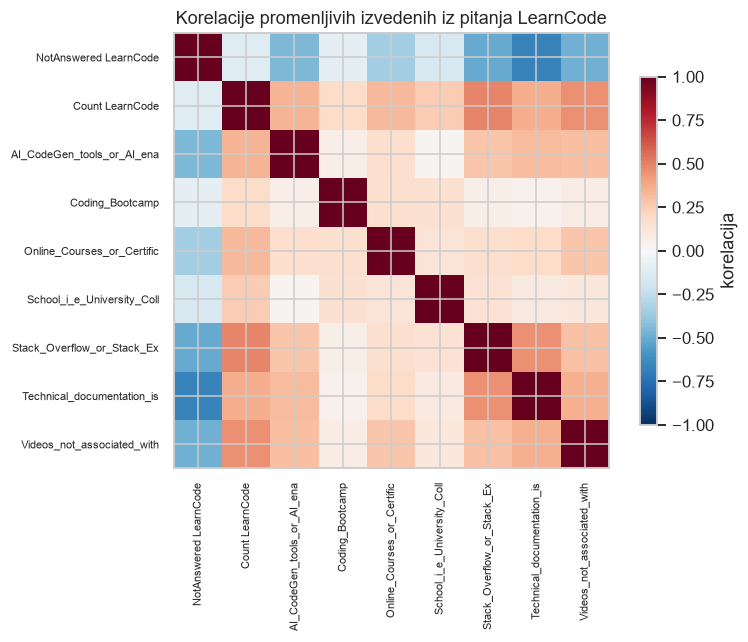

kolona sa najvećim VIF-om: NotAnswered_LearnCode  (253.7)
pitanje iz kog su sve ove promenljive izvedene: LearnCode

korelacija indikatora sa brojem izabranih stavki: -0.122
korelacija indikatora sa pojedinačnim stavkama: od -0.671 do -0.093
stavki iz tog pitanja u modelu: 7 od 13 ponuđenih


In [53]:
worst = vif[engineered].idxmax()
question = worst.replace(ANSWERED_PREFIX, "")
family = ([ANSWERED_PREFIX + question, COUNT_PREFIX + question]
          + [c for c in train.columns if c.startswith(f"{ITEM_PREFIX}{question}__")])
family = [c for c in family if c in train.columns]

labels = [c.replace(f"{ITEM_PREFIX}{question}__", "").replace(ANSWERED_PREFIX, "NotAnswered ")
          .replace(COUNT_PREFIX, "Count ")[:26] for c in family]
correlation = train[family].astype(float).corr()

fig, ax = plt.subplots(figsize=(7.5, 6))
image = ax.imshow(correlation.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(family)))
ax.set_xticklabels(labels, rotation=90, fontsize=7.5)
ax.set_yticks(range(len(family)))
ax.set_yticklabels(labels, fontsize=7.5)
ax.set_title(f"Korelacije promenljivih izvedenih iz pitanja {question}")
fig.colorbar(image, ax=ax, shrink=0.8, label="korelacija")
plt.tight_layout()
plt.show()

indicator = correlation.loc[ANSWERED_PREFIX + question].drop(ANSWERED_PREFIX + question)
print(f"kolona sa najvećim VIF-om: {worst}  ({vif[worst]:.1f})")
print(f"pitanje iz kog su sve ove promenljive izvedene: {question}")
print()
print(f"korelacija indikatora sa brojem izabranih stavki: "
      f"{correlation.loc[ANSWERED_PREFIX + question, COUNT_PREFIX + question]:.3f}")
print(f"korelacija indikatora sa pojedinačnim stavkama: od {indicator.min():.3f} "
      f"do {indicator.max():.3f}")
print(f"stavki iz tog pitanja u modelu: "
      f"{sum(1 for c in family if c.startswith(ITEM_PREFIX))} "
      f"od {len(vocabulary[question])} ponuđenih")

**Zapažanje:** Mapa ima pravilnu strukturu, ne nasumičnu. Prva vrsta i prva kolona pripadaju indikatoru
neodgovaranja i **plave su prema svim stavkama** — dakle indikator raste tačno kad stavke opadaju, sa
korelacijama od **−0,671 do −0,093**. Sa brojem izabranih stavki indikator je korelisan sa −0,122.

Ostatak mape, gde se stavke porede međusobno, uglavnom je bled — pojedinačne stavke se međusobno slabo
preklapaju.

Ispis dodaje i podatak koji objašnjava zašto veza nije još jača: iz tog pitanja je u modelu **7 od 13
ponuđenih stavki**.

**Tumačenje:** Ovo potvrđuje ono što je VIF nagovestio, i pokazuje tačan mehanizam.

Indikator kaže „ovaj ispitanik nije odgovorio na pitanje". Kolone po stavci to iste govore zajedno: ko nije
odgovorio ima **nulu u svakoj od njih**. Zato je indikator negativno korelisan sa svakom stavkom
pojedinačno, i zato mu VIF ispada 253,7 — ne zato što ga jedna kolona ponavlja, nego zato što ga sedam
kolona zajedno gotovo tačno određuje.

Da su sve stavke bile zadržane, veza bi bila **tačna**, a ne samo jaka: indikator bi bio jedinica tačno
kad su sve stavke nula. Pošto je zadržano sedam od trinaest, ostaje mogućnost da je neko odgovorio birajući
samo stavke koje nismo zadržali — pa je veza jaka ali ne i savršena.

Isti mehanizam objašnjava i zašto su kolone po stavci međusobno čiste. Nijedna od njih ne govori o celom
pitanju, pa se ni jedna ne može sastaviti od ostalih.

### 9.3 Šta radimo sa preklapanjem

Sa predavanja znamo dva rešenja za kolinearnost: **ukloniti jedan od kolinearnih prediktora** ili ih
**kombinovati**. Pre nego što bilo šta uklonimo, vredi razdvojiti dve vrste preklapanja koje smo izmerili,
jer se ne rešavaju isto.

**Kod dummy kolona preklapanje je ugrađeno.** Kolone jedne kategorijske promenljive po konstrukciji ne mogu
biti nezavisne — ako je ispitanik iz Nemačke, nije ni iz jedne od preostalih šezdeset zemalja. Visok VIF
tu ne znači da smo nešto pogrešili nego da promenljiva ima mnogo kategorija. Jedino „rešenje" bilo bi
izbaciti celu promenljivu, a to smo već merili u sekcijama 7 i 8 i odlučili drugačije.

**Kod promenljivih koje smo sami napravili preklapanje je naše delo**, i tu se može nešto uraditi. Zato
merimo koliko košta da se izbace one kod kojih je VIF preko granice koju smo učili na predavanjima.

In [54]:
# The threshold from the lectures: above ten the overlap counts as serious.
VIF_LIMIT = 10

overlapping = [c for c in engineered if vif[c] > VIF_LIMIT]
print(f"promenljivih koje smo napravili sa VIF preko {VIF_LIMIT}: {len(overlapping)}")
for prefix, label in [(COUNT_PREFIX, "Count_"), (ANSWERED_PREFIX, "NotAnswered_"),
                      (ITEM_PREFIX, "Chose_"), (KEPT_PREFIX, "KeptShare_")]:
    print(f"  {label:<14} {sum(1 for c in overlapping if c.startswith(prefix)):>3}")
print(f"  rangovi i nasleđene numeričke {sum(1 for c in overlapping if not c.startswith((COUNT_PREFIX, ANSWERED_PREFIX, ITEM_PREFIX, KEPT_PREFIX))):>3}")
print()

kept_after_vif = [c for c in independent if c not in overlapping]
with_all = sm.OLS(train[TARGET_LOG].to_numpy(),
                  sm.add_constant(full_design[independent], has_constant="add").to_numpy()).fit()
without_overlap = sm.OLS(train[TARGET_LOG].to_numpy(),
                         sm.add_constant(full_design[kept_after_vif],
                                         has_constant="add").to_numpy()).fit()

print(f"model sa svim kolonama:        prilagođeni={with_all.rsquared_adj:.4f}   "
      f"kolona={len(independent)}")
print(f"bez {len(overlapping)} sa VIF > {VIF_LIMIT}:          prilagođeni={without_overlap.rsquared_adj:.4f}   "
      f"kolona={len(kept_after_vif)}")
print(f"cena izbacivanja:              "
      f"{without_overlap.rsquared_adj - with_all.rsquared_adj:+.5f}")
print(f"dozvoljeni gubitak:            {typical_gain:.4f}")

promenljivih koje smo napravili sa VIF preko 10: 19
  Count_          11
  NotAnswered_     8
  Chose_           0
  KeptShare_       0
  rangovi i nasleđene numeričke   0



model sa svim kolonama:        prilagođeni=0.7079   kolona=742
bez 19 sa VIF > 10:          prilagođeni=0.7075   kolona=723
cena izbacivanja:              -0.00042
dozvoljeni gubitak:            0.0072


**Zapažanje:** VIF preko 10 ima **19 promenljivih koje smo napravili** — 11 brojeva izabranih stavki i 8
indikatora neodgovaranja. Nijedna kolona po stavci, nijedan odnos zadržanog i nijedan rang nisu među njima.

Izbacivanje tih 19 košta **0,00042** prilagođenog R², dakle model pada sa 0,7079 na 0,7075.

**Odluka: izbacujemo ih.** Cena je četiri desethiljadita dela, a dobija se devetnaest kolona manje i,
važnije, model u kome koeficijenti mogu da se čitaju.

**Tumačenje:** Treba biti precizan oko toga šta se ovim gubi, jer na prvi pogled deluje da izbacujemo
podatak o neodgovaranju — a upravo smo u sekciji 4 pokazali da je on vredan.

Ne gubimo ga. Grafik 10 je pokazao **zašto** su ti indikatori suvišni: isti podatak nose kolone po stavci,
jer ko na pitanje nije odgovorio ima nulu u svakoj od njih. Informacija ostaje u skupu, samo prestaje da
bude u njemu dvaput. Isto važi i za brojeve izabranih stavki, koji su zbir istih tih kolona.

Izbacujemo, pri tome, **isključivo po izmerenom VIF-u**, a ne po tome iz kog pitanja promenljiva
dolazi. Ispis posle izbacivanja pokazuje šta to znači: među indikatorima koji ostaju jesu i oni za
`WorkExp`, `JobSat` i za četiri rang-pitanja, koje zaista ništa drugo ne pokriva, ali i indikatori
nekoliko pitanja koja **imaju** kolone po stavci. Kod njih se preklapanje izmerilo ispod granice od
10, pa nemamo razlog da ih diramo. Pravilo je, dakle, izmerena vrednost, a ne vrsta promenljive.

**Kod dummy kolona ne radimo ništa.** Njihov VIF je posledica toga što kategorijska promenljiva sa mnogo
kategorija po konstrukciji ima međusobno zavisne kolone — ako je ispitanik iz Nemačke, nije ni iz jedne od
preostalih šezdeset zemalja, pa se te kolone nužno prate. Jedini način da se to ukloni je izbaciti celu
promenljivu, a to smo za `Country` i `EmploymentAddl` već merili i odlučili, dok smo za `Currency` u
sekciji 8 izmerili da vredi zadržati je uprkos ceni.

Sa predavanja znamo i da kolinearnost **ne kvari predviđanja** nego procenu pojedinačnih koeficijenata. Za
model koji predviđa platu to znači da preostali visok VIF kod dummy kolona ne smeta u onome što merimo na
test skupu — ali smeta ako budemo hteli da tumačimo pojedinačne koeficijente. Ridge regresija sa predavanja
postoji upravo za ovakav slučaj i u fazi modelovanja je prvi kandidat.

In [55]:
def model_width(frame):
    """How many columns the table would give a regression after encoding."""
    predictors = [c for c in frame.columns if c not in (TARGET, TARGET_LOG)]
    text = [c for c in predictors if is_text(frame[c])]
    return len(predictors) - len(text) + sum(frame[c].nunique() - 1 for c in text)


before_table, before_model = train.shape[1], model_width(train)
train = train.drop(columns=overlapping)

print(f"izbačeno kolona: {len(overlapping)}")
print()
print(f"{'':<26} {'pre':>8} {'posle':>8}")
print(f"{'kolona u tabeli':<26} {before_table:>8} {train.shape[1]:>8}")
print(f"{'kolona u modelu':<26} {before_model:>8} {model_width(train):>8}")
print(f"{'redova po koloni modela':<26} {len(train) / before_model:>8.0f} "
      f"{len(train) / model_width(train):>8.0f}")
print()
remaining = [c for c in train.columns if c.startswith(ANSWERED_PREFIX)]
print(f"indikatora neodgovaranja koji ostaju: {len(remaining)}")
print(f"  {sorted(remaining)}")

izbačeno kolona: 19

                                pre    posle
kolona u tabeli                 448      429
kolona u modelu                 744      725
redova po koloni modela          20       20

indikatora neodgovaranja koji ostaju: 15
  ['NotAnswered_AIAgentChallenges', 'NotAnswered_AIFrustration', 'NotAnswered_CommPlatform', 'NotAnswered_Database', 'NotAnswered_JobSat', 'NotAnswered_JobSatPoints_1', 'NotAnswered_OfficeStackAsync', 'NotAnswered_SO_Actions_1', 'NotAnswered_SO_Dev_Content', 'NotAnswered_TechEndorse_1', 'NotAnswered_TechOppose_1', 'NotAnswered_ToolCountPersonal', 'NotAnswered_ToolCountWork', 'NotAnswered_Webframe', 'NotAnswered_WorkExp']


### Šta sekcija ostavlja sledećoj

Skup je proveren kao celina i iz njega je izbačeno devetnaest kolona koje su ponavljale ono što druge već
nose.

Četiri nalaza:

- **model sa svim promenljivama objašnjava 0,7079 varijanse logaritmovane plate**, a posle izbacivanja
  devetnaest kolona 0,7075 — u oba slučaja na dvadesetak redova po koloni;
- **doprinos ovog notebook-a je između +0,0267 i +0,0750**, u zavisnosti od redosleda kojim se pripisuje —
  i oba broja su tačna, jer se blokovi preklapaju;
- **kolone po stavci su najčistije od svega što smo napravili** — nijedna od 314 nema VIF preko 10, dok ga
  ima 19 od 99 ostalih naših promenljivih. Razlog je što govore o jednoj stavci, a ne o celom pitanju;
- **preklapanje koje smo našli nije se moglo videti ranije**, jer je nastalo kombinacijom sekcija 4 i 5.

Ostaje da se sve što je ovde odlučeno **primeni i na test skup** — istim pragovima i istim vrednostima
izračunatim na treningu — pa da se oba skupa sačuvaju. Time se bavi poslednja sekcija.

## 10. Primena na test skup i čuvanje

Sve što je urađeno u ovom notebook-u urađeno je **isključivo nad trening skupom**. Test skup nismo
koristili ni za jednu odluku od trenutka kad je u prethodnom notebook-u odvojen — jedino što smo mu
upisali jeste logaritam ciljne promenljive u odeljku 1.3, a to je račun po redu koji iz podataka ništa
ne uči. To nije bila formalnost nego uslov da merenje na testu uopšte nešto znači.

Sada mu prilazimo prvi put, i to na tačno određen način: **na test skup se primenjuju iste transformacije,
sa istim pragovima i istim vrednostima izračunatim na treningu.** Ništa se iznova ne meri i ništa se ne
bira prema tome kako na testu ispada.

Ovo je najosetljiviji deo notebook-a, jer se ovde najlakše potkrade ono što se zove **curenje
podataka**. Taj pojam nismo radili na predavanjima, pa ga odmah određujemo: curenje je kada u pripremu
podataka uđe bilo šta izračunato nad test skupom, čime test prestaje da meri ono zbog čega je i
odvojen. Dovoljno je da se jedna medijana izračuna nad celim skupom umesto nad treningom, ili da se
prag zastupljenosti stavki odredi ponovo, pa da test prestane da bude nezavisna provera.

### 10.1 Šta tačno treba primeniti

Redosled je isti kao redosled sekcija, i svaki korak koristi nešto što je izračunato na treningu:

| korak | šta se primenjuje | šta dolazi sa treninga |
| --- | --- | --- |
| sekcija 4 | brojevi izabranih stavki, indikatori, odnos zadržanog | medijane za popunjavanje |
| sekcija 4.4 | izbacivanje kolona koje su bile šum | spisak tih kolona |
| sekcija 5 | kolone po stavci | spisak stavki koje su prošle prag |
| sekcija 5 | izbacivanje multi-select kolona | spisak tih kolona |
| sekcija 6.4 | izbacivanje rangova koji su bili šum | spisak tih kolona |
| sekcija 7 | zemlja kao prvih 61 i „Other" | spisak zadržanih zemalja |
| sekcija 8.2 | kolone po stavci iz `EmploymentAddl` | spisak stavki koje su prošle prag |
| sekcija 8.4 | `OrgSize` kao redni broj | izvedeni poredak kategorija |
| sekcija 9.3 | izbacivanje kolona sa VIF preko 10 | spisak tih kolona |

Nijedan od tih spiskova i nijedna od tih vrednosti ne računa se iznova nad testom.

In [56]:
def item_columns_for(frame, sources):
    """The same per-item columns as in sections 5 and 8, built for another frame."""
    made = {}
    for column in sources:
        chosen = frame[column].fillna("").astype(str).map(lambda value: set(value.split(";")) - {""})
        for item in sorted(set().union(*chosen)):
            name = f"{ITEM_PREFIX}{clean_name(column, 40)}__{clean_name(item)}"
            made[name] = chosen.map(lambda picked, i=item: float(i in picked))
    return pd.DataFrame(made, index=frame.index)


def apply_everything(frame):
    """Every step this notebook took, with all values taken from the training set."""
    out = frame.copy()

    # Section 4: counts, indicators and ratios, filled with the training medians.
    features = multi_select_features(out).fillna(fill_values)
    out = pd.concat([out, features], axis=1)

    # Sections 5 and 8.2: one column per item that passed the threshold. An item
    # nobody in this frame chose simply gets a column of zeros.
    items_here = item_columns_for(out, item_sources)
    extra_here = item_columns_for(out, missed)
    out = pd.concat([out,
                     items_here.reindex(columns=kept_items, fill_value=0.0),
                     extra_here.reindex(columns=kept_extra, fill_value=0.0)], axis=1)

    # Section 7: the countries kept in training stay, everything else is "Other".
    out["Country"] = out["Country"].where(
        out["Country"].isin(country_counts.head(COUNTRY_KEEP).index), "Other")

    # Section 8.4: the order worked out on the training set.
    values = out["OrgSize"].map(ordinal_maps["OrgSize"])
    out["OrgSize"] = values.fillna(ordinal_versions["OrgSize"].median()).astype(float)

    # Everything the notebook dropped along the way.
    leaving = set(noise_features) | set(multi_select) | set(missed) | set(noise_ranks) | set(overlapping)
    return out.drop(columns=[c for c in leaving if c in out.columns])


test[TARGET_LOG] = np.log10(test[TARGET])
test_ready = apply_everything(test)

print(f"test skup pre:  {test.shape[0]:,} redova x {test.shape[1]} kolona")
print(f"test skup posle: {test_ready.shape[0]:,} redova x {test_ready.shape[1]} kolona")
print(f"trening skup:    {train.shape[0]:,} redova x {train.shape[1]} kolona")

test skup pre:  3,652 redova x 130 kolona
test skup posle: 3,652 redova x 429 kolona
trening skup:    14,608 redova x 429 kolona


**Zapažanje:** Test skup je prošao kroz iste korake i sada ima **429 kolona**, tačno koliko i trening,
naspram 130 sa kojih je krenuo. Broj redova je nepromenjen — **3.652**, dakle nijedan ispitanik nije ni
izgubljen ni dodat.

**Tumačenje:** Poklapanje broja kolona je nužan uslov, ali ne i dovoljan: kolone bi mogle biti iste po
broju a različite po imenu ili redosledu, a vrednosti unutar njih mogle bi da sadrže kategorije kojih u
treningu nema. To se proverava u nastavku.

### 10.2 Da li su skupovi usklađeni

Broj kolona koji se poklapa nije dovoljan dokaz da je sve u redu. Proveravamo četiri stvari, i svaka od
njih može da obori ceo posao ako ne prođe.

**Iste kolone, istim redom.** Ako se razlikuju, model istreniran na treningu ne može se ni primeniti na
test.

**Nema praznih polja.** U treningu smo ih popunili medijanama; ako su na testu ostale, negde nedostaje
vrednost za popunjavanje.

**Nema kategorija koje trening ne poznaje.** Ovo je zamka koja se lako previdi. Ako se u testu javi valuta
koje u treningu nema, enkodiranje bi za nju napravilo kolonu koju model nikad nije video — pa bi se dva
skupa razišla tek u fazi modelovanja, kad je kasno.

**Ciljna promenljiva je netaknuta.** Nju nismo ni smeli menjati.

In [57]:
print("provera usklađenosti trening i test skupa:")
print(f"  iste kolone, istim redom        "
      f"{list(train.columns) == list(test_ready.columns)}")
print(f"  praznih polja u treningu        {int(train.isna().sum().sum())}")
print(f"  praznih polja u testu           {int(test_ready.isna().sum().sum())}")
print(f"  ciljna promenljiva popunjena    "
      f"{train[TARGET].notna().all() and test_ready[TARGET].notna().all()}")
print()

unseen = {}
for column in [c for c in train.columns if is_text(train[c])]:
    extra = set(test_ready[column].dropna().unique()) - set(train[column].dropna().unique())
    if extra:
        unseen[column] = extra
print(f"kategorijskih kolona sa vrednostima kojih nema u treningu: {len(unseen)}")
for column, values in list(unseen.items())[:5]:
    print(f"  {column:<16} {len(values)} vrednosti, npr. {sorted(values)[:2]}")
print()

print(f"{'':<28} {'trening':>10} {'test':>10}")
print(f"{'redova':<28} {len(train):>10,} {len(test_ready):>10,}")
print(f"{'medijana kompenzacije':<28} {train[TARGET].median():>10,.0f} "
      f"{test_ready[TARGET].median():>10,.0f}")
print(f"{'udeo u grupi Other':<28} "
      f"{100 * (train['Country'] == 'Other').mean():>9.1f}% "
      f"{100 * (test_ready['Country'] == 'Other').mean():>9.1f}%")
print(f"{'prosečan Count_ jezika':<28} "
      f"{train['Count_LanguageHaveWorkedWith'].mean():>10.2f} "
      f"{test_ready['Count_LanguageHaveWorkedWith'].mean():>10.2f}")

provera usklađenosti trening i test skupa:
  iste kolone, istim redom        True
  praznih polja u treningu        0
  praznih polja u testu           0
  ciljna promenljiva popunjena    True

kategorijskih kolona sa vrednostima kojih nema u treningu: 1
  Currency         4 vrednosti, npr. ['BBD Barbadian dollar', 'MMK Myanmar kyat']

                                trening       test
redova                           14,608      3,652
medijana kompenzacije            81,210     81,210
udeo u grupi Other                 3.0%       3.3%
prosečan Count_ jezika             6.04       6.03


**Zapažanje:** Tri provere prolaze — kolone su iste i istim redom, praznih polja nema ni u jednom skupu, a
ciljna promenljiva je popunjena svuda. Skupovi su i po sadržaju slični: ista medijana kompenzacije, udeo u
grupi `Other` 3,0% naspram 3,3%, prosečan broj jezika 6,04 naspram 6,03.

**Četvrta provera ne prolazi.** U koloni `Currency` test ima **četiri valute kojih u treningu nema** —
barbadoški dolar, mjanmarski kjat, mongolski tugrik i srednjoafrički franak — i one pogađaju **5
ispitanika**.

**Tumačenje:** Ovo je tačno ono zbog čega provera postoji. Reč je o pet ljudi, ali problem nije u
njihovom broju nego u obliku: pri enkodiranju bi za svaku od te četiri valute nastala kolona koje u
treningu nema, pa bi test skup imao četiri kolone više od modela. To se ne bi videlo sada nego tek u fazi
modelovanja, i to kao greška koju je teško povezati sa uzrokom.

Ovo se, uz to, **nije moglo otkriti na trening skupu**. Sve dosad smo radili isključivo nad
njim, a ovaj problem po prirodi postoji samo kad se pojavi vrednost koju trening ne poznaje.

### 10.3 Ispravka: valute koje trening ne poznaje

Rešenje je isto ono koje smo primenili na zemlju u sekciji 7, samo u manjem obimu: uvodi se kategorija
`Other` u koju idu valute koje model ne može da nauči.

Da bi ta kategorija postojala i u treningu, u nju spajamo i **valute koje u treningu ima samo jedan
ispitanik**. Takva kategorija ionako ne može da podupre sopstveni koeficijent — procenjivala bi se na
jednom čoveku. Time `Other` postaje prava kategorija sa svojim redovima, a valute koje se jave samo u
testu imaju gde da odu.

Prag biramo najmanji mogući, dakle „samo jedan ispitanik", jer je cilj popraviti oblik a ne sažimati
promenljivu — u sekciji 8 smo izmerili da `Currency` vredi zadržati u punom obliku.

In [58]:
# A currency with a single respondent cannot support a coefficient of its own,
# and grouping those gives the category that unseen test currencies can join.
currency_counts = train["Currency"].value_counts()
known_currencies = currency_counts[currency_counts > 1].index

before_strength = strength_of(["Currency"])[0]
for frame in (train, test_ready):
    frame["Currency"] = frame["Currency"].where(frame["Currency"].isin(known_currencies), "Other")
after_strength = strength_of(["Currency"])[0]

print(f"valuta u treningu pre: {len(currency_counts)}   posle: {train['Currency'].nunique()}")
print(f"spojeno u „Other”: {len(currency_counts) - len(known_currencies)} valuta, "
      f"{int((train['Currency'] == 'Other').sum())} ispitanika u treningu, "
      f"{int((test_ready['Currency'] == 'Other').sum())} u testu")
print(f"prilagođeni R² promenljive Currency: {before_strength:.4f} -> {after_strength:.4f}   "
      f"({after_strength - before_strength:+.4f})")
print()

text_columns_final = [c for c in train.columns if is_text(train[c])]
unseen_in_test = {c: set(test_ready[c].dropna().unique()) - set(train[c].dropna().unique())
                  for c in text_columns_final}
missing_in_test = {c: set(train[c].dropna().unique()) - set(test_ready[c].dropna().unique())
                   for c in text_columns_final}

print(f"vrednosti kojih nema u treningu a ima ih u testu: "
      f"{sum(len(v) for v in unseen_in_test.values())}   (mora biti nula)")
print(f"vrednosti kojih ima u treningu a nema u testu:    "
      f"{sum(len(v) for v in missing_in_test.values())}   (očekivano, test je manji)")
print(f"iste kolone, istim redom: {list(train.columns) == list(test_ready.columns)}")
print()
print(f"kolona koje bi enkodiranje dalo, kad bi se radilo nad svakim skupom posebno:")
print(f"  trening {model_width(train)}   test {model_width(test_ready)}")
print("  te dve brojke se ne moraju poklapati i to nije greška — enkodiranje se")
print("  u modelovanju radi po kategorijama iz treninga, pa test dobija iste kolone.")

valuta u treningu pre: 98   posle: 82
spojeno u „Other”: 17 valuta, 17 ispitanika u treningu, 10 u testu
prilagođeni R² promenljive Currency: 0.4892 -> 0.4883   (-0.0009)

vrednosti kojih nema u treningu a ima ih u testu: 0   (mora biti nula)
vrednosti kojih ima u treningu a nema u testu:    12   (očekivano, test je manji)
iste kolone, istim redom: True

kolona koje bi enkodiranje dalo, kad bi se radilo nad svakim skupom posebno:
  trening 709   test 697
  te dve brojke se ne moraju poklapati i to nije greška — enkodiranje se
  u modelovanju radi po kategorijama iz treninga, pa test dobija iste kolone.


**Zapažanje:** Spajanje je pogodilo **17 valuta sa po jednim ispitanikom u treningu**, pa `Other` sada ima
17 ljudi u treningu i 10 u testu — među njima i onih pet sa valutama koje trening nije poznavao.
`Currency` gubi **0,0009** prilagođenog R², a broj kategorija pada sa 98 na 82.

Posle toga vrednosti kojih trening ne poznaje **više nema nijedne**.

Ostaje razlika u suprotnom smeru: **12 vrednosti postoji u treningu a ne i u testu**, pa bi enkodiranje
nad svakim skupom posebno dalo 709 kolona za trening i 697 za test.

**Tumačenje:** Ta druga razlika **nije greška i ne ispravlja se**. Test ima četiri puta manje ljudi, pa je
sasvim očekivano da se u njemu neka zemlja ili valuta ne pojavi. Bitno je da razlika ide samo u tom smeru:
test ne sme da ima vrednost koju trening ne poznaje, jer za nju model nema koeficijent — dok obrnuto nije
problem, jer koeficijent postoji a nijedan red ga ne koristi.

Praktično to znači jedno pravilo za sledeći notebook: **enkodiranje se radi po kategorijama iz treninga i
onda primenjuje na test**, a ne nad svakim skupom posebno. Isto pravilo koje smo primenili na medijane i
pragove važi i za spisak kategorija.

### 10.4 Koliko model objašnjava na isporučenom skupu

Prilagođeni R² koji smo poslednji put izmerili — 0,7079 u odeljku 9.2 — više ne opisuje ono što
isporučujemo. Posle njega su usledile dve redukcije: devetnaest kolona sa visokim VIF-om u 9.3 i
sedamnaest retkih valuta maločas. Zato taj broj računamo još jednom, i to nad skupom **u obliku u kom se
zaista snima**, da zaključak notebook-a ne bi tvrdio nešto što se iz isporučenog fajla ne dobija.

Ovo nije nova odluka niti se išta na osnovu ovog broja menja — merenje je i dalje na trening skupu, kao i
sve dosad. Test se ni ovde ne dira.

In [59]:
# The number the conclusion quotes has to be the number the saved file gives,
# so the model is built the same way the modelling notebook will build it:
# numeric columns as they are, categorical ones as dummies.
final_design = pd.concat(
    [pd.get_dummies(train[c].astype(str), prefix=c, drop_first=True, dtype=float)
     if is_text(train[c]) else train[[c]].astype(float)
     for c in train.columns if c not in (TARGET, TARGET_LOG)], axis=1)

independent_final, dependent_final = independent_columns(final_design)
final_model = sm.OLS(train[TARGET_LOG].to_numpy(),
                     sm.add_constant(final_design[independent_final],
                                     has_constant="add").to_numpy()).fit()

print(f"{'kolona u tabeli':<38} {train.shape[1] - 2:>6} prediktora")
print(f"{'kolona u modelu posle enkodiranja':<38} {final_design.shape[1]:>6}")
print(f"{'od toga nezavisnih':<38} {len(independent_final):>6}")
print(f"{'redova po koloni':<38} {len(train) / final_design.shape[1]:>6.0f}")
print()
print(f"{'R²':<38} {final_model.rsquared:>6.4f}")
print(f"{'prilagođeni R²':<38} {final_model.rsquared_adj:>6.4f}")
print(f"{'sama zemlja, iz sekcije 7':<38} {full_strength:>6.4f}")
print()
print("poređenje sa stanjem pre poslednje dve redukcije:")
print(f"  9.2, svih 744 kolone:            {with_all.rsquared_adj:.4f}")
print(f"  9.3, bez 19 sa VIF > 10:         {without_overlap.rsquared_adj:.4f}")
print(f"  10.3, i bez 17 retkih valuta:    {final_model.rsquared_adj:.4f}")
print(f"  ukupna cena obe redukcije:       "
      f"{final_model.rsquared_adj - with_all.rsquared_adj:+.5f}")

kolona u tabeli                           427 prediktora
kolona u modelu posle enkodiranja         709
od toga nezavisnih                        707
redova po koloni                           21

R²                                     0.7209
prilagođeni R²                         0.7067
sama zemlja, iz sekcije 7              0.5544

poređenje sa stanjem pre poslednje dve redukcije:
  9.2, svih 744 kolone:            0.7079
  9.3, bez 19 sa VIF > 10:         0.7075
  10.3, i bez 17 retkih valuta:    0.7067
  ukupna cena obe redukcije:       -0.00116


**Zapažanje:** Isporučeni skup ima **427 prediktora**, koji posle enkodiranja daju **709 kolona
modela**, od kojih je **707 nezavisnih** — dakle dve kolone su tačna kombinacija ostalih. Prilagođeni R²
je **0,7067**, na dvadesetak redova po koloni.

Poređenje na kraju ispisa pokazuje šta su dve poslednje redukcije koštale: sa 0,7079 na 0,7075
izbacivanjem devetnaest kolona sa visokim VIF-om, pa na 0,7067 spajanjem sedamnaest retkih valuta.

**Tumačenje:** Ukupna cena je **0,00116** prilagođenog R², dakle šesti deo onoga što donese prosečno
anketno pitanje. Za to smo dobili trideset pet kolona manje i, važnije, skup u kome nema kategorije
procenjene na jednom čoveku ni promenljive koja ponavlja druge — dakle model čiji se koeficijenti mogu
čitati i na koji se test skup može primeniti bez ijedne nepoznate vrednosti.

Broj koji odavde nosimo dalje je **0,7067**, i to je vrednost prema kojoj se u sledećem notebook-u čita
svaki model. Naspram 0,5544 koliko daje sama zemlja, feature engineering je dodao oko petnaest
procentnih poena objašnjene varijanse — ali na trening skupu, gde obična regresija sa ovoliko kolona
sigurno izgleda bolje nego što jeste. Šta od toga preživi na testu, meri sledeći notebook.

### 10.5 Čuvanje

Oba skupa se čuvaju u `data/processed/`, pod novim imenima, pored onih iz prethodnog notebook-a. Stare
fajlove ne prepisujemo — oni su ulaz u ovaj notebook, pa bi njihovo brisanje značilo da se rad više ne
može ponoviti od početka.

Format je isti kao ranije, CSV sažet gzip-om.

In [60]:
train_path = PROCESSED_DIR / "train_features.csv.gz"
test_path = PROCESSED_DIR / "test_features.csv.gz"

train.to_csv(train_path, index=False, encoding="utf-8", compression="gzip")
test_ready.to_csv(test_path, index=False, encoding="utf-8", compression="gzip")

MB = 1024 ** 2
for path, frame in ((train_path, train), (test_path, test_ready)):
    plain = len(frame.to_csv(index=False).encode("utf-8"))
    print(f"{path.name:<26} {path.stat().st_size / MB:>5.1f} MB sažeto   "
          f"{plain / MB:>5.1f} MB nesažeto")
print()
for name in ("train.csv.gz", "test.csv.gz"):
    print(f"{name:<26} {(PROCESSED_DIR / name).stat().st_size / MB:>5.1f} MB   "
          f"(ulaz u ovaj notebook, ostaje)")

# Reading the files back is the only way to be sure they hold what we think.
train_check = pd.read_csv(train_path, low_memory=False)
test_check = pd.read_csv(test_path, low_memory=False)
print()
print(f"trening: {train_check.shape[0]:>6,} redova x {train_check.shape[1]} kolona")
print(f"test:    {test_check.shape[0]:>6,} redova x {test_check.shape[1]} kolona")
print(f"iste kolone posle čitanja:        "
      f"{list(train_check.columns) == list(test_check.columns) == list(train.columns)}")
print(f"praznih polja posle čitanja:      "
      f"{int(train_check.isna().sum().sum())} i {int(test_check.isna().sum().sum())}")
print(f"ciljna promenljiva prisutna:      "
      f"{train_check[TARGET].notna().all() and test_check[TARGET].notna().all()}")
print(f"medijana kompenzacije:            {train_check[TARGET].median():,.0f} i "
      f"{test_check[TARGET].median():,.0f} USD")

train_features.csv.gz        2.8 MB sažeto    34.3 MB nesažeto


test_features.csv.gz         0.7 MB sažeto     8.6 MB nesažeto

train.csv.gz                 4.3 MB   (ulaz u ovaj notebook, ostaje)
test.csv.gz                  1.1 MB   (ulaz u ovaj notebook, ostaje)



trening: 14,608 redova x 429 kolona
test:     3,652 redova x 429 kolona
iste kolone posle čitanja:        True
praznih polja posle čitanja:      0 i 0
ciljna promenljiva prisutna:      True
medijana kompenzacije:            81,210 i 81,210 USD


**Zapažanje:** Oba fajla su zapisana i pročitana nazad bez greške. Trening ima **14.608 redova i 429
kolona**, test **3.652 i 429**, kolone su iste i istim redom, praznih polja nema, ciljna promenljiva je
prisutna svuda i medijane se poklapaju sa onima pre čuvanja.

Sažeti fajlovi zauzimaju **2,8 i 0,7 MB**, naspram 4,3 i 1,1 MB koliko zauzimaju ulazni. Nesaženi bi bili
34,3 i 8,6 MB.

**Tumačenje:** To što su izlazni fajlovi **manji od ulaznih** iako imaju tri puta više kolona nije
protivrečnost. Ulazni su nosili 36 multi-select kolona sa dugačkim tekstualnim spiskovima; izlazni na
njihovom mestu imaju nule i jedinice, koje se i zapisuju kraće i sažimaju bolje.

Zapis u CSV i čitanje nazad mogu da promene tip kolone ili da unesu prazne vrednosti tamo gde ih
nije bilo, pa je jedini način da se u sadržaj fajla bude siguran taj da se on
stvarno pročita.

## Zaključak notebook-a

Pošli smo od **18.260 ispitanika i 129 kolona** iz čišćenja, a završavamo sa istim ispitanicima i **429
kolona**, od kojih su dve ciljna promenljiva i njen logaritam.

Redosled odluka bio je sledeći:

1. **Merilo** — postavljeno pre nego što je napravljena ijedna promenljiva: prilagođeni R² jedne
   promenljive, uz F-test na pragu 0,05 i donju granicu izmerenu nasumičnim kolonama. Granice nisu birane nego
   izmerene.
2. **Multi-select kolone** — 36 kolona iz 17 pitanja, provereno šemom. Utvrđeno je da prazna ćelija
   najčešće znači nulu izabranih stavki, a ne nedostajanje.
3. **Broj izabranih stavki** (Hipoteza 6) — 48 novih promenljivih; pojedinačno slabe, zajedno dodaju više
   od sedam od osam anketnih obeležja.
4. **Pojedinačne stavke** (Hipoteza 7) — 305 kolona od 609 kandidata, uz prag izveden merenjem koliko
   slučajnost postiže pri 609 provera. Najveći pojedinačni dobitak u notebook-u.
5. **Rangiranja** (Hipoteza 8) — zadržana u postojećem obliku; sažimanje na „šta je prvo" gubi više nego
   što štedi.
6. **Zemlja** (Hipoteza 9) — 142 kategorije svedene na 62, uz gubitak manji od onoga što donese prosečno
   anketno pitanje.
7. **Nasleđene kolone** (Hipoteza 10) — nađena je multi-select kolona koju je prag iz sekcije 3 propustio,
   `OrgSize` prešao na ordinalno kodiranje, `Currency` zadržana jer nije ponavljanje zemlje.
8. **Provera celine** — izbačeno 19 kolona koje su ponavljale ono što druge nose.

Isporučeni skup daje model od **709 kolona**, koji na trening skupu objašnjava **0,7067** varijanse
logaritmovane plate — naspram 0,5544 koliko daje sama zemlja. Pre poslednje dve redukcije, sa svih 744
kolone, bilo je 0,7079; ta razlika je cena devetnaest kolona koje su ponavljale druge i sedamnaest
valuta koje su se oslanjale na po jednog ispitanika.

**Šta ostaje otvoreno i prenosi se dalje:**

- **Merilo meri pravolinijsku vezu, i to ima cenu.** U odeljku 4.2 smo izmerili da bi **sedam od
  dvanaest** kolona koje izbacujemo kao šum preživelo da im je dozvoljen zakrivljen oblik — pravilo ih
  odbacuje zato što kroz njih ne prolazi prava linija, a ne zato što ne nose ništa. Posledica je pri tome
  mala i izmerena: izbacivanje svih dvanaest košta **0,00104** prilagođenog R². Uz to su svih sedam
  kolone sa prefiksom `Count_`, a u fazi modelovanja se vidi da izabrani model sve kolone te porodice
  spušta na nulu — dakle ni da su ostale, u konačnom modelu ih ne bi bilo.

- **Kolona ima previše.** 709 kolona modela na 14.608 redova je dvadesetak redova po koloni. Ridge i
  Lasso u fazi modelovanja nisu izbor nego potreba, a formalna selekcija tek treba da odluči šta zaista
  ostaje.
- **Veza sa brojem izabranih stavki nije prava linija**, što smo izmerili u sekciji 4. Polinomski član se
  nije isplatio po našem kriterijumu, ali u regularizovanom modelu može.
- **Interakcije nisu probane.** Razlike postojećih kolona smo odbacili jer ih linearni model pravi sam;
  proizvodi i odnosi to nisu, ali su odluka o obliku modela.
- **Kolinearnost među dummy kolonama ostaje.** Ne kvari predviđanja, ali onemogućava čitanje pojedinačnih
  koeficijenata.
- **Pristrasnost uzorka iz prethodnog notebook-a i dalje važi** — ispitanici iz Indije su potcenjeni, iz
  Sjedinjenih Država precenjeni, jer su redovi bez prijavljene plate izbačeni.

Sledeći notebook gradi i poredi modele na ovim podacima, uz merenje isključivo na test skupu.